# Figure 2 
Execution order is load-bearing: `df` is rebound by Cells 13–14. Run top to bottom; do not reorder.


In [3]:
# Cell 1 -- Imports

import sys
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import matplotlib as _mpl_style
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
from scipy.signal import find_peaks
from scipy.stats import circmean, circstd
from scipy.special import i0e
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm import tqdm
import math, os
import warnings

warnings.filterwarnings('ignore')
try:
    import cupy, cuml
    HAS_CUML = True
except Exception as _e:
    HAS_CUML = False
    print(f"cuML/cuPy unavailable ({type(_e).__name__}) -- sklearn/umap-learn fallback")

# Add 3d_tracking_dataset root to path for utils
_nb_dir = Path().resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
import utils.io_dict_to_hdf5 as ioh5

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 10

In [4]:
# Cell 2 -- Figure style

FIG_STYLE = {
    'font.family':     'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':       6,
    'axes.labelsize':  6,
    'axes.titlesize':  6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'pdf.fonttype':    42,   # TrueType -> text stays editable in Illustrator
    'ps.fonttype':     42,
}
_mpl_style.rcParams.update(FIG_STYLE)
print("figure style:", {k: FIG_STYLE[k] for k in ('font.family', 'font.size',
                                                  'pdf.fonttype')})


figure style: {'font.family': 'sans-serif', 'font.size': 6, 'pdf.fonttype': 42}


In [ ]:
# Cell 3 -- Configuration
 
# =============================================================================
# CONFIGURATION
# =============================================================================

FPS = 800  # Hz
SMOOTH_SIGMA = 6  # Gaussian σ (frames) for Hilbert phase computation

# Phase reference leg for coordination analysis
REFERENCE_LEG = 'T1_left'

# Bodies to use for heading/velocity computation
HEADING_BODIES = ['thorax']

# PCA / phase-binning parameters
N_PCA_COMPONENTS = 10
N_PHASE_BINS = 24

# Joint sets
JOINT_SETS = {
    'core': ['coxa_abduct', 'coxa', 'femur', 'tibia'],
    'main': ['coxa_abduct', 'coxa_twist', 'coxa', 'femur_twist', 'femur', 'tibia', 'tarsus'],
    'full': ['coxa_abduct', 'coxa_twist', 'coxa', 'femur_twist', 'femur', 'tibia',
             'tarsus', 'tarsus2', 'tarsus3', 'tarsus4', 'tarsus5'],
}

ACTIVE_JOINT_SET = 'main'

LEGS = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
LEG_LABELS = {'T1_left': 'L1', 'T1_right': 'R1',
              'T2_left': 'L2', 'T2_right': 'R2',
              'T3_left': 'L3', 'T3_right': 'R3'}

JOINT_LABELS = {
    'coxa_abduct': 'Coxa Abd',
    'coxa_twist':   'Coxa Rot',
    'coxa':         'Coxa Flex',
    'femur_twist':  'Femur Rot',
    'femur':        'Femur Flex',
    'tibia':        'Tibia Flex',
    'tarsus':       'Tarsus Flex',
}

# Combined bout-dict HDF5 — UPDATE PATH AS NEEDED
H5_PATH = Path('/mnt/lemebel/running_data/v1/ik_output_combined_v1_free_running_curated.h5') # all data 
OUTPUT_DIR = Path('/home/user/3D_tracking_paper/fig_2_output')  # Output directory for figures
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Frame rate: {FPS} Hz | Reference leg: {REFERENCE_LEG} | Smooth σ: {SMOOTH_SIGMA} frames")
print(f"Active joint set: '{ACTIVE_JOINT_SET}' "
      f"({len(JOINT_SETS[ACTIVE_JOINT_SET])} joints/leg = "
      f"{len(JOINT_SETS[ACTIVE_JOINT_SET]) * len(LEGS)} total)")
print(f"H5 path: {H5_PATH}")
print(f"Output: {OUTPUT_DIR.absolute()}")


Frame rate: 800 Hz | Reference leg: T1_left | Smooth σ: 6 frames
Active joint set: 'main' (7 joints/leg = 42 total)
H5 path: /mnt/lemebel/running_data/v1/ik_output_combined_v1_free_running_curated.h5
Output: /home/user/3D_tracking_paper/fig_2_output


In [6]:
# Cell 4 -- Fast primitives (bout index, blocks, segmented reduce, memo)
#
# The single most useful fact about this notebook: `bouts_to_dataframe` concatenates
# bouts in order, so ROWS ARE CONTIGUOUS PER BOUT. Every `groupby('bout_id')` and every
# `df[df['bout_id'] == k]` can therefore be an integer slice. Measured, per bout:
#     df[df['bout_id']==k] (object)  10.33 ms   -> x2203 = 22.8 s
#     df.iloc[start:end]              0.01 ms   -> x2203 = ~0
# NOTE: we key off the int32 `bout_idx` column, NOT a categorical `bout_id`.
# Converting to categorical measured SLOWER for group materialisation (0.108s vs
# 0.033s), and converting `fly_id` would change `.unique()` from appearance-order to
# category-order, silently reordering per-fly results in the ROM cells.
import hashlib, pickle, time as _time

CACHE_DIR = OUTPUT_DIR / '_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- 1. bout offsets -------------------------------------------------
_BIDX = {}
def bout_index(d):
    """(starts, ends, bout_of_row) for contiguous per-bout row blocks."""
    b = d['bout_idx'].to_numpy()
    key = (id(d), len(b), int(b[-1]) if len(b) else -1)
    hit = _BIDX.get(key)
    if hit is None:
        chg = np.flatnonzero(b[1:] != b[:-1]) + 1
        starts = np.r_[0, chg]; ends = np.r_[chg, b.size]
        assert (np.diff(b[starts]) > 0).all(), \
            "bout_idx rows are not contiguous/increasing -- cannot use slice primitives"
        hit = _BIDX[key] = (starts, ends, np.repeat(np.arange(len(starts)), ends - starts))
    return hit

def bout_spans(d):
    s, e, _ = bout_index(d)
    return list(zip(s.tolist(), e.tolist()))

# ---------- 2. cached contiguous column block -------------------------------
_BLK = {}
def block(d, cols, dtype=np.float64):
    """C-contiguous (n_rows, len(cols)) array so row slices are contiguous views."""
    key = (id(d), len(d), tuple(cols), np.dtype(dtype).str)
    if key not in _BLK:
        _BLK[key] = np.ascontiguousarray(d[list(cols)].to_numpy(dtype))
    return _BLK[key]

def clear_caches():
    _BIDX.clear(); _BLK.clear()

# ---------- 3. run-length segments + NaN-aware reduceat ---------------------
def runs(*keys):
    """Start/end offsets of maximal runs where ALL key arrays are constant.
    NaN is treated as its own value (NaN != NaN would otherwise split every row)."""
    n = len(keys[0])
    chg = np.zeros(n - 1, bool)
    for k in keys:
        k = np.asarray(k)
        if k.dtype.kind == 'f':
            nk = np.isnan(k)
            chg |= ((k[1:] != k[:-1]) & ~(nk[1:] & nk[:-1])) | (nk[1:] ^ nk[:-1])
        else:
            chg |= k[1:] != k[:-1]
    i = np.flatnonzero(chg) + 1
    return np.r_[0, i], np.r_[i, n]

def seg_max(X, s):  return np.fmax.reduceat(X, s, axis=0)          # NaN-skipping
def seg_min(X, s):  return np.fmin.reduceat(X, s, axis=0)
def seg_cnt(X, s):  return np.add.reduceat(np.isfinite(X), s, axis=0)

# ---------- 4. binned means (replaces N boolean masks + df[mask]) -----------

# ---------- 5. memo: the fix for "re-run after a param tweak" --------------
_MEM = {}
MEMO_VERBOSE = True
def memo(name, *params, disk=True):
    """Decorator that RETURNS THE VALUE (not a function):
           @memo('rom', tuple(cols), data_tag(df_valid))
           def ROM(): ...expensive...; return result
           # ROM is now the result
    """
    tag = hashlib.blake2s(repr((name, params)).encode()).hexdigest()[:16]
    path = CACHE_DIR / f'{name}.{tag}.pkl'
    def deco(fn):
        if tag in _MEM:
            if MEMO_VERBOSE: print(f'[memo] {name}: mem hit')
            return _MEM[tag]
        if disk and path.exists():
            try:
                v = pickle.loads(path.read_bytes()); _MEM[tag] = v
                if MEMO_VERBOSE: print(f'[memo] {name}: disk hit')
                return v
            except Exception as ex:
                print(f'[memo] {name}: cache unreadable ({ex}); recomputing')
        t0 = _time.perf_counter(); v = fn(); dt = _time.perf_counter() - t0
        _MEM[tag] = v
        if disk:
            try: path.write_bytes(pickle.dumps(v, protocol=5))
            except Exception as ex: print(f'[memo] {name}: not cached ({ex})')
        if MEMO_VERBOSE: print(f'[memo] {name}: computed in {dt:.1f}s')
        return v
    return deco

def data_tag(d):
    """Cheap fingerprint; invalidates memo entries when preprocessing changes."""
    v = d['T1_left_phase'].to_numpy()[::997] if 'T1_left_phase' in d.columns else np.zeros(1)
    return (len(d), d.shape[1], round(float(np.nansum(v)), 6))

# ---------- 6. plotting helpers --------------------------------------------
plt.rcParams['agg.path.chunksize'] = 20000
SHOW_FIGS = True          # False => save to disk only, store no inline PNG in the .ipynb
DECIMATE  = None          # e.g. 50_000 while iterating; None = plot every point


print(f"Primitives ready. cache -> {CACHE_DIR}")


Primitives ready. cache -> /home/user/3D_tracking_paper/fig_2_output/_cache


## 1. Data loading functions


In [7]:
# Cell 5 -- Data loading functions
def load_ik_bouts(h5_path):
    """Load bout-dict HDF5 via io_dict_to_hdf5.load().

    Returns:
        bout_dict   : full nested dict (info + bout_000 ... bout_N)
        bout_keys   : sorted list of 'bout_NNN' keys
        fly_ids     : array (N_bouts,) of fly identifiers
        clip_lengths: array (N_bouts,) of frames per bout
    """
    d = ioh5.load(h5_path)
    bout_keys = sorted(k for k in d if k.startswith('bout_'))
    fly_ids = np.array(d['info']['fly_ids'])
    clip_lengths = np.array(d['info']['clip_lengths'])
    print(f"Loaded {len(bout_keys)} bouts | {len(np.unique(fly_ids))} unique flies")
    print(f"Frames/bout: min={clip_lengths.min()}, max={clip_lengths.max()}, "
          f"total={clip_lengths.sum():,}")
    return d, bout_keys, fly_ids, clip_lengths


# Mapping from long leg names to egocentric-site short codes
# e.g. T1_left -> T1L,  T2_right -> T2R
_LEG_SHORT = {
    'T1_left':  'T1L', 'T1_right': 'T1R',
    'T2_left':  'T2L', 'T2_right': 'T2R',
    'T3_left':  'T3L', 'T3_right': 'T3R',
}


def find_leg_tip_site_indices(site_names, legs):
    """Find site indices for each leg's distal tip in xpos_egocentric.

    Tries naming conventions in order:
      1. Short-code tip  e.g. 'T1L_TaTip'  (matches 'tracking[T1L_TaTip]_fly')
      2. Long-name tip   e.g. 'T1_left_TaTip'
      3. claw prefix     e.g. 'claw_T1_left'
      4. claw suffix     e.g. 'T1_left_claw'

    Returns dict: leg_name -> site_index (None if not found).
    """
    indices = {}
    for leg in legs:
        short = _LEG_SHORT.get(leg, leg)
        patterns = [
            f"{short}_TaTip",    # tracking[T1L_TaTip]_fly  ← actual format
            f"{leg}_TaTip",      # T1_left_TaTip
            f"claw_{leg}",       # claw_T1_left
            f"{leg}_claw",       # T1_left_claw
        ]
        match = None
        for pattern in patterns:
            match = next((i for i, n in enumerate(site_names) if pattern in n), None)
            if match is not None:
                break
        indices[leg] = match
        if match is None:
            print(f"Warning: no tip site for {leg} (tried: {patterns})")
    return indices


def bouts_to_dataframe(bout_dict, bout_keys, fly_ids, joint_list,
                       names_xpos, heading_bodies,
                       egocentric_site_names, leg_tip_site_indices):
    """Concatenate all bouts into one flat DataFrame.

    Each row = one frame.
    Columns: frame (within-bout), bout_idx, bout_id, fly_id,
             <joint angles>, <body xyz>, <leg_tip_z_ego per leg>.
    """
    frames = []
    for bout_idx, (key, fly_id) in enumerate(zip(bout_keys, fly_ids)):
        b = bout_dict[key]
        qpos = np.array(b['qpos'])
        xpos = np.array(b['xpos'])
        T = len(qpos)

        row = {
            'frame':    np.arange(T),
            'bout_idx': np.full(T, bout_idx, dtype=np.int32),
            'bout_id':  np.full(T, key, dtype=object),
            'fly_id':   np.full(T, fly_id, dtype=object),
        }

        for leg, joint, idx in joint_list:
            row[f"{leg}_{joint}"] = qpos[:, idx]

        for body in heading_bodies:
            if body in names_xpos:
                bidx = names_xpos.index(body)
                row[f"{body}_x"] = xpos[:, bidx, 0]
                row[f"{body}_y"] = xpos[:, bidx, 1]
                row[f"{body}_z"] = xpos[:, bidx, 2]

        if 'xpos_egocentric' in b:
            xpos_ego = np.array(b['xpos_egocentric'])
            for leg, site_idx in leg_tip_site_indices.items():
                if site_idx is not None and site_idx < xpos_ego.shape[1]:
                    row[f"{leg}_tip_x_ego"] = xpos_ego[:, site_idx, 0]
                    row[f"{leg}_tip_y_ego"] = xpos_ego[:, site_idx, 1]
                    row[f"{leg}_tip_z_ego"] = xpos_ego[:, site_idx, 2]


        # World-frame leg tip positions (from MuJoCo xpos)
        _CLAW_NAMES = {
            'T1_left': 'claw_T1_left', 'T1_right': 'claw_T1_right',
            'T2_left': 'claw_T2_left', 'T2_right': 'claw_T2_right',
            'T3_left': 'claw_T3_left', 'T3_right': 'claw_T3_right',
        }
        _names_xpos_list = list(names_xpos)
        for leg, claw_name in _CLAW_NAMES.items():
            if claw_name in _names_xpos_list:
                _cidx = _names_xpos_list.index(claw_name)
                row[f"{leg}_tip_x_world"] = xpos[:, _cidx, 0]
                row[f"{leg}_tip_y_world"] = xpos[:, _cidx, 1]
                row[f"{leg}_tip_z_world"] = xpos[:, _cidx, 2]

        frames.append(pd.DataFrame(row))

    df = pd.concat(frames, ignore_index=True)
    print(f"Built DataFrame: {len(df):,} frames, {len(df.columns)} columns")
    return df


def build_joint_index(names_qpos, joint_set, legs):
    """Build index mapping from joint set to qpos columns.

    Returns:
        joint_index: dict full_name -> index in qpos
        joint_list : list of (leg, joint, index) tuples
    """
    joint_index = {}
    joint_list = []
    for leg in legs:
        for joint in joint_set:
            full_name = f"{joint}_{leg}"
            if full_name in names_qpos:
                idx = names_qpos.index(full_name)
                joint_index[full_name] = idx
                joint_list.append((leg, joint, idx))
            else:
                print(f"Warning: Joint '{full_name}' not found in qpos names")
    print(f"Built index for {len(joint_list)} joints")
    return joint_index, joint_list


## 2. Preprocessing functions


In [ ]:
# Cell 6 -- Preprocessing functions
def compute_derivatives(df, joint_columns, fps=800):
    """
    Compute first and second derivatives of joint angles using Savitzky-Golay filter.
    
    Args:
        df: DataFrame with joint angle columns
        joint_columns: list of column names to differentiate
        fps: frame rate
    
    Returns:
        DataFrame with added _d1 (velocity) and _d2 (acceleration) columns
    """
    dt = 1.0 / fps
    s = 1.0 / dt  # Scale for first derivative
    s2 = 1.0 / (dt * dt)  # Scale for second derivative
    
    df = df.copy(deep=False)

    # OPTIMISED: one savgol call over the whole (N, n_joints) block, and ONE concat
    # instead of 132 one-at-a-time column inserts. The inserts fragment the
    # BlockManager -- the resulting PerformanceWarning was being hidden by
    # warnings.filterwarnings('ignore') in the imports cell.
    #
    #
    # KNOWN ISSUE (pre-existing, deliberately NOT changed here): because the filter
    # runs over the full concatenated frame rather than per bout, the first/last 2
    # frames of every bout's _d1/_d2 mix in a neighbouring bout. Fixing that changes
    # ~8.8k values and every downstream PCA/figure, so it is a scientific decision,
    # not part of the speed pass. To fix: filter per bout via `for s_, e_ in bout_spans(df)`.
    # NOTE: keep the columns' NATIVE dtype. qpos comes out of the HDF5 as float32,
    # so the original per-column code filtered in float32. Upcasting to float64 here
    # would be *more* accurate but would silently change every _d1/_d2 value
    # (~1e-11 relative on d1, ~1e-8 on d2) and therefore every downstream figure.
    A = df[list(joint_columns)].to_numpy()
    if A.shape[0] < 7:
        new = {f"{c}{sfx}": np.nan for c in joint_columns for sfx in ("_d1", "_d2")}
    else:
        D1 = signal.savgol_filter(A, 5, 2, deriv=1, axis=0) * s
        D2 = signal.savgol_filter(A, 5, 2, deriv=2, axis=0) * s2
        new = {}
        for k, c in enumerate(joint_columns):
            new[f"{c}_d1"] = D1[:, k]
            new[f"{c}_d2"] = D2[:, k]
    df = pd.concat([df, pd.DataFrame(new, index=df.index)], axis=1)

    return df


def compute_n_legs_stance(df, legs):
    """
    Compute number of legs in stance phase per frame.
    """
    df = df.copy(deep=False)
    stance_cols = [f"{leg}_swing_stance" for leg in legs if f"{leg}_swing_stance" in df.columns]
    if stance_cols:
        df['n_legs_stance'] = df[stance_cols].sum(axis=1)
    return df

# Model scale: MuJoCo SI positions in meters at ~100× real scale.
# forward_speed = sqrt(dx²+dy²)*fps*10 gives mm/s
# (model-m/s cancels with ÷100 scale factor, then ×10 for cm→mm).
MODEL_SCALE = 100.0   # kept for reference; not used for speed conversion

def compute_heading_and_velocity(df, fps=800, body='thorax', smooth_sigma=2):
    """Compute heading, forward speed, and turning rate from body XY position.

    Positions are in model meters (SI, ~100× real scale). Due to the scale
    factor, sqrt(dx²+dy²)*fps directly gives speed in cm/s.

    Processes each bout independently to avoid cross-bout discontinuities.
    Adds columns: heading (rad), forward_speed (mm/s), turning_rate (rad/s).
    """
    df = df.copy(deep=False)
    x_col, y_col = f"{body}_x", f"{body}_y"
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Warning: position columns not found for {body}")
        return df

    heading_arr   = np.full(len(df), np.nan)
    speed_arr     = np.full(len(df), np.nan)
    turn_rate_arr = np.full(len(df), np.nan)

    # OPTIMISED: contiguous row slices instead of df.groupby('bout_id') (which here
    # additionally used the default sort=True, sorting 667k object strings).
    # Identical results: the old code wrote via heading_arr[grp.index], so group
    # ORDER never mattered -- only the per-bout row membership, which is unchanged.
    _XY = block(df, [x_col, y_col])
    for s_, e_ in bout_spans(df):
        idx = slice(s_, e_)
        x = gaussian_filter1d(_XY[s_:e_, 0], sigma=smooth_sigma)
        y = gaussian_filter1d(_XY[s_:e_, 1], sigma=smooth_sigma)
        dx = np.gradient(x) * fps   # m/s
        dy = np.gradient(y) * fps   # m/s
        heading  = np.arctan2(dy, dx)
        heading_u = np.unwrap(heading)
        heading_s = gaussian_filter1d(heading_u, sigma=smooth_sigma)
        heading_s = (heading_s + np.pi) % (2 * np.pi) - np.pi
        speed     = np.sqrt(dx**2 + dy**2) * 10       # cm/s × 10 = mm/s
        turn_rate = np.gradient(heading_s) * fps
        heading_arr[idx]   = heading_s
        speed_arr[idx]     = speed
        turn_rate_arr[idx] = turn_rate

    df['heading']       = heading_arr
    df['forward_speed'] = speed_arr   # mm/s
    df['turning_rate']  = turn_rate_arr
    return df


def compute_relative_phases(df, legs, reference_leg='T1_left'):
    """Compute Hilbert phase of each leg relative to the reference leg.

    Uses {leg}_phase columns (from compute_phases).
    Adds {leg}_phase_rel columns (wrapped to [-pi, pi]) for each non-reference leg.
    """
    df = df.copy(deep=False)
    ref_col = f"{reference_leg}_phase"
    if ref_col not in df.columns:
        print(f"Warning: reference phase column {ref_col} not found")
        return df
    for leg in legs:
        if leg == reference_leg:
            continue
        leg_col = f"{leg}_phase"
        if leg_col not in df.columns:
            continue
        diff = df[leg_col] - df[ref_col]
        df[f"{leg}_phase_rel"] = np.arctan2(np.sin(diff), np.cos(diff))
    return df


def compute_step_cycle_speed(df, fps=800, ref_leg='T1_left'):
    """Assign step_cycle_id and step_cycle_mean_speed per frame.

    Step cycles are defined by swing onsets of ref_leg: transitions of
    {ref_leg}_swing_stance from 1 (stance) to 0 (swing). Each step cycle
    runs from one liftoff to the next. Frames before the first or after the
    last swing onset within a bout are left as NaN (partial cycles).

    Adds columns:
      step_cycle_id         int   -- cycle index within each bout (0-based)
      step_cycle_mean_speed float -- mean forward_speed over the cycle (mm/s)
    """
    df = df.copy(deep=False)
    phase_col = f"{ref_leg}_phase"
    spd_col = 'forward_speed'

    sc_id  = np.full(len(df), np.nan)
    sc_spd = np.full(len(df), np.nan)

    if phase_col not in df.columns:
        print(f"Warning: {phase_col} not found -- run compute_hilbert_phases first.")
        df['step_cycle_id']         = sc_id
        df['step_cycle_mean_speed'] = sc_spd
        return df

    # OPTIMISED: contiguous row slices instead of a 2203-group groupby.
    # Identical: the old code relied on df having a 0..N-1 RangeIndex so that
    # grp.index[t0:t1] were positions; the slices below make that explicit.
    _ph  = df[phase_col].to_numpy()
    _spd = (df[spd_col].to_numpy(float) if spd_col in df.columns
            else np.full(len(df), np.nan))
    for s_, e_ in bout_spans(df):
        onsets = liftoff_from_hilbert(_ph[s_:e_])
        if len(onsets) < 2:
            continue
        spd = _spd[s_:e_]
        for k in range(len(onsets) - 1):
            t0, t1 = onsets[k], onsets[k + 1]
            sc_id[s_ + t0 : s_ + t1]  = k
            sc_spd[s_ + t0 : s_ + t1] = np.nanmean(spd[t0:t1])

    df['step_cycle_id']         = sc_id
    df['step_cycle_mean_speed'] = sc_spd
    return df


In [ ]:
# Cell 7 -- Hilbert phase functions

# Convention:  phase = 0   → mid-swing (peak 3D tip speed)
#              phase = ±π  → mid-stance (speed trough)
# Speed is mean-centered before Hilbert so phase spans the full [-π, π].

def compute_hilbert_phase_bout(positions_xyz, fps, smooth_sigma,
                               mask_stance=False, stance_speed_frac=0.20):
    """Per-frame Hilbert phase from 3D tip speed for one bout.

    Returns
    -------
    phase : (T,) float  — Hilbert phase in [-π, π]; NaN at first/last 2 frames
    speed : (T,) float  — smoothed 3D speed (mm/s), NOT mean-subtracted
    """
    T = len(positions_xyz)
    if T < 10:
        return np.full(T, np.nan), np.zeros(T)
    xyz = positions_xyz.astype(float).copy()
    for dim in range(3):
        col = xyz[:, dim]
        nans = np.isnan(col)
        if nans.any() and (~nans).sum() > 1:
            col[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), col[~nans])
        xyz[:, dim] = col
    vel = np.gradient(xyz, axis=0) * fps
    spd = gaussian_filter1d(np.linalg.norm(vel, axis=1), sigma=smooth_sigma)
    ph  = np.angle(hilbert(spd - np.nanmean(spd)))
    ph[:2] = np.nan
    ph[-2:] = np.nan
    if mask_stance:
        ph[spd <= stance_speed_frac * np.nanmax(spd)] = np.nan
    return ph, spd


def compute_hilbert_phases(df, legs, fps, smooth_sigma):
    """Compute per-frame Hilbert phase for each leg and add {leg}_phase columns.

    Uses world-frame tip XYZ columns ({leg}_tip_x/y/z_world) already in df.
    Processes each bout independently to avoid cross-bout edge effects.
    Output column names are identical to the old compute_phases_from_swing,
    so all downstream code (compute_relative_phases, UMAP, plots) is unaffected.
    """
    # OPTIMISED. Was: 6 legs x df.groupby('bout_id') = the groupby REBUILT 6 times,
    # 13,218 iterations, and 13,218 `df.loc[grp.index, col] = ph` fancy-index writes
    # on a 667k-row frame. Now: contiguous row slices + ONE concat of 6 columns.
    # BIT-IDENTICAL -- compute_hilbert_phase_bout is untouched and sees exactly the
    # same per-bout (T, 3) arrays, because rows are contiguous per bout.
    df = df.copy(deep=False)
    _spans = bout_spans(df)
    new = {}
    for leg in legs:
        x_col = f'{leg}_tip_x_world'
        y_col = f'{leg}_tip_y_world'
        z_col = f'{leg}_tip_z_world'
        if z_col not in df.columns:
            print(f'  Warning: {z_col} not found — skipping {leg}')
            new[f'{leg}_phase'] = np.full(len(df), np.nan)
            continue
        XYZ = block(df, [x_col, y_col, z_col])
        ph_all = np.full(len(df), np.nan)
        for s_, e_ in _spans:
            ph_all[s_:e_], _ = compute_hilbert_phase_bout(
                XYZ[s_:e_], fps, smooth_sigma, mask_stance=False)
        new[f'{leg}_phase'] = ph_all
    df = pd.concat([df, pd.DataFrame(new, index=df.index)], axis=1)
    return df


def liftoff_from_hilbert(phase):
    """Upward crossing of phase = -π/2 → liftoff (swing onset).

    Each 2π increment of (unwrapped_phase + π/2) marks one liftoff.
    Returns frame indices relative to the input array.
    """
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    increments = np.diff(np.floor((unwrapped + np.pi / 2) / (2 * np.pi)))
    return finite_idx[np.where(increments > 0)[0]]


def compute_swing_stance_from_hilbert(df, legs):
    """Derive binary swing/stance from Hilbert phase.

    swing  (0): |phase| < π/2  — near mid-swing (peak speed)
    stance (1): |phase| >= π/2 — near mid-stance (speed trough)

    Replaces compute_swing_stance_tip_speed. Must be called after
    compute_hilbert_phases. Output column names are identical so all
    downstream code (compute_n_legs_stance, swing_onsets_from_stance,
    gait diagrams) is unaffected.
    """
    df = df.copy(deep=False)
    for leg in legs:
        phase_col = f'{leg}_phase'
        if phase_col not in df.columns:
            continue
        ph = df[phase_col].values
        ss = np.where(np.isfinite(ph), (np.abs(ph) >= np.pi / 2).astype(float), np.nan)
        df[f'{leg}_swing_stance'] = ss
    return df


def stance_hilbert_zthresh(z, phase, smooth_size=9, thr_pct=50):
    """Hilbert stance window WIDENED at both edges (never trimmed).

    The Hilbert speed-phase reliably locates mid-stance (phase = +/-pi); the
    landing (+pi/2) and liftoff (-pi/2) edges are the uncertain parts. This
    detector keeps the Hilbert block and only pushes its edges OUTWARD using a
    single height threshold: the thr_pct-th percentile (50 = MEDIAN) of the
    smoothed tarsus-Z over the Hilbert stance block -- i.e. the typical stance
    height. The MEDIAN is robust to the noisy stance plateau (unlike the block
    minimum, which sits under the plateau and lets the foot read as 'lifted'
    right at the Hilbert liftoff, so the edge never moves).

    For each Hilbert stance block [s, e):
      thr     = percentile(z_s[s:e], thr_pct)
      onset   = first frame in [prev_apex, s] with z_s <= thr, clamped <= s
      liftoff = first frame in [e, next_apex] with z_s >  thr, clamped >= e
    prev_apex / next_apex are the Z maxima in the flanking swings; the foot is
    'in stance' while it sits at/below its typical stance height. Onset/liftoff
    are single down/up crossings => robust to plateau wiggles. Higher thr_pct =>
    wider stance. Result is always a SUPERSET of the Hilbert stance, so aerial
    (0-legs) frames can only decrease vs pure Hilbert, never increase.

    Returns (T,) float in {0,1}; NaN where phase is undefined (matches st_hilbert).
    """
    z = np.asarray(z, float).copy()
    ph = np.asarray(phase, float)
    finite = np.isfinite(ph)
    if finite.sum() < 4 or np.isnan(z).all():
        return np.where(finite, (np.abs(ph) >= np.pi / 2).astype(float), np.nan)
    nan_mask = np.isnan(z)
    if nan_mask.any():
        z[nan_mask] = np.interp(np.flatnonzero(nan_mask),
                                np.flatnonzero(~nan_mask), z[~nan_mask])
    z_s = uniform_filter1d(z, size=smooth_size)
    T = len(z_s)

    hil = finite & (np.abs(ph) >= np.pi / 2)
    out = np.where(finite, hil.astype(float), np.nan)

    starts = np.where((~hil[:-1]) & hil[1:])[0] + 1
    ends   = np.where(hil[:-1] & (~hil[1:]))[0] + 1
    if hil[0]:
        starts = np.r_[0, starts]
    if hil[-1]:
        ends = np.r_[ends, T]

    n = len(starts)
    for i in range(n):
        s, e = int(starts[i]), int(ends[i])
        prev_e = int(ends[i - 1]) if i > 0 else 0
        next_s = int(starts[i + 1]) if i + 1 < n else T
        seg = z_s[s:e]
        if len(seg) == 0:
            continue
        thr = np.percentile(seg, thr_pct)   # typical stance height (median by default)

        # -- onset: push EQUAL-OR-BEFORE s (descent of preceding swing) --------
        new_s = s
        if s > prev_e:
            apex = prev_e + int(np.argmax(z_s[prev_e:s + 1]))
            if apex < s:
                below = np.where(z_s[apex:s + 1] <= thr)[0]
                if len(below):
                    new_s = apex + int(below[0])
            new_s = min(new_s, s)

        # -- liftoff: push EQUAL-OR-AFTER e (ascent toward next swing apex) ----
        new_e = e
        if next_s > e:
            apex = e + int(np.argmax(z_s[e:next_s]))
            if apex > e:
                above = np.where(z_s[e:apex + 1] > thr)[0]
                if len(above):
                    new_e = e + int(above[0])
            new_e = max(new_e, e)

        out[new_s:new_e] = 1.0

    out[~finite] = np.nan
    return out


print('Hilbert phase functions defined.')

Hilbert phase functions defined.


## 3. Feature matrix and PCA


In [10]:
# Cell 8 -- Feature matrix + PCA functions
def get_feature_matrix(df, joint_list, include_derivatives=True):
    """
    Build feature matrix for dimensionality reduction.
    
    Args:
        df: DataFrame with joint angles (and derivatives if include_derivatives=True)
        joint_list: list of (leg, joint, idx) tuples
        include_derivatives: whether to include _d1 columns
    
    Returns:
        X: (N, features) array
        feature_names: list of feature names
    """
    # Build list of columns to include
    feature_cols = []
    for leg, joint, _ in joint_list:
        col = f"{leg}_{joint}"
        if col in df.columns:
            feature_cols.append(col)
            if include_derivatives and f"{col}_d1" in df.columns:
                feature_cols.append(f"{col}_d1")
    
    # Extract and handle NaNs
    X = df[feature_cols].values
    
    # Remove rows with NaNs
    valid_mask = ~np.any(np.isnan(X), axis=1)
    X = X[valid_mask]
    
    print(f"Feature matrix: {X.shape[0]} samples, {X.shape[1]} features")
    print(f"  Removed {(~valid_mask).sum()} samples with NaNs")
    
    return X, feature_cols, valid_mask


def run_pca(X, n_components=10, standardize=True):
    """
    Run PCA on feature matrix.
    
    Args:
        X: (N, features) array
        n_components: number of PCs to compute
        standardize: whether to standardize features first
    
    Returns:
        pca_result: (N, n_components) transformed data
        pca: fitted PCA object
        scaler: fitted StandardScaler (or None)
        loadings: DataFrame of loadings
    """
    scaler = None
    if standardize:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(X)
    
    print(f"PCA: {n_components} components")
    print(f"  Explained variance: {pca.explained_variance_ratio_[:5].round(3)}...")
    print(f"  Total explained: {pca.explained_variance_ratio_.sum():.1%}")
    
    return pca_result, pca, scaler




## 4. Coordination metrics


In [11]:
# Cell 9 -- Coordination functions


def compute_phase_offset(swing_onsets_a, swing_onsets_b, fps):
    """Phase of each onset of leg A relative to leg B's stride cycle.

    For each onset of A, finds the enclosing B stride cycle and expresses
    A's timing as a fraction of B's period in radians [0, 2pi).

    Returns:
        1-D float array of phase offsets in [0, 2pi). Empty if insufficient data.
    """
    if len(swing_onsets_a) < 1 or len(swing_onsets_b) < 2:
        return np.array([])
    phases = []
    for t_a in swing_onsets_a:
        preceding = swing_onsets_b[swing_onsets_b < t_a]
        if len(preceding) == 0:
            continue
        t_b_prev = preceding[-1]
        following = swing_onsets_b[swing_onsets_b > t_b_prev]
        if len(following) == 0:
            continue
        period = following[0] - t_b_prev
        if period <= 0:
            continue
        phases.append((t_a - t_b_prev) / period * 2 * np.pi)
    return np.array(phases)


def compute_phase_offset_by_cycle(ref_onsets, leg_onsets, cycle_speeds, q_lo, q_hi):
    """Phase offsets (0-2pi) for T1_left step cycles in a given speed range.

    For each T1_left cycle i (ref_onsets[i] to ref_onsets[i+1]):
      - If cycle_speeds[i] is in [q_lo, q_hi): include leg onsets from that cycle.
      - Phase = (leg_onset - t0) / period * 2*pi.

    Args:
        ref_onsets:   sorted 1-D int array of T1_left swing onset indices
        leg_onsets:   sorted 1-D int array of other-leg swing onset indices
        cycle_speeds: 1-D float array, one value per cycle (len = len(ref_onsets)-1)
        q_lo, q_hi:   speed range [q_lo, q_hi)

    Returns:
        1-D float array of phase offsets in [0, 2pi)
    """
    if len(ref_onsets) < 2 or len(leg_onsets) < 1:
        return np.array([])
    phases = []
    for i in range(len(ref_onsets) - 1):
        spd = cycle_speeds[i]
        if np.isnan(spd) or not (q_lo <= spd < q_hi):
            continue
        t0, t1 = ref_onsets[i], ref_onsets[i + 1]
        period  = t1 - t0
        in_cyc  = leg_onsets[(leg_onsets >= t0) & (leg_onsets < t1)]
        for t_a in in_cyc:
            phases.append((t_a - t0) / period * 2 * np.pi)
    return np.array(phases)


def mean_resultant_length(phases):
    """Mean resultant vector length R in [0, 1] (circular synchrony measure).

    R = 1: perfect synchrony; R = 0: uniform distribution.
    """
    phases = np.asarray(phases)
    if len(phases) == 0:
        return np.nan
    return float(np.abs(np.mean(np.exp(1j * phases))))


## 5. Main analysis pipeline

Cells 10-18 build `df` -> `df_valid`. Order matters: `df` is rebound by Cells 13-14.


In [12]:
# Cell 10 -- Load data
# Load bout-dict HDF5
bout_dict, bout_keys, fly_ids, clip_lengths = load_ik_bouts(H5_PATH)

# Metadata from info dict
names_qpos            = list(bout_dict['info']['names_qpos'])
names_xpos            = list(bout_dict['info']['names_xpos'])
egocentric_site_names = list(bout_dict['info']['site_names_egocentric'])

print(f"\nUnique fly IDs: {np.unique(fly_ids).tolist()}")
print("Bouts per fly:")
for fid, cnt in zip(*np.unique(fly_ids, return_counts=True)):
    print(f"  {fid}: {cnt} bouts")

# ── Diagnostics: coordinate frame and units ──────────────────────────────────
_first_key = bout_keys[0]
_thorax_candidates = [n for n in names_xpos if 'thorax' in n.lower()]
print(f"\nnames_qpos[:8]: {names_qpos[:8]}")
print(f"names_xpos[:6]: {names_xpos[:6]}")
print(f"Thorax-containing names in names_xpos: {_thorax_candidates}")

if _thorax_candidates:
    _th_name = _thorax_candidates[0]
    _th_idx  = list(names_xpos).index(_th_name)
    _full_xpos = np.array(bout_dict[_first_key]['xpos'])
    _full_qpos = np.array(bout_dict[_first_key]['qpos'])
    print(f"\nThorax '{_th_name}' xpos (first 3 frames):")
    print(_full_xpos[:3, _th_idx, :])
    print(f"Thorax x range: [{_full_xpos[:, _th_idx, 0].min():.6f}, "
          f"{_full_xpos[:, _th_idx, 0].max():.6f}]")
    print(f"Thorax y range: [{_full_xpos[:, _th_idx, 1].min():.6f}, "
          f"{_full_xpos[:, _th_idx, 1].max():.6f}]")
    print(f"qpos[0:3, 0:7] (root free joint — translation + quaternion):")
    print(_full_qpos[:3, :7])
    print(f"qpos root x range: [{_full_qpos[:, 0].min():.6f}, {_full_qpos[:, 0].max():.6f}]")
    print(f"qpos root y range: [{_full_qpos[:, 1].min():.6f}, {_full_qpos[:, 1].max():.6f}]")
else:
    print("WARNING: no 'thorax' body found in names_xpos — forward_speed will be NaN")
    print(f"All names_xpos: {list(names_xpos)}")


Loaded 2213 bouts | 53 unique flies
Frames/bout: min=64, max=1562, total=653,919

Unique fly IDs: ['202607/2026_07_07_12_31_27', '202607/2026_07_07_18_11_16', '202607/2026_07_07_19_13_52', '202607/2026_07_08_13_20_29', '202607/2026_07_08_14_58_56', '202607/2026_07_08_15_49_18', '202607/2026_07_08_16_20_55', '202607/2026_07_08_18_50_16', '202607/2026_07_08_19_43_22', '202607/2026_07_08_20_20_19', '202607/2026_07_08_20_37_55', '202607/2026_07_08_20_58_27', '202607/2026_07_09_09_46_29', '202607/2026_07_09_12_58_54', '202607/2026_07_09_16_01_37', '202607/2026_07_09_18_54_36', '202607/2026_07_09_19_39_09', '202607/2026_07_09_21_01_53', '202607/2026_07_10_12_35_17', '202607/2026_07_10_13_27_53', '202607/2026_07_10_18_30_06', '202607/2026_07_11_12_43_27', '202607/2026_07_11_13_42_15', '202607/2026_07_11_16_46_35', '202607/2026_07_11_18_37_36', '202607/2026_07_11_20_04_52', '202607/2026_07_11_20_42_39', '202607/2026_07_11_21_56_19', '202607/2026_07_12_15_18_45', '202607/2026_07_12_16_04_05', '

In [13]:
# Cell 11 -- Build joint index
# Build joint index for current joint set
joint_index, joint_list = build_joint_index(
    names_qpos,
    JOINT_SETS[ACTIVE_JOINT_SET],
    LEGS
)

# Find egocentric leg-tip site indices.
# xpos_egocentric has shape (T, 50, 3) and is indexed by site_names_egocentric.
leg_tip_site_indices = find_leg_tip_site_indices(egocentric_site_names, LEGS)
print(f"\nLeg tip site indices: {leg_tip_site_indices}")

print("\nJoint index (first 6):")
for leg, joint, idx in joint_list[:6]:
    print(f"  {leg}_{joint} -> qpos[{idx}]")


Built index for 42 joints

Leg tip site indices: {'T1_left': 18, 'T1_right': 25, 'T2_left': 31, 'T2_right': 37, 'T3_left': 43, 'T3_right': 49}

Joint index (first 6):
  T1_left_coxa_abduct -> qpos[27]
  T1_left_coxa_twist -> qpos[28]
  T1_left_coxa -> qpos[29]
  T1_left_femur_twist -> qpos[30]
  T1_left_femur -> qpos[31]
  T1_left_tibia -> qpos[32]


In [14]:
# Cell 12 -- Build DataFrame
# Build flat multi-bout DataFrame
df = bouts_to_dataframe(
    bout_dict, bout_keys, fly_ids, joint_list,
    names_xpos=names_xpos,
    heading_bodies=HEADING_BODIES,
    egocentric_site_names=egocentric_site_names,
    leg_tip_site_indices=leg_tip_site_indices
)

print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)[:15]}...")
print("\nBouts x fly summary (n_bouts | total_frames):")
print(df.groupby(['fly_id', 'bout_id']).size()
      .groupby('fly_id').agg(['count', 'sum'])
      .rename(columns={'count': 'n_bouts', 'sum': 'total_frames'}))


Built DataFrame: 653,919 frames, 85 columns

Shape: (653919, 85)
Columns: ['frame', 'bout_idx', 'bout_id', 'fly_id', 'T1_left_coxa_abduct', 'T1_left_coxa_twist', 'T1_left_coxa', 'T1_left_femur_twist', 'T1_left_femur', 'T1_left_tibia', 'T1_left_tarsus', 'T1_right_coxa_abduct', 'T1_right_coxa_twist', 'T1_right_coxa', 'T1_right_femur_twist']...

Bouts x fly summary (n_bouts | total_frames):
                                n_bouts  total_frames
fly_id                                               
202607/2026_07_07_12_31_27            2           492
202607/2026_07_07_18_11_16          172         48114
202607/2026_07_07_19_13_52            7          1409
202607/2026_07_08_13_20_29           64         23936
202607/2026_07_08_14_58_56           11          4126
202607/2026_07_08_15_49_18           54         11217
202607/2026_07_08_16_20_55           32          6826
202607/2026_07_08_18_50_16           33         10126
202607/2026_07_08_19_43_22           32         10652
202607/2026_07_

In [15]:
# Cell 13 -- Preprocessing pipeline
joint_cols = [f"{leg}_{joint}" for leg, joint, _ in joint_list]

# 1. Joint angle derivatives
df = compute_derivatives(df, joint_cols, fps=FPS)

# 2. Per-frame Hilbert phase from 3D tip speed
#    Convention: phase=0 → mid-swing (peak speed), phase=±π → mid-stance
df = compute_hilbert_phases(df, LEGS, fps=FPS, smooth_sigma=SMOOTH_SIGMA)

# 3. Swing/stance from Hilbert phase (replaces speed-threshold approach)
#    swing (0): |phase| < π/2;  stance (1): |phase| >= π/2
df = compute_swing_stance_from_hilbert(df, LEGS)
df = compute_n_legs_stance(df, LEGS)

# 4. Heading and velocity from body position (per bout)
df = compute_heading_and_velocity(df, fps=FPS, body=HEADING_BODIES[0])

# 5. Relative phase vs reference leg
df = compute_relative_phases(df, LEGS, reference_leg=REFERENCE_LEG)

phase_rel_cols = [c for c in df.columns if c.endswith('_phase_rel')]
print(f"Preprocessed: {len(df.columns)} columns")
print(f"Relative phase columns: {phase_rel_cols}")
spd = df['forward_speed'].dropna()
print(f"Forward speed (mm/s): "
      f"mean={spd.mean():.2f}  median={spd.median():.2f}")

# 6. Mean absolute joint velocity (locomotion activity proxy)
_d1_cols = [c for c in df.columns if c.endswith('_d1')]
# OPTIMISED: np.abs().mean on the raw block avoids a (667294, 66) pandas
# intermediate, and contiguous slices replace the 2203-group groupby.
_mav_raw = np.nanmean(np.abs(block(df, _d1_cols)), axis=1)
_mav_arr = np.full(len(df), np.nan)
for _s, _e in bout_spans(df):
    _mav_arr[_s:_e] = gaussian_filter1d(_mav_raw[_s:_e], sigma=10)
df['mean_abs_vel'] = _mav_arr
_mav = df['mean_abs_vel'].dropna()
print(f"mean_abs_vel (rad/s): p25={_mav.quantile(0.25):.2f}  "
      f"p50={_mav.quantile(0.5):.2f}  p75={_mav.quantile(0.75):.2f}  "
      f"p90={_mav.quantile(0.9):.2f}")

# 7. Step-cycle ID and mean speed (cycles defined by T1_left Hilbert phase onsets)
if 'T1_left_phase' in df.columns:
    df = compute_step_cycle_speed(df, fps=FPS)
    _sc = df['step_cycle_mean_speed'].dropna()
    print(f"Step-cycle mean speed (mm/s): "
          f"median={_sc.median():.2f}  p25={_sc.quantile(0.25):.2f}  "
          f"p75={_sc.quantile(0.75):.2f}  n_frames={len(_sc):,}")
else:
    print("Warning: T1_left_phase not found -- re-run Cell 12 from the top.")

Preprocessed: 190 columns
Relative phase columns: ['T1_right_phase_rel', 'T2_left_phase_rel', 'T2_right_phase_rel', 'T3_left_phase_rel', 'T3_right_phase_rel']
Forward speed (mm/s): mean=17.75  median=16.70
mean_abs_vel (rad/s): p25=5.90  p50=8.43  p75=11.09  p90=13.70
Step-cycle mean speed (mm/s): median=18.10  p25=12.39  p75=24.04  n_frames=430,656


In [16]:
# Cell 14 -- 3-D speed and specific kinetic energy
def compute_3d_speed_and_ke(df, fps=800, body='thorax', smooth_sigma=2):
    """Add total_speed_3d (mm/s) and ke_specific (J/kg) to df.

    Uses xyz body positions already in df, same smoothing as
    compute_heading_and_velocity. ke_specific = 0.5 * v^2 (v in m/s).
    """
    df = df.copy(deep=False)
    x_col = f"{body}_x"
    y_col = f"{body}_y"
    z_col = f"{body}_z"
    if z_col not in df.columns:
        print(f"Warning: {z_col} not found — thorax_z missing from df")
        return df

    speed3d_arr = np.full(len(df), np.nan)
    ke_arr      = np.full(len(df), np.nan)

    # OPTIMISED: contiguous row slices instead of a 2203-group groupby.
    _XYZ = block(df, [x_col, y_col, z_col])
    for _s, _e in bout_spans(df):
        idx = slice(_s, _e)
        x = gaussian_filter1d(_XYZ[_s:_e, 0], sigma=smooth_sigma)
        y = gaussian_filter1d(_XYZ[_s:_e, 1], sigma=smooth_sigma)
        z = gaussian_filter1d(_XYZ[_s:_e, 2], sigma=smooth_sigma)
        dx = np.gradient(x) * fps  # model-m/s
        dy = np.gradient(y) * fps
        dz = np.gradient(z) * fps
        spd = np.sqrt(dx**2 + dy**2 + dz**2) * 10  # -> mm/s
        ke  = 0.5 * (spd * 1e-3)**2                 # J/kg (mm/s -> m/s)
        speed3d_arr[idx] = spd
        ke_arr[idx]      = ke

    df['total_speed_3d'] = speed3d_arr  # mm/s
    df['ke_specific']    = ke_arr       # J/kg
    return df

df = compute_3d_speed_and_ke(df, fps=FPS, body=HEADING_BODIES[0])

_s2 = df['total_speed_3d'].dropna()
_s1 = df['forward_speed'].dropna()
print(f"forward_speed   (XY):  mean={_s1.mean():.2f}  median={_s1.median():.2f} mm/s")
print(f"total_speed_3d (XYZ): mean={_s2.mean():.2f}  median={_s2.median():.2f} mm/s")
_common = _s1.index.intersection(_s2.index)
_ratio = _s2.loc[_common].values / np.maximum(_s1.loc[_common].values, 1e-6)
print(f"Ratio 3D/2D: mean={np.nanmean(_ratio):.3f}  std={np.nanstd(_ratio):.3f}")

forward_speed   (XY):  mean=17.75  median=16.70 mm/s
total_speed_3d (XYZ): mean=17.98  median=16.90 mm/s
Ratio 3D/2D: mean=1.041  std=0.377


In [17]:
# Cell 15 -- Build feature matrix
# Build feature matrix
X, feature_names, valid_mask = get_feature_matrix(df, joint_list, include_derivatives=True)

# Get aligned DataFrame for plotting
df_valid = df.loc[valid_mask].reset_index(drop=True)

Feature matrix: 653919 samples, 84 features
  Removed 0 samples with NaNs


In [18]:
# Cell 16 -- Mean-centre joint angles -> df_mc
# Subtracts per-column grand mean so resting position = 0°.
# Used by paper figure cells; df_valid is unchanged.
_jangle_cols = [c for c in df_valid.columns
                if any(c == f"{leg}_{jnt}"
                       for leg in LEGS
                       for jnt in JOINT_SETS['full'])]
df_mc = df_valid.copy()
_jangle_means = {}
for _col in _jangle_cols:
    _jangle_means[_col] = float(df_mc[_col].mean())
    df_mc[_col] = df_mc[_col] - _jangle_means[_col]
print(f'Mean-centered {len(_jangle_cols)} joint columns → df_mc')


Mean-centered 42 joint columns → df_mc


In [19]:
# Cell 17 -- Run PCA
# Run PCA
pca_result, pca, scaler = run_pca(X, n_components=5)

PCA: 5 components
  Explained variance: [0.165 0.158 0.063 0.054 0.052]...
  Total explained: 49.2%


In [20]:
# Cell 18 -- Add PC scores
# Add PC values to DataFrame
for i in range(pca_result.shape[1]):
    df_valid[f'PC{i+1}'] = pca_result[:, i]

Speed percentiles — p33: 12.66 mm/s  |  p67: 21.17 mm/s
Leg spread (mm²): median=7.58  p5=6.09  p95=9.14
Per-fly colours: 'cividis' ordered by median speed (slow -> fast)
Floor-alignment check: claw z p5 = +0.0672 model units (target -0.125) -> NOT ALIGNED (raw STAC frame)
Thorax height: thorax minus per-bout foot-contact plane (5th pct of 6 claw z)


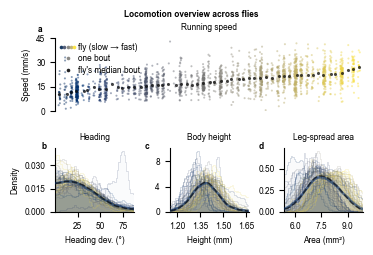

Saved: /home/user/3D_tracking_paper/fig_2_output/distributions_overview.pdf
Saved: /home/user/3D_tracking_paper/fig_2_output/distributions_overview.svg
Size: 90 x 60 mm | all text 6 pt | font Arial

PANEL a — Running speed (per-bout medians)
  2,213 bouts from 53 flies; one column per fly,
  ordered left→right by that fly's median bout speed (slow → fast).
  Colour = the same slow→fast rank ('cividis'), reused in B–D.
  One circle = one bout; black dot = the real bout nearest that fly's median.
  Panel a draws no tertile marks; the pooled tertiles
  (p33 = 12.66, p67 = 21.17 mm/s) are printed above and used by the
  speed-binned cells, not drawn here.
  Per-fly median bout speed: 10.13 – 26.80 mm/s (median across flies 17.84)

  Fly order in panel A (left → right), fly # = chronological:
     3(10.1)  5(10.5)  6(11.4)  38(12.2)  28(12.3)  44(12.7)  7(13.3)  46(13.4)
     27(13.6)  24(14.0)  41(14.1)  23(14.2)  42(14.6)  39(14.6)  22(15.0)  40(15.5)
     45(16.0)  53(16.0)  43(16.2)  1(

In [ ]:
# Cell 19 -- supplementary figure 2

# ── Overview distributions: speed, heading, height, leg spread ────────────────
# Lettered 4-panel figure, 90 x 60 mm, all text 6 pt Arial, PDF + SVG.
#   A per-bout running speed, one column per fly, slow -> fast
#   B heading deviation | C thorax height | D leg-spread area
# Units: forward_speed mm/s; thorax height real mm; leg spread real mm^2.
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.font_manager as _fm_sup
import re as _re
from matplotlib.legend_handler import HandlerTuple

# ── Layout and type ──────────────────────────────────────────────────────────
SUP_W_MM, SUP_H_MM = 90, 60      # A full width on top, B-D across the bottom
SUP_FS         = 6               # EVERY piece of text, in points
SUP_FS_LETTER  = 6               # panel letters
SUP_MARGIN_L   = 0.115           # left margin; panel A's ylabel and ticks
SUP_BOTTOM     = 0.13            # below the axes, for the x labels
# Three panels across 90 mm leaves ~20 mm each, so the axis furniture is thinned:
# only panel B carries the 'Density' label, and tick counts are capped.
SUP_MAX_XTICKS = 4
SUP_MAX_YTICKS = 3
# Short labels: the long forms are taller/wider than a 20 mm panel at 6 pt.
SUP_LBL_A      = 'Speed (mm/s)'      # per-bout median speed
SUP_LBL_B      = 'Heading dev. (°)'
SUP_LBL_C      = 'Height (mm)'       # thorax above the per-bout foot plane
SUP_LBL_D      = 'Area (mm²)'

# ── Density estimation ───────────────────────────────────────────────────────
SUP_TRIM         = 0.005   # shared robust range per quantity: [q0.5%, q99.5%]
SUP_NBINS        = 60
SUP_SMOOTH       = 1.2     # gaussian_filter1d sigma, in BINS
SUP_MIN_FRAMES   = 200     # a fly needs this many finite frames to contribute
SUP_MIN_IN_RANGE = 0.5     # ...and this fraction of them inside the x-range,
                           # otherwise its density is a misleading partial curve

# ── Marks ────────────────────────────────────────────────────────────────────
# Overlapping alpha composites as 1-(1-a)^n. At n=52 flies: a=0.10 -> 99.6%
# opacity (the dense core goes flat and stops being 52 animals), a=0.02 -> 65%.
# The faint per-fly outline is what keeps individual flies traceable once the
# fill is this light.
SUP_FILL_ALPHA   = 0.02    # per-fly fill
SUP_LINE_ALPHA   = 0.22    # per-fly step outline
SUP_PERFLY_LW    = 0.5
SUP_CMAP         = 'cividis'
SUP_MEAN_COLOR   = '#08306B'   # dark blue
SUP_REF_ALPHA    = 0.6         # mean / pooled / tertile lines
# Panel A dots are drawn as VECTOR points: rasterized=True rendered them at the
# figure dpi, which at 90 mm turned every bout into an ill-defined grey blob.
SUP_DOT_SIZE     = 2.2
SUP_DOT_ALPHA    = 0.45
# Panel A marks the actual BOUT whose speed is that fly's median (nearest-to-
# median when the count is even) rather than a synthetic median line, so the
# highlight is a real data point sitting inside its own column of dots.
SUP_MEDBOUT_COLOR = "#070707B9"
SUP_MEDBOUT_SIZE  = 5
# Half-width of the per-fly jitter column, in rank units (columns are 1 apart).
# Narrowing the column widens the GAP between flies: 0.28 -> 0.215 leaves
# 1 - 2*0.215 = 0.57 between neighbouring columns instead of 0.44, i.e. 30%
# more separation, without rescaling the axis.
SUP_JITTER       = 0.215

# ── Fly numbering ────────────────────────────────────────────────────────────
# Anonymous, stable labels: fly 1..N in CHRONOLOGICAL order of the recording
# timestamp embedded in the fly_id ('<session>/YYYY_MM_DD_HH_MM_SS').
# A plain sorted() on the raw id sorts by the SESSION PREFIX, which put the 45
# 2026 flies ahead of the 7 2025 flies -- fly 1 came out as a 2026 recording.
_fly_order = sorted(df_valid['fly_id'].unique())
_fly_arr   = df_valid['fly_id'].to_numpy()
_TS_PAT = _re.compile(r'(\d{4})_(\d{2})_(\d{2})_(\d{2})_(\d{2})_(\d{2})')
def _fly_ts(f):
    _m = _TS_PAT.search(str(f))
    return tuple(int(x) for x in _m.groups()) if _m else (9999,)
_fly_chrono = sorted(_fly_order, key=_fly_ts)
assert len(set(map(_fly_ts, _fly_order))) == len(_fly_order), \
    'fly timestamps are not unique -- numbering would be ambiguous'
FLY_NUM = {_f: _k + 1 for _k, _f in enumerate(_fly_chrono)}

# ── Speed bin boundaries (used in the phase-portrait cells) ───────────────────
_spd = df_valid['forward_speed']
_spd_q33 = _spd.quantile(0.33)
_spd_q67 = _spd.quantile(0.67)
print(f"Speed percentiles — p33: {_spd_q33:.2f} mm/s  |  p67: {_spd_q67:.2f} mm/s")

# ── Leg-spread: vectorised shoelace on egocentric XY of 6 leg tips ────────────
# Vertex order (CCW viewed from above): L1 → L2 → L3 → R3 → R2 → R1
_TIP_ORDER = ['T1_left', 'T2_left', 'T3_left', 'T3_right', 'T2_right', 'T1_right']
_x_tip_cols = [f'{l}_tip_x_ego' for l in _TIP_ORDER]
_y_tip_cols = [f'{l}_tip_y_ego' for l in _TIP_ORDER]
assert all(c in df_valid.columns for c in _x_tip_cols + _y_tip_cols), \
    'tip_x_ego / tip_y_ego columns missing -- re-run Cells 5 and 12'
_xs = block(df_valid, _x_tip_cols)      # (N, 6) model-metres
_ys = block(df_valid, _y_tip_cols)
_area_m2 = 0.5 * np.abs(np.sum(_xs * np.roll(_ys, -1, axis=1)
                               - np.roll(_xs, -1, axis=1) * _ys, axis=1))
df_valid['leg_spread_mm2'] = _area_m2 * 100      # 1 model-m^2 = 100 real mm^2
print(f"Leg spread (mm²): median={df_valid['leg_spread_mm2'].median():.2f}  "
      f"p5={df_valid['leg_spread_mm2'].quantile(0.05):.2f}  "
      f"p95={df_valid['leg_spread_mm2'].quantile(0.95):.2f}")

# ── Heading folded to corridor-axis deviation ─────────────────────────────────
#   0° = straight along the corridor (either direction);  90° = perpendicular.
#   h = heading mod 180 (collapses +/-180 -> 0);  dev = min(h, 180-h)  -> [0, 90]
_h_mod = np.mod(np.degrees(df_valid['heading'].to_numpy()), 180)
df_valid['heading_dev'] = np.minimum(_h_mod, 180 - _h_mod)

# ── Per-fly colours, ranked by median speed ──────────────────────────────────
# Aggregated here rather than inside panel A so the colour assignment and panel
# A's x-order come from the SAME ranking and cannot drift apart.
_bout_spd = (df_valid.groupby(['fly_id', 'bout_id'], observed=True)['forward_speed']
             .median().reset_index().rename(columns={'forward_speed': 'speed_mms'}))
_med_by_fly = _bout_spd.groupby('fly_id', observed=True)['speed_mms'].median().sort_values()
_rank = {f: k for k, f in enumerate(_med_by_fly.index)}
_pal = sns.color_palette(SUP_CMAP, len(_med_by_fly))
FLY_COLOR = {_f: _pal[_k] for _k, _f in enumerate(_med_by_fly.index)}
print(f"Per-fly colours: '{SUP_CMAP}' ordered by median speed (slow -> fast)")

# ── Across-fly density helper ────────────────────────────────────────────────
def _fly_density(vals, edges):
    """(centres, D, kept, n_skipped) -- per-fly densities on SHARED bins.

    Shared edges are what makes the curves averageable (per-fly `bins=60` would
    give each fly its own grid). Flies with too few frames, or with NO frames
    inside [edges[0], edges[-1]], are skipped rather than contributing a row:
    np.histogram(..., density=True) divides by n.sum(), so an out-of-range fly
    yields an all-NaN row that would poison mean()/std() for the whole panel.
    (This bites hardest on thorax height, where per-fly medians span ~1.0 mm but
    the pooled robust range is only ~0.24 mm wide -- entire flies sit outside it.)
    """
    ctr = 0.5 * (edges[:-1] + edges[1:])
    rows, kept, skipped = [], [], 0
    for _f in _fly_order:
        _v = vals[_fly_arr == _f]
        _v = _v[np.isfinite(_v)]
        if _v.size < SUP_MIN_FRAMES:
            skipped += 1
            continue
        _in = ((_v >= edges[0]) & (_v <= edges[-1])).sum()
        if _in < SUP_MIN_IN_RANGE * _v.size:
            skipped += 1
            continue
        _d, _ = np.histogram(_v, bins=edges, density=True)
        rows.append(gaussian_filter1d(_d, SUP_SMOOTH))
        kept.append(_f)
    return ctr, np.asarray(rows), kept, skipped


def _panel(ax, vals, xlabel, title, letter):
    """Density panel. All numeric summaries are RETURNED for printing."""
    _v = np.asarray(vals, float)
    _v = _v[np.isfinite(_v)]
    _lo, _hi = np.quantile(_v, [SUP_TRIM, 1 - SUP_TRIM])
    _edges = np.linspace(_lo, _hi, SUP_NBINS + 1)
    _ctr, _D, _kept, _skip = _fly_density(np.asarray(vals, float), _edges)

    if _D.size:
        _mu = np.nanmean(_D, axis=0)
        for _row, _f in zip(_D, _kept):
            _c = FLY_COLOR[_f]
            ax.fill_between(_ctr, 0, _row, step='mid', color=_c,
                            alpha=SUP_FILL_ALPHA, lw=0, zorder=2)
            ax.step(_ctr, _row, where='mid', color=_c,
                    lw=SUP_PERFLY_LW, alpha=SUP_LINE_ALPHA, zorder=3)
        ax.plot(_ctr, _mu, color=SUP_MEAN_COLOR, lw=1.8,
                alpha=SUP_REF_ALPHA, zorder=4)
    _pool, _ = np.histogram(_v, bins=_edges, density=True)
    _pool = gaussian_filter1d(_pool, SUP_SMOOTH)
    ax.plot(_ctr, _pool, color='k', lw=1.1, ls='--',
            alpha=SUP_REF_ALPHA, zorder=5)

    # only panel B carries the ylabel; the letter then has to clear whatever is
    # to the left of the axes -- the ylabel on B, the bare tick labels on C/D
    _show_ylab = letter == 'b'
    ax.set_xlabel(xlabel, fontsize=SUP_FS)
    ax.set_ylabel('Density' if _show_ylab else '', fontsize=SUP_FS)
    ax.set_title(title, fontsize=SUP_FS)
    ax.set_xlim(_lo, _hi)
    ax.set_ylim(bottom=0)                  # x axis sits ON y = 0
    ax.spines['bottom'].set_position(('data', 0))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(SUP_MAX_XTICKS))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(SUP_MAX_YTICKS))
    ax.tick_params(labelsize=SUP_FS)
    ax.text(-0.17 if _show_ylab else -0.32, 1.10, letter, transform=ax.transAxes,
            fontsize=SUP_FS_LETTER, fontweight='bold', va='top', ha='left')
    sns.despine(ax=ax)

    _q1, _q3 = np.quantile(_v, [0.25, 0.75])
    return dict(letter=letter, title=title, unit=xlabel, lo=_lo, hi=_hi,
                median=float(np.median(_v)), q1=float(_q1), q3=float(_q3),
                n_frames=int(_v.size), n_flies=len(_D),
                n_total=len(_fly_order), n_skip=_skip)


# ── Thorax height, referenced to each bout's own foot-contact plane ───────────
# PROVENANCE: df_valid['thorax_z'] is written by bouts_to_dataframe as
#   xpos[:, names_xpos.index('thorax'), 2]
# i.e. the z of the MuJoCo *thorax body origin* in the STAC IK output, in model
# units (x10 -> mm). The thorax is the root body, so this equals qpos[:, 2]. It
# is height above the MuJoCo world z=0 plane -- NOT above the floor.
#
# The file this notebook loads (ik_output_combined_*.h5, the NON-interpolated
# combine output) carries the RAW STAC values: combine_data.py builds it by
# renaming the '*_stac' keys to the clean names, so qpos/xpos/xquat there are
# PRE-floor-alignment. Verified from the claw z -- alignment targets
# target_z = -0.125 (configs/dataset/postprocessing.yaml, matching the floor
# plane in assets/fruitfly_v1/floor.xml):
#     ik_output_combined_v1_free_running.h5               claw z p5 = +0.078  NOT aligned
#     ik_output_combined_v1_free_running_interpolated.h5  claw z p5 = -0.127  aligned
# So panel C subtracts each bout's own foot-contact plane (5th pct of the 6 claw
# z), the only physically-referenced height available from this file. The feet
# are a STABLE reference despite stepping: the per-frame minimum claw z has
# sd 0.021 mm within a bout (some leg is always in stance), against a ~0.14 mm
# height signal. Variance decomposition over 2203 bouts: world ref between-fly
# sd 0.196 / within 0.076; foot-referenced 0.053 / 0.060.
_thz_mm = df_valid['thorax_z'].to_numpy() * 10.0
_claw_z_cols = [f'{lg}_tip_z_world' for lg in LEGS
                if f'{lg}_tip_z_world' in df_valid.columns]
assert _claw_z_cols, 'tip_z_world columns missing -- panel C needs the claw z'
_FLOOR_TARGET_Z = -0.125           # configs/dataset/postprocessing.yaml
_claw_p5 = float(np.nanpercentile(block(df_valid, _claw_z_cols), 5))
print(f"Floor-alignment check: claw z p5 = {_claw_p5:+.4f} model units "
      f"(target {_FLOOR_TARGET_Z}) -> "
      f"{'ALIGNED' if abs(_claw_p5 - _FLOOR_TARGET_Z) < 0.03 else 'NOT ALIGNED (raw STAC frame)'}")
_CZ = block(df_valid, _claw_z_cols) * 10.0
_floor = np.full(len(df_valid), np.nan)
for _s_, _e_ in bout_spans(df_valid):
    _floor[_s_:_e_] = np.nanpercentile(_CZ[_s_:_e_], 5)
_height_mm = _thz_mm - _floor
print(f"Thorax height: thorax minus per-bout foot-contact plane "
      f"(5th pct of {len(_claw_z_cols)} claw z)")

# ── Font / export settings ───────────────────────────────────────────────────
# Same treatment as Cells 21 and 22: svg.fonttype='none' keeps text as TEXT in
# the SVG (font referenced by name), so labels stay editable in Illustrator
# instead of being outlined; pdf.fonttype=42 embeds TrueType rather than Type-3.
# rcParams are restored right after the figure is written.
_rc_keys_sup = ('font.family', 'font.size', 'pdf.fonttype', 'ps.fonttype',
                'svg.fonttype')
_rc_sup_orig = {k: plt.rcParams[k] for k in _rc_keys_sup}
for _f_sup in ('Arial.ttf', 'Arial_Bold.ttf'):
    _p_sup = f'/usr/share/fonts/truetype/msttcorefonts/{_f_sup}'
    if Path(_p_sup).exists():
        _fm_sup.fontManager.addfont(_p_sup)
plt.rcParams.update({'font.family': 'Arial', 'font.size': SUP_FS,
                     'pdf.fonttype': 42, 'ps.fonttype': 42,
                     'svg.fonttype': 'none'})

# ── Figure ───────────────────────────────────────────────────────────────────
_SUMM = []
fig = plt.figure(figsize=(SUP_W_MM / 25.4, SUP_H_MM / 25.4))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.45,
                       height_ratios=[1.15, 1.0])

# ── A: per-bout running speed, one column per fly, ordered slow -> fast ───────
_axA = fig.add_subplot(gs[0, :])
_rank_col = _bout_spd['fly_id'].map(_rank)
_xj = (_rank_col.to_numpy()
       + np.random.default_rng(0).uniform(-SUP_JITTER, SUP_JITTER, len(_bout_spd)))
_axA.scatter(_xj, _bout_spd['speed_mms'].to_numpy(), s=SUP_DOT_SIZE,
             alpha=SUP_DOT_ALPHA, c=[FLY_COLOR[_f] for _f in _bout_spd['fly_id']],
             linewidths=0, zorder=2)
# Black dot = the real bout closest to that fly's median speed. Drawn at that
# bout's own jittered x (not the column centre) so it is identifiably one of
# the dots above it. No tertile reference lines: the panel shows the raw
# per-bout spread, and the x position (fly, slow -> fast) carries the order.
_med_idx = (_bout_spd.assign(_r=_rank_col)
            .loc[lambda d: d['_r'].notna()]
            .assign(_d=lambda d: (d['speed_mms']
                                  - d['fly_id'].map(_med_by_fly)).abs())
            .sort_values(['fly_id', '_d'])
            .groupby('fly_id', observed=True, sort=False).head(1).index)
_sel = _bout_spd.index.isin(_med_idx)
_axA.scatter(_xj[_sel], _bout_spd.loc[_sel, 'speed_mms'].to_numpy(),
             s=SUP_MEDBOUT_SIZE, color=SUP_MEDBOUT_COLOR, linewidths=0, zorder=5)
_axA.set_xticks([])
_axA.set_xlim(-0.8, len(_med_by_fly) - 0.2)
_axA.set_ylim(bottom=0)
_axA.set_ylabel(SUP_LBL_A, fontsize=SUP_FS)
_axA.set_title('Running speed', fontsize=SUP_FS)
_axA.yaxis.set_major_locator(mticker.MaxNLocator(SUP_MAX_YTICKS + 1))
_axA.tick_params(axis='y', labelsize=SUP_FS)
# above the axes rather than beside it: with ylim starting at 0 the top y tick
# label now reaches the corner where the letter used to sit
_axA.text(-0.055, 1.19, 'a', transform=_axA.transAxes,
          fontsize=SUP_FS_LETTER, fontweight='bold', va='top', ha='left')
sns.despine(ax=_axA, bottom=True)          # x is fly order, not a quantity

# ── A's own legend: what the colour means, and what one mark is ──────────────
# The colour ramp is shown as five circles sampled across the palette, so the
# legend states the encoding (colour = fly, ordered by speed) with the same mark
# the data uses.
# markeredgewidth=0 matters: the default edge is drawn in the line colour, which
# ringed every swatch in black and turned the ramp into one dark blob -- the data
# dots have linewidths=0, so the legend has to match them
def _dot_A(colour):
    return plt.Line2D([], [], marker='o', linestyle='none', markersize=2.6,
                      markerfacecolor=colour, markeredgewidth=0, alpha=0.9)
_h_A = [tuple(_dot_A(_pal[_k])
              for _k in np.linspace(0, len(_pal) - 1, 5).astype(int)),
        _dot_A(_pal[len(_pal) // 2]),
        _dot_A(SUP_MEDBOUT_COLOR)]
# inset from the corner so the ramp row does not line up with the top y tick
_axA.legend(_h_A, ['fly (slow → fast)', 'one bout', "fly's median bout"],
            loc='upper left',
            bbox_to_anchor=(0.02, 0.94), fontsize=SUP_FS, frameon=False,
            handlelength=1.5, handletextpad=0.5, labelspacing=0.3,
            borderpad=0.0, borderaxespad=0.0,
            handler_map={tuple: HandlerTuple(ndivide=None, pad=0.45)})

# ── B, C, D ──────────────────────────────────────────────────────────────────
_SUMM.append(_panel(fig.add_subplot(gs[1, 0]), df_valid['heading_dev'].to_numpy(),
                    SUP_LBL_B, 'Heading', 'b'))
_SUMM.append(_panel(fig.add_subplot(gs[1, 1]), _height_mm,
                    SUP_LBL_C, 'Body height', 'c'))
_SUMM.append(_panel(fig.add_subplot(gs[1, 2]),
                    df_valid['leg_spread_mm2'].to_numpy(),
                    SUP_LBL_D, 'Leg-spread area', 'd'))

fig.suptitle('Locomotion overview across flies', fontsize=SUP_FS,
             fontweight='bold', y=0.985)
# Explicit margins, not tight_layout: the GridSpec carries its own hspace/wspace,
# so tight_layout(rect=...) is silently ignored for these axes.
fig.subplots_adjust(left=SUP_MARGIN_L, right=0.985, top=0.865,
                    bottom=SUP_BOTTOM)

_fn_ov = OUTPUT_DIR / 'distributions_overview.pdf'
fig.savefig(_fn_ov, bbox_inches='tight')
_fn_ov_svg = _fn_ov.with_suffix('.svg')
fig.savefig(_fn_ov_svg, bbox_inches='tight')
plt.show()
plt.rcParams.update(_rc_sup_orig)          # restore
for _f_out in (_fn_ov, _fn_ov_svg):
    print(f"Saved: {_f_out}")
print(f"Size: {SUP_W_MM} x {SUP_H_MM} mm | all text {SUP_FS} pt | font Arial")

# ── All numeric detail as TEXT, not inside the figure ─────────────────────────
print("\n" + "=" * 78)
print("PANEL a — Running speed (per-bout medians)")
print("=" * 78)
print(f"  {len(_bout_spd):,} bouts from {len(_med_by_fly)} flies; one column per fly,")
print(f"  ordered left→right by that fly's median bout speed (slow → fast).")
print(f"  Colour = the same slow→fast rank ('{SUP_CMAP}'), reused in B–D.")
print(f"  One circle = one bout; black dot = the real bout nearest that fly's median.")
print(f"  Panel a draws no tertile marks; the pooled tertiles")
print(f"  (p33 = {_spd_q33:.2f}, p67 = {_spd_q67:.2f} mm/s) are printed above and used by the")
print(f"  speed-binned cells, not drawn here.")
print(f"  Per-fly median bout speed: {_med_by_fly.min():.2f} – {_med_by_fly.max():.2f} mm/s "
      f"(median across flies {_med_by_fly.median():.2f})")
print("\n  Fly order in panel A (left → right), fly # = chronological:")
_ordered = [f"{FLY_NUM[_f]}({_med_by_fly[_f]:.1f})" for _f in _med_by_fly.index]
for _k in range(0, len(_ordered), 8):
    print("     " + "  ".join(_ordered[_k:_k + 8]))

print("\n" + "=" * 78)
print("PANELS b–d — distribution summaries (pooled over all frames)")
print("=" * 78)
_hdr = (f"  {'':2} {'quantity':<18}{'median':>10}{'IQR':>20}"
        f"{'x-range shown':>20}{'frames':>11}{'flies':>8}")
print(_hdr)
for _s in _SUMM:
    _iqr = f"[{_s['q1']:.2f}, {_s['q3']:.2f}]"
    _rng = f"[{_s['lo']:.2f}, {_s['hi']:.2f}]"
    _fly = f"{_s['n_flies']}/{_s['n_total']}"
    print(f"  {_s['letter']:<2} {_s['title']:<18}{_s['median']:>10.2f}"
          f"{_iqr:>20}{_rng:>20}{_s['n_frames']:>11,}{_fly:>8}")
print("  units — b: degrees from corridor axis | c: mm | d: mm²")
for _s in _SUMM:
    if _s['n_skip']:
        print(f"\n  [{_s['letter']}] {_s['n_skip']} fly/flies excluded from the across-fly mean:")
        print(f"      needs ≥{SUP_MIN_FRAMES} frames and ≥{SUP_MIN_IN_RANGE:.0%} of them inside "
              f"[{_s['lo']:.2f}, {_s['hi']:.2f}] {_s['unit']}")


### Speed binning — frame-weighted tertiles, shared with the PCA phase portrait

The speed groups used by the polar cells below (Cell 20, Cell 21) and by the
PC1–PC2 phase portrait (Cell 23) are tertiles of `step_cycle_mean_speed`
**computed over frames**, not over step cycles:

```python
_sc_spd_all = df['step_cycle_mean_speed'].dropna()      # one value per FRAME
_q33, _q67  = _sc_spd_all.quantile([0.33, 0.67])        # 13.73 / 21.63 mm/s
```

Verified identical in both places: `df` and `df_valid` give
`q33 = 13.7284`, `q67 = 21.6289` from the same 445,725 frames, so Cell 21 and
Cell 23 describe **the same cycles**. That is the reason this binning is kept.

**Consequence to be aware of.** A slow cycle lasts longer than a fast one
(median 108 vs 64 frames — 135 vs 80 ms at 800 Hz), so frame-weighting
over-represents slow cycles and pulls the thresholds down. The groups end up
holding equal *time*, not equal *cycle counts*:

| binning | q33 / q67 (mm/s) | cycles per group | share of cycles | frames per group |
|---|---|---|---|---|
| **frame-weighted (in use)** | 13.73 / 21.63 | 1211 / 1853 / 2277 | 23 % / 35 % / 43 % | 146 998 / … / 147 130 |
| cycle-weighted | 16.23 / 23.85 | 1763 / 1815 / 1763 | 33 % / 34 % / 33 % | unequal |

So the unequal `n` printed under each polar panel (e.g. `n = 1137/2258 phase
comparisons`, after `POLAR_MIN_CYCLES` drops flies with fewer than 5 cycles in a
group) is expected, not a bug. The two-sample Kuiper test is defined for unequal
groups — its effective sample size is `Ne = n1·n2/(n1+n2)` = 756 for that panel,
i.e. the smaller group sets the resolution.


Step-cycle speed quartile boundaries (mm/s):  Q1 < 14.2  |  Q2 < 21.9  | Q3 >= 21.9

Q1 (slowest)  [0.0–14.2 mm/s]: 1189 step-cycle onsets


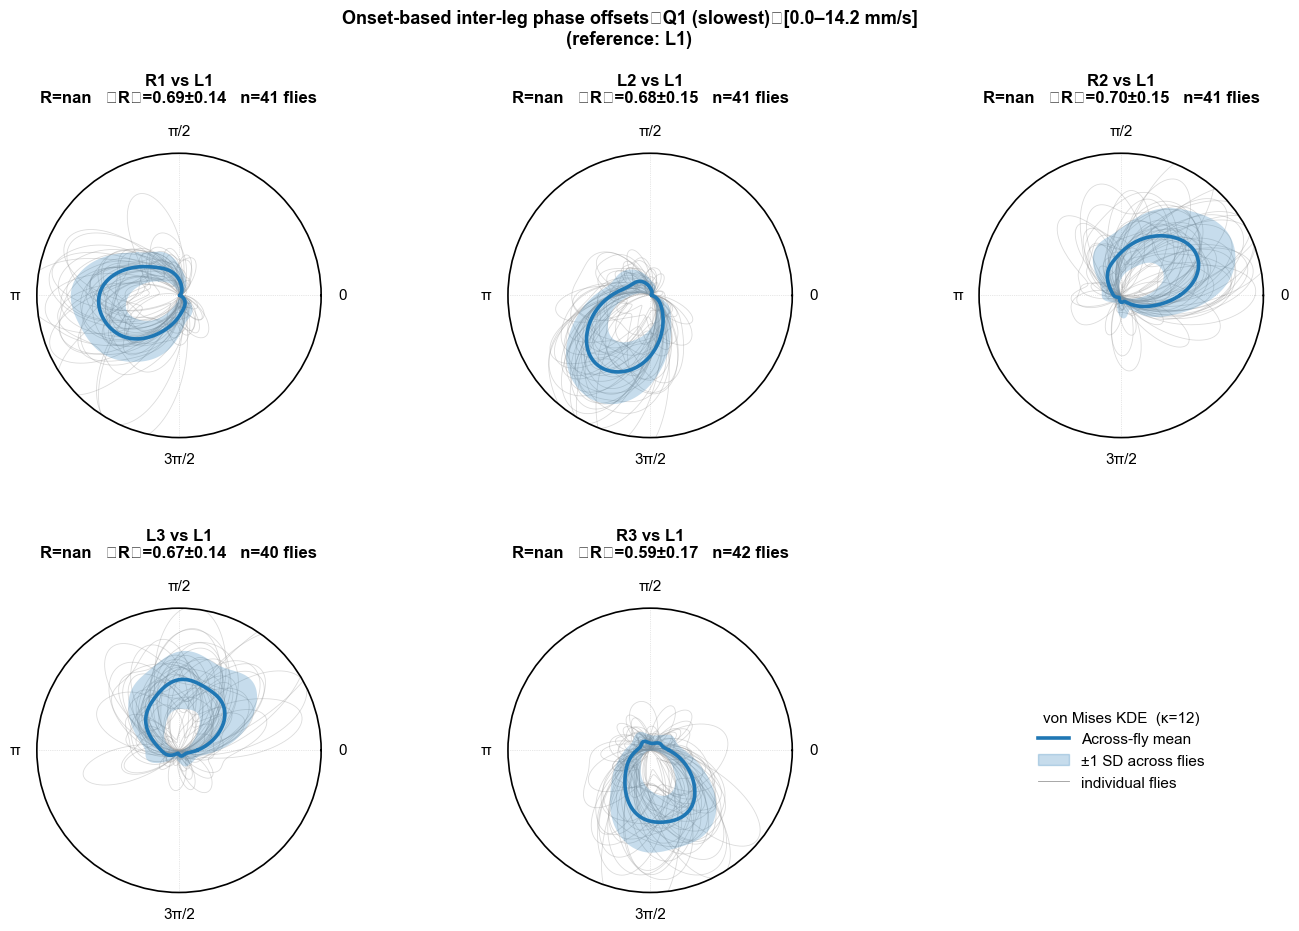

  Saved: /home/user/3D_tracking_paper/fig_2_output/phase_coordination_onsets_polar_q1.pdf


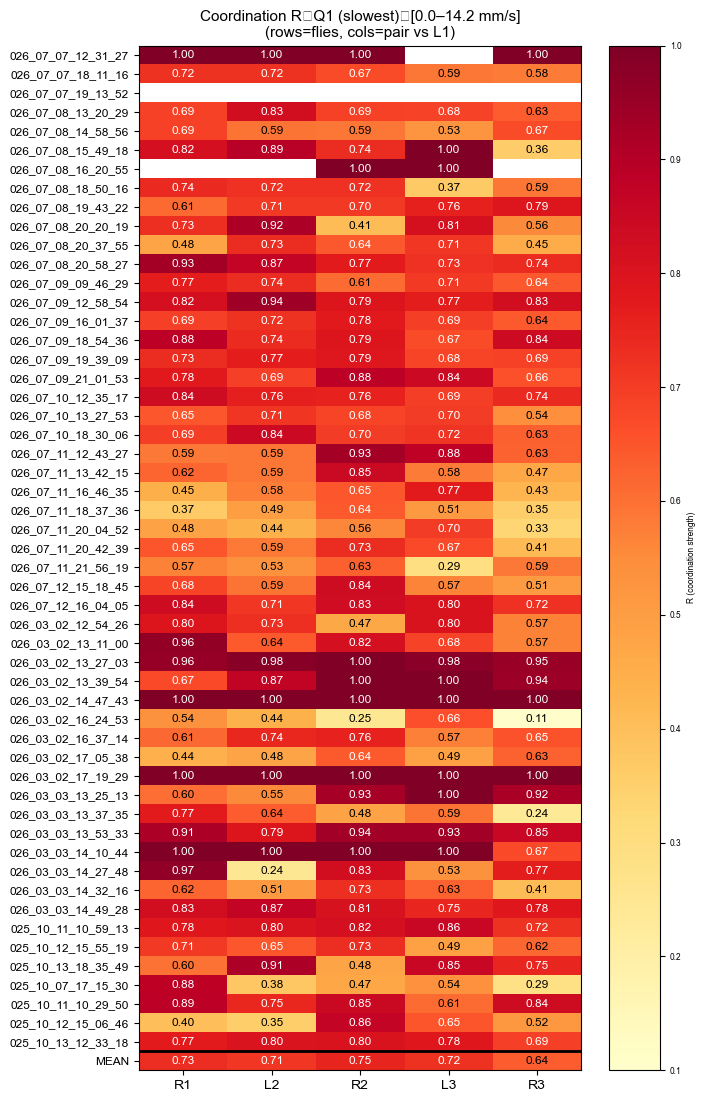

  Saved: /home/user/3D_tracking_paper/fig_2_output/phase_coordination_R_matrix_q1.pdf
Q2  [14.2–21.9 mm/s]: 1805 step-cycle onsets


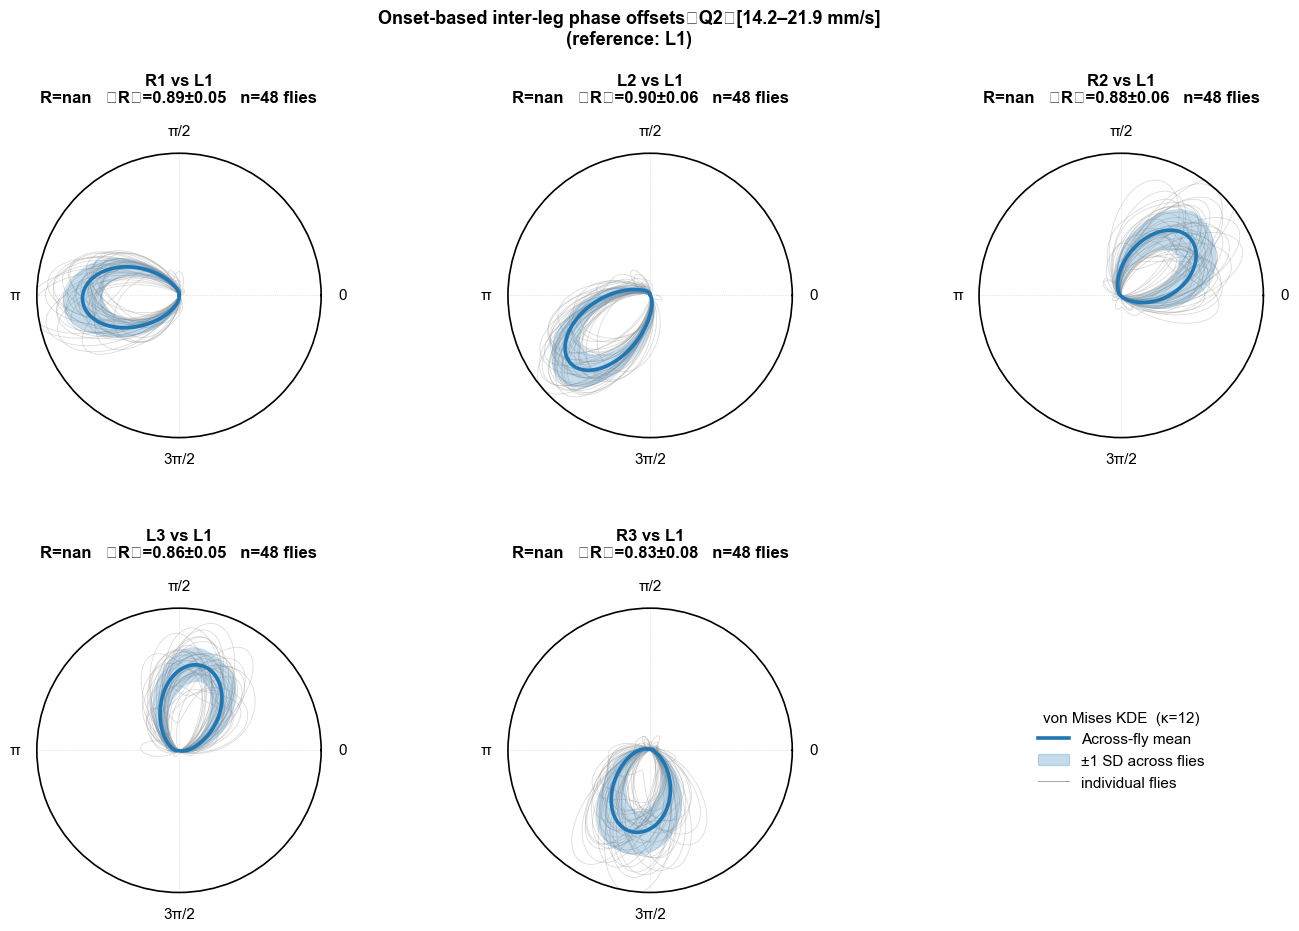

  Saved: /home/user/3D_tracking_paper/fig_2_output/phase_coordination_onsets_polar_q2.pdf


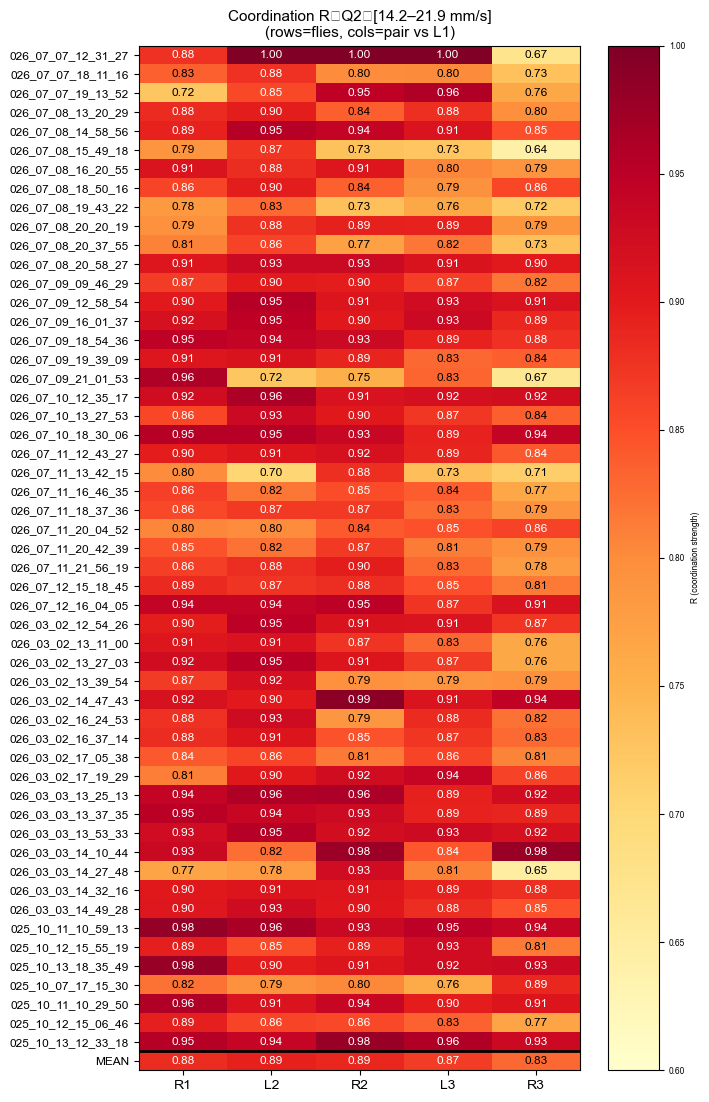

  Saved: /home/user/3D_tracking_paper/fig_2_output/phase_coordination_R_matrix_q2.pdf
Q3  [21.9–∞ mm/s]: 2211 step-cycle onsets


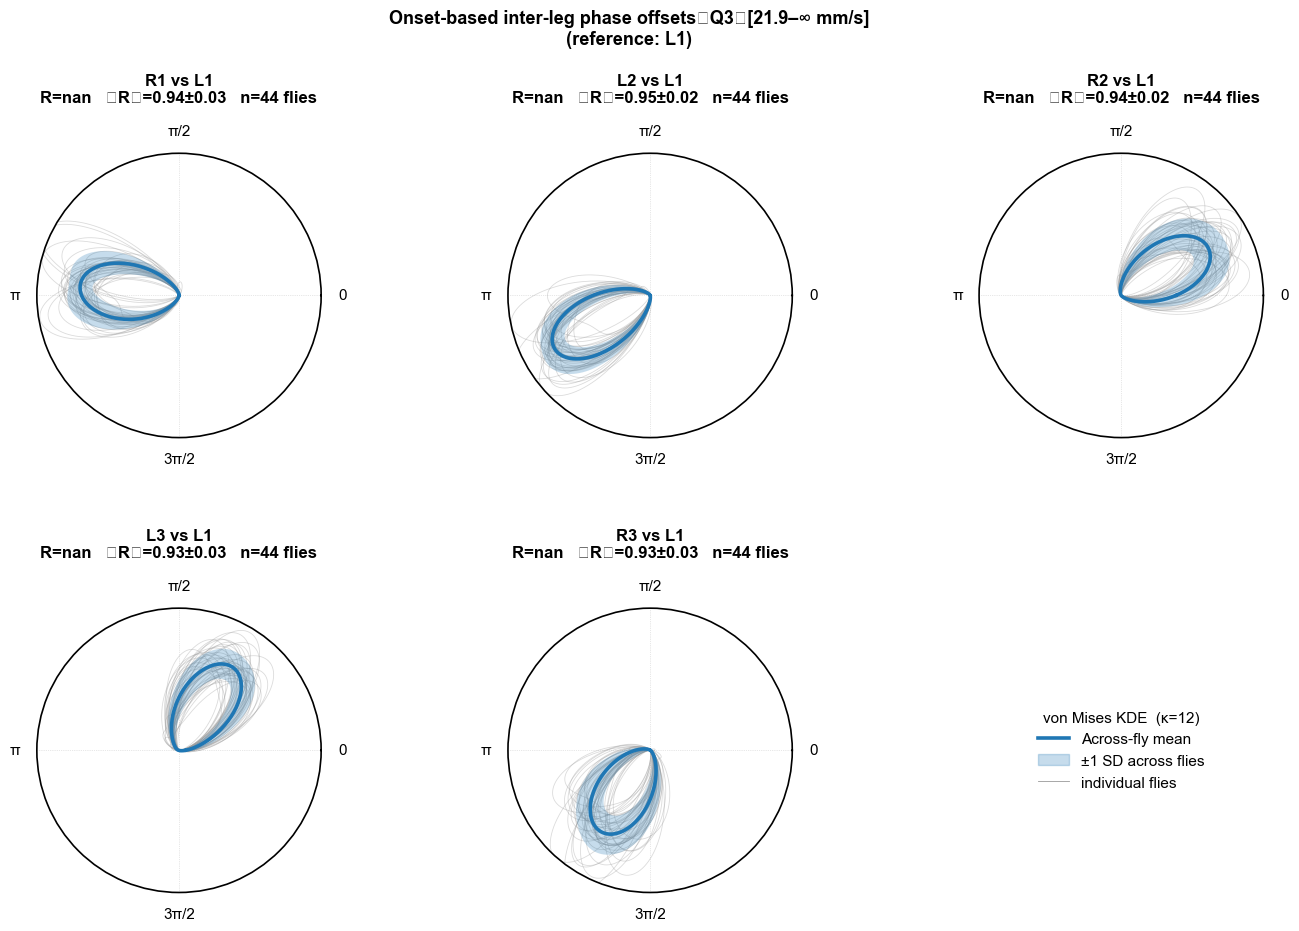

  Saved: /home/user/3D_tracking_paper/fig_2_output/phase_coordination_onsets_polar_q3.pdf


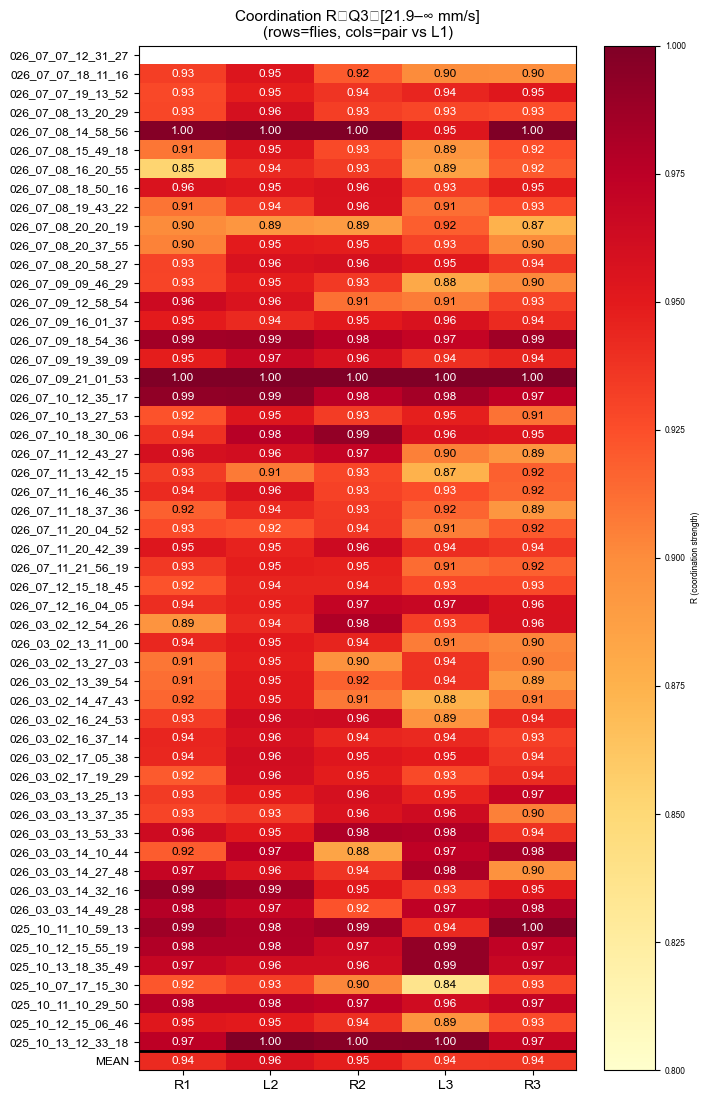

  Saved: /home/user/3D_tracking_paper/fig_2_output/phase_coordination_R_matrix_q3.pdf

Done. Full-data state restored for downstream cells.
Saved coordination plots to /home/user/3D_tracking_paper/fig_2_output


In [ ]:
# Cell 20 -- BUILDS FOR supplementary figure 2 (the next cell is the actual figure)
# --- 3b: Onset-based polar plots + per-fly R matrix -------------------------
# Coordination analysis split by STEP-CYCLE mean speed quartile.
# Each step cycle (between consecutive T1_left swing onsets) contributes
# its phase offsets to whichever speed quartile its step_cycle_mean_speed
# falls in. One bout can span multiple quartiles.
# ── Display config ────────────────────────────────────────────────────────────
# Curves are von Mises KDEs, not histograms: bin-free, so no edge artefacts and
# exact wrap-around at 0/2pi. (A 24-bin histogram of phases centred on the seam
# puts every count in bin 0 and none in bin 23 -- that discontinuity was most of
# the apparent jaggedness.) Verified: integrates to 1.000 at every kappa tested.
POLAR_KAPPA       = 12     # von Mises concentration; HIGHER = LESS smoothing
                           # (~1/sigma^2 for small angles: 12 ~ 17 deg sd)
POLAR_MIN_CYCLES  = 5      # a fly needs this many cycles to contribute a curve
POLAR_BAND        = 'sd'   # 'sd' = +/-1 SD across flies (fly-to-fly variability)
                           # 'sem' = SD/sqrt(n) (uncertainty of the mean)
POLAR_SHOW_FLIES  = True  # True = faint grey per-fly curves behind the mean
POLAR_SHOW_POOLED = False   # dashed curve = all cycles pooled (ignores fly weighting)
_TH = np.linspace(0, 2 * np.pi, 361, endpoint=False)

def vm_kde(phases, th=_TH, kappa=POLAR_KAPPA):
    """von Mises kernel density on the circle. Stable form: exp(k(cos-1))/i0e(k)."""
    p = np.asarray(phases, float)
    p = p[np.isfinite(p)]
    if p.size == 0:
        return np.full_like(th, np.nan)
    return (np.exp(kappa * (np.cos(th[:, None] - p[None, :]) - 1.0)).mean(1)
            / (2 * np.pi * i0e(kappa)))

def _close(a):
    """Close a periodic curve for plotting."""
    return np.r_[a, a[:1]]

_non_ref    = [l for l in LEGS if l != REFERENCE_LEG]
_fly_ids_u  = sorted(df['fly_id'].unique())
_ref_phase_col = f"{REFERENCE_LEG}_phase"
_sc_spd_col = 'step_cycle_mean_speed'

# Global quartile thresholds from all step cycles
_sc_spd_all = df[_sc_spd_col].dropna()
_q33, _q67, _q75 = _sc_spd_all.quantile([0.33, 0.67, 0.75]).values
_SPEED_QUARTILES = [
    ('Q1 (slowest)', 0,     _q33,  'q1'),
    ('Q2',           _q33,  _q67,  'q2'),
    ('Q3',           _q67,  np.inf,  'q3'), #,  _q75,
    # ('Q4 (fastest)', _q75,  np.inf,'q4'),
]
print(f"Step-cycle speed quartile boundaries (mm/s):  "
    #   f"Q1 < {_q25:.1f}  |  Q2 < {_q50:.1f}  |  Q3 < {_q75:.1f}  |  Q4 >= {_q75:.1f}")
      f"Q1 < {_q33:.1f}  |  Q2 < {_q67:.1f}  | Q3 >= {_q67:.1f}")
print()

# Pre-allocate accumulators: _fly_phases_q[q_tag][fly_id][leg] = list of phases
_fly_phases_q = {
    q_tag: {fid: {leg: [] for leg in _non_ref} for fid in _fly_ids_u}
    for _, _, _, q_tag in _SPEED_QUARTILES
}

if _ref_phase_col not in df.columns:
    print(f"WARNING: {_ref_phase_col} not found — re-run Cell 12.")
else:
    for _bid, _grp in df.groupby('bout_id', sort=False):
        _fid  = _grp['fly_id'].iloc[0]
        _spd  = _grp[_sc_spd_col].values         # step_cycle_mean_speed per frame

        _ref_onsets = liftoff_from_hilbert(_grp[f'{REFERENCE_LEG}_phase'].values)
        if len(_ref_onsets) < 2:
            continue

        # Speed of each T1_left cycle (constant within cycle; sample at cycle start)
        _cycle_speeds = _spd[_ref_onsets[:-1]]

        for _leg in _non_ref:
            if f"{_leg}_phase" not in _grp.columns:
                continue
            _leg_onsets = liftoff_from_hilbert(_grp[f'{_leg}_phase'].values)

            for _, _q_lo, _q_hi, _q_tag in _SPEED_QUARTILES:
                _ph = compute_phase_offset_by_cycle(
                    _ref_onsets, _leg_onsets, _cycle_speeds, _q_lo, _q_hi)
                if len(_ph) > 0:
                    _fly_phases_q[_q_tag][_fid][_leg].extend(_ph.tolist())

# Convert accumulated lists to arrays
for _, _, _, _q_tag in _SPEED_QUARTILES:
    for _fid in _fly_phases_q[_q_tag]:
        for _leg in _fly_phases_q[_q_tag][_fid]:
            _fly_phases_q[_q_tag][_fid][_leg] = np.array(
                _fly_phases_q[_q_tag][_fid][_leg])

# ── Loop for plotting — one iteration per quartile ────────────────────────────────────────────────────────────────────────────
for _q_label, _q_lo, _q_hi, _q_tag in _SPEED_QUARTILES:
    _fly_phases = _fly_phases_q[_q_tag]
    _q_hi_str   = f'{_q_hi:.1f}' if np.isfinite(_q_hi) else '∞'
    _spd_range  = f'[{_q_lo:.1f}–{_q_hi_str} mm/s]'
    _n_cycles = sum(
        len(_fly_phases[_fid][_non_ref[0]])
        for _fid in _fly_ids_u
        if len(_fly_phases[_fid][_non_ref[0]]) > 0
    )
    print(f"{'='*62}")
    print(f"{_q_label}  {_spd_range}: {_n_cycles} step-cycle onsets")
    if _n_cycles == 0:
        print("  No data — skipping.")
        continue
    # ── Polar densities: across-fly mean +/- SD ──────────────────────────
    # Was: one coloured histogram per fly (52 flies through a 10-colour map, so
    # colours repeated 5x). Now: each fly contributes a smooth density, and we
    # show the across-fly mean with a dispersion ribbon.
    _dens = {}
    _rmax_ob = 0.0
    for _leg in _non_ref:
        _per_fly, _R_vals = [], []
        for _fid in _fly_ids_u:
            _ph = _fly_phases[_fid][_leg]
            if len(_ph) < POLAR_MIN_CYCLES:
                continue
            _per_fly.append(vm_kde(_ph))
            _R_vals.append(mean_resultant_length(_ph))
        if not _per_fly:
            continue
        _D  = np.asarray(_per_fly)                     # (n_flies, n_theta)
        _mu = np.nanmean(_D, axis=0)
        _sd = (np.nanstd(_D, axis=0, ddof=1) if len(_D) > 1 else np.zeros_like(_mu))
        if POLAR_BAND == 'sem':
            _sd = _sd / np.sqrt(len(_D))
        _pooled = np.array([])
        if POLAR_SHOW_POOLED:
            _cat = [_fly_phases[f][_leg] for f in _fly_ids_u
                    if len(_fly_phases[f][_leg]) > 0]
            if _cat:
                _pooled = vm_kde(np.concatenate(_cat))
        _dens[_leg] = dict(D=_D, mu=_mu, sd=_sd, pooled=_pooled,
                           R_vals=np.asarray(_R_vals),
                           R_all=(mean_resultant_length(np.concatenate(_cat))
                                  if POLAR_SHOW_POOLED and _cat else np.nan))
        _rmax_ob = max(_rmax_ob, np.nanmax(_mu + _sd),
                       np.nanmax(_pooled) if _pooled.size else 0.0)
    _rmax_ob *= 1.15

    # Pass 2: draw
    _n_pairs = len(_non_ref)
    _n_cols  = 3
    _n_rows  = math.ceil((_n_pairs + 1) / _n_cols)

    _fig = plt.figure(figsize=(5.5 * _n_cols, 4.8 * _n_rows))
    _gs  = gridspec.GridSpec(_n_rows, _n_cols, figure=_fig,
                             hspace=0.6, wspace=0.4)
    _axes_polar = [
        _fig.add_subplot(_gs[_i // _n_cols, _i % _n_cols], projection='polar')
        for _i in range(_n_pairs)
    ]
    _ax_leg = _fig.add_subplot(_gs[_n_pairs // _n_cols, _n_pairs % _n_cols])
    _ax_leg.set_axis_off()

    _tick_pos    = np.linspace(0, 2 * np.pi, 5)[:-1]   # 0, pi/2, pi, 3pi/2
    _tick_labels = ['0', 'π/2', 'π', '3π/2']
    _thc = _close(_TH)

    for _ax, _leg in zip(_axes_polar, _non_ref):
        _d = _dens.get(_leg)
        if _d is None:
            _ax.set_axis_off()
            continue

        if POLAR_SHOW_FLIES:
            for _row in _d['D']:
                _ax.plot(_thc, _close(_row), color='0.6', lw=0.6, alpha=0.35, zorder=2)

        _lo = np.clip(_d['mu'] - _d['sd'], 0, None)
        _hi = _d['mu'] + _d['sd']
        _ax.fill_between(_thc, _close(_lo), _close(_hi),
                         color='C0', alpha=0.25, lw=0, zorder=3)
        _ax.plot(_thc, _close(_d['mu']), color='C0', lw=2.6, zorder=5,
                 solid_capstyle='round')
        if _d['pooled'].size:
            _ax.plot(_thc, _close(_d['pooled']), color='k', lw=1.4, ls='--', zorder=6)

        _ax.set_ylim(0, max(_rmax_ob, 0.01))
        _ax.yaxis.set_visible(False)
        _ax.set_xticks(_tick_pos)
        _ax.set_xticklabels(_tick_labels, fontsize=11)
        _ax.tick_params(axis='x', pad=5)
        _ax.grid(True, linewidth=0.5, linestyle=':', alpha=0.6)
        _ax.spines['polar'].set_linewidth(1.2)

        _lbl = LEG_LABELS.get(_leg, _leg)
        _ref = LEG_LABELS.get(REFERENCE_LEG, REFERENCE_LEG)
        _Rv  = _d['R_vals']
        _ax.set_title(
            f'{_lbl} vs {_ref}\n'
            f'R={_d["R_all"]:.2f}   \u27e8R\u27e9={np.nanmean(_Rv):.2f}'
            f'\u00b1{(np.nanstd(_Rv, ddof=1) if _Rv.size > 1 else 0):.2f}'
            f'   n={_Rv.size} flies',
            fontsize=12, pad=16, fontweight='bold'
        )

    _band_lbl = ('\u00b11 SD across flies' if POLAR_BAND == 'sd'
                 else 'SEM across flies')
    _handles = [
        plt.Line2D([0], [0], color='C0', lw=2.6, label='Across-fly mean'),
        plt.Rectangle((0, 0), 1, 1, color='C0', alpha=0.25, label=_band_lbl),
    ]
    if POLAR_SHOW_POOLED:
        _handles.append(plt.Line2D([0], [0], color='k', lw=1.4, ls='--',
                                   label='All cycles pooled'))
    if POLAR_SHOW_FLIES:
        _handles.append(plt.Line2D([0], [0], color='0.6', lw=0.6,
                                   label='individual flies'))
    _ax_leg.legend(handles=_handles, loc='center', fontsize=11, frameon=False,
                   title=f'von Mises KDE  (\u03ba={POLAR_KAPPA})',
                   title_fontsize=11)

    # y=1.03 keeps the 2-line suptitle clear of the panel titles (which are now
    # 2 lines themselves); bbox_inches='tight' preserves the added headroom.
    _fig.suptitle(
        f'Onset-based inter-leg phase offsets\u2003{_q_label}\u2003{_spd_range}\n'
        f'(reference: {LEG_LABELS.get(REFERENCE_LEG, REFERENCE_LEG)})',
        fontsize=13, fontweight='bold', y=1.03
    )
    _fname = OUTPUT_DIR / f'phase_coordination_onsets_polar_{_q_tag}.pdf'
    plt.savefig(_fname, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {_fname}")

    # ── R matrix ─────────────────────────────────────────────────────────
    _R_matrix = np.full((len(_fly_ids_u), len(_non_ref)), np.nan)
    for _i, _fid in enumerate(_fly_ids_u):
        for _j, _leg in enumerate(_non_ref):
            _R_matrix[_i, _j] = mean_resultant_length(_fly_phases[_fid][_leg])

    _R_plot  = np.vstack([_R_matrix, np.nanmean(_R_matrix, axis=0)])
    # Row labels: str(f)[:15] made ~27 of the 52 flies read as an identical
    # '202607/2026_07_'. Strip the longest COMMON prefix so the distinguishing
    # part survives, and keep the tail rather than the head.
    _ids = [str(f) for f in _fly_ids_u]
    _pre = os.path.commonprefix(_ids) if len(_ids) > 1 else ''
    _pre = _pre[:_pre.rfind('_') + 1] if '_' in _pre else _pre   # cut on a separator
    _row_lbl = [(s[len(_pre):] or s)[-18:] for s in _ids] + ['MEAN']
    _col_lbl = [LEG_LABELS.get(l, l) for l in _non_ref]

    # Height CAPPED: at 52 flies the old expression (0.7 in/fly) asked for a
    # ~38-inch-tall figure. Cell annotations are dropped once rows get thin.
    _RM_MAX_H  = 11.0
    _rm_h      = min(_RM_MAX_H, max(3.0, len(_row_lbl) * 0.7 + 1.5))
    _row_in    = _rm_h / max(len(_row_lbl), 1)
    _rm_fs     = float(np.clip(_row_in * 42, 4.0, 9.0))
    _annotate  = _row_in > 0.16          # enough room for a legible number

    _fig2, _ax2 = plt.subplots(figsize=(max(5, len(_non_ref) * 1.4), _rm_h))
    # R here spans a narrow band near 1, so a 0-1 colour scale renders almost
    # uniformly dark. RM_VMIN=None stretches the map over the observed range
    # instead; set it to 0.0 to restore the absolute 0-1 scale.
    RM_VMIN = None
    _vmin = (RM_VMIN if RM_VMIN is not None
             else float(np.floor(np.nanmin(_R_plot) * 20) / 20))   # round down to 0.05
    _im = _ax2.imshow(_R_plot, cmap='YlOrRd', vmin=_vmin, vmax=1, aspect='auto')
    _ax2.set_xticks(range(len(_col_lbl)));  _ax2.set_xticklabels(_col_lbl, fontsize=10)
    _ax2.set_yticks(range(len(_row_lbl)))
    _ax2.set_yticklabels(_row_lbl, fontsize=_rm_fs)
    _ax2.axhline(len(_fly_ids_u) - 0.5, color='k', lw=2)
    if _annotate:
        for _i in range(_R_plot.shape[0]):
            for _j in range(_R_plot.shape[1]):
                if not np.isnan(_R_plot[_i, _j]):
                    _mid = _vmin + 0.6 * (1.0 - _vmin)
                    _ax2.text(_j, _i, f'{_R_plot[_i, _j]:.2f}', ha='center', va='center',
                              fontsize=_rm_fs,
                              color='k' if _R_plot[_i, _j] < _mid else 'w')
    else:
        print(f"  ({len(_row_lbl)} rows -- per-cell numbers omitted; see the colourbar)")
    plt.colorbar(_im, ax=_ax2, label='R (coordination strength)')
    _ax2.set_title(
        f'Coordination R\u2003{_q_label}\u2003{_spd_range}\n'
        f'(rows=flies, cols=pair vs {LEG_LABELS.get(REFERENCE_LEG, REFERENCE_LEG)})',
        fontsize=11
    )
    plt.tight_layout()
    _fname2 = OUTPUT_DIR / f'phase_coordination_R_matrix_{_q_tag}.pdf'
    plt.savefig(_fname2, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {_fname2}")

# ── Restore full-df state for downstream cells (Section 5) ───────────────────
_fly_ids_u  = sorted(df['fly_id'].unique())
_fly_phases_full = {fid: {leg: [] for leg in _non_ref} for fid in _fly_ids_u}
_ref_ss_col = f"{REFERENCE_LEG}_swing_stance"
if _ref_ss_col in df.columns:
    for _bid, _grp in df.groupby('bout_id', sort=False):
        _fid        = _grp['fly_id'].iloc[0]
        _ref_onsets = liftoff_from_hilbert(_grp[f'{REFERENCE_LEG}_phase'].values)
        if len(_ref_onsets) < 2:
            continue
        for _leg in _non_ref:
            if f"{_leg}_phase" not in _grp.columns:
                continue
            _leg_onsets = liftoff_from_hilbert(_grp[f'{_leg}_phase'].values)
            _ph = compute_phase_offset(_leg_onsets, _ref_onsets, FPS)
            if len(_ph) > 0:
                _fly_phases_full[_fid][_leg].extend(_ph.tolist())
# Export as expected by downstream cells
fly_phases   = {fid: {leg: np.array(v) for leg, v in d.items()}
                for fid, d in _fly_phases_full.items()}
non_ref_legs = _non_ref
R_matrix     = np.full((len(_fly_ids_u), len(_non_ref)), np.nan)
for _i, _fid in enumerate(_fly_ids_u):
    for _j, _leg in enumerate(_non_ref):
        R_matrix[_i, _j] = mean_resultant_length(fly_phases[_fid][_leg])
fly_ids_u_ob = _fly_ids_u
print(f"\nDone. Full-data state restored for downstream cells.")
print(f"Saved coordination plots to {OUTPUT_DIR}")


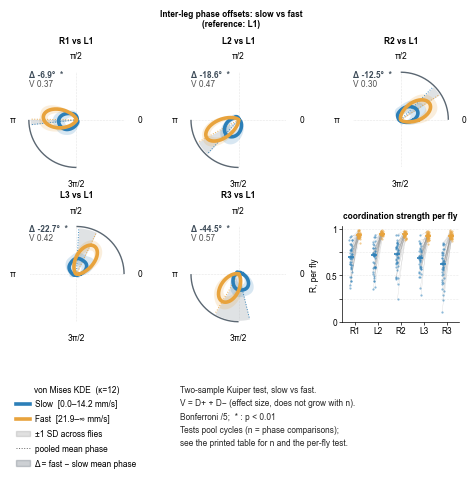

Saved: /home/user/3D_tracking_paper/fig_2_output/phase_coordination_polar_slow_vs_fast.pdf
Saved: /home/user/3D_tracking_paper/fig_2_output/phase_coordination_polar_slow_vs_fast.svg
Size: [144.8 133.2] mm | all text 6 pt | font Arial

leg     median R slow    fast      dR   flies
R1              0.695   0.933  +0.238   34 paired
L2              0.720   0.951  +0.231   34 paired
R2              0.729   0.946  +0.217   34 paired
L3              0.690   0.931  +0.241   33 paired
R3              0.626   0.928  +0.302   35 paired

leg     R slow  R fast     dR    mean phase slow     fast    shift
R1       0.670   0.928 +0.258             186.1°   179.1°    -6.9°
L2       0.687   0.942 +0.255             227.5°   208.9°   -18.6°
R2       0.705   0.918 +0.213              45.5°    33.0°   -12.5°
L3       0.623   0.907 +0.284              87.1°    64.4°   -22.7°
R3       0.581   0.902 +0.321             283.7°   239.2°   -44.5°

Two-sample Kuiper test, q1 vs q3 (Bonferroni /5, * : p < 0.01)
le

In [ ]:
# Cell 21 -- supplementary figure 2 - Polar summary: slow vs fast (supplementary)
# Reuses _fly_phases_q / vm_kde / POLAR_KAPPA from Cell 20 -- run that cell first.
# One panel per leg pair, both speed extremes on the same axes so the shift in
# preferred phase (and the tightening of the distribution) is directly visible.
#
# STATS: two-sample Kuiper test per panel, following Pratt et al. 2024
# (PMC11461123, Fig. 1C): distribution-free, and -- unlike a KS test -- invariant
# to where the circle is cut, so it does not depend on the 0/2pi seam. One
# statistic responds to BOTH a shift in preferred phase and a change in
# concentration, which is exactly the pair of claims this figure makes.
#   V   = D+ + D-, the Kuiper statistic. This is the EFFECT SIZE: it does not
#         grow with n.
#   p   = asymptotic Kuiper p, Bonferroni-corrected by SF_N_COMPARISONS.
#   *   = significant after correction.
#
# n is UNEQUAL between the two groups by design (e.g. 1137 slow vs 2258 fast).
# The speed tertiles are computed over FRAMES, so the groups hold equal time, not
# equal cycle counts -- 23%/35%/43% of cycles. This is kept deliberately: it gives
# Cell 23's PC1-PC2 phase portrait the identical bin edges (13.7284 / 21.6289 mm/s
# from the same 445725 frames, verified), so the coordination claim and the PCA
# claim describe the same cycles. See the markdown cell above Cell 20 for the full
# note. Kuiper is defined for unequal n; Ne = n1*n2/(n1+n2) = 756 for that panel.
# Do not describe these groups as "thirds of the cycles" -- quote the mm/s ranges.

assert '_fly_phases_q' in dir(), "run Cell 20 first (it builds _fly_phases_q)"

# ── Config ────────────────────────────────────────────────────────────────────
SF_SLOW_TAG, SF_FAST_TAG = 'q1', 'q3'      # first and last speed group of Cell 20
SF_SLOW_COLOR = '#2C7FB8'                  # blue
SF_FAST_COLOR = '#E8A33D'                  # amber-yellow. NOTE: pure '#FFFF00' is
                                           # nearly invisible on white -- set it here
                                           # if you need literal yellow for a poster.
SF_SHOW_BAND  = True                       # +/-1 SD across flies, as in Cell 20
SF_BAND_ALPHA = 0.18
SF_LW         = 2.6

SF_STATS         = True    # Kuiper test per panel
SF_N_COMPARISONS = None    # Bonferroni divisor. None -> len(_non_ref) (one test
                           # per panel). Set 18 to match Pratt et al. exactly.
SF_ALPHA         = 0.05    # family-wise alpha before correction
SF_FLY_LEVEL     = True    # also test with the FLY as the replicate: Kuiper on
                           # per-fly mean directions, p by paired label swap
SF_N_PERM        = 5000    # permutations for the fly-level p
SF_MIN_POOL      = 20      # skip the test below this many cycles in either group

SF_SHADE_DELTA   = True    # shade the wedge between the two mean phases
SF_SHADE_COLOR   = '#3E4C59'   # neutral, so it competes with neither series
SF_SHADE_ALPHA   = 0.16
SF_DELTA_ARC     = True    # arch standing in for the outer ring
SF_ARCH_MODE     = 'quadrant'  # 'quadrant' = the arch runs between the two axis
                           #   labels that bracket the shift (it replaces the
                           #   full ring, and its ends land on the tick labels)
                           # 'delta'    = the arch spans exactly mean-to-mean
SF_ARCH_R        = 1.0     # arch radius, as a fraction of the axis limit
SF_STATS_IN_PANEL = True   # stats block in the panel corner (False = under the
                           # panel, the old layout)
SF_FS            = 6       # EVERY piece of text in this figure, in points
SF_PANEL_IN      = 1.9     # inches per panel. 6 pt type is in proportion here,
                           # i.e. print-ready; set 5.2 for the old on-screen size
                           # (the text will then look tiny in a lot of white).
SF_R_PAIR_LINES  = True    # hairline joining each fly's slow and fast R
SF_R_OFFSET      = 0.17    # slow/fast separation within a leg column
SF_R_JITTER      = 0.055
SF_SAVE_SVG      = True    # also write an SVG with editable text
SF_FONT          = 'Arial' # None = leave the current rcParams font alone

_sf_specs = [(SF_SLOW_TAG, 'Slow', SF_SLOW_COLOR),
             (SF_FAST_TAG, 'Fast', SF_FAST_COLOR)]
_sf_range = {tag: (lo, hi) for lbl, lo, hi, tag in _SPEED_QUARTILES}


# ── Kuiper test ───────────────────────────────────────────────────────────────
# Neither scipy nor astropy ships a two-sample Kuiper test, so it is spelled out.
# Validated: p is uniform under H0 at n>=2000 (5.8% of p<0.05 over 1500 runs; the
# asymptotic form runs slightly conservative below n~200, which is why the
# fly-level test below uses a permutation p instead), V is invariant to rotating
# the origin to 1e-16, and the asymptotic p matches a 1500-fold label
# permutation wherever the permutation has the resolution to say.
def kuiper_two(x, y, n_series=100):
    """Two-sample Kuiper test on the circle. Returns (V, p)."""
    x = np.sort(np.asarray(x, float)); x = x[np.isfinite(x)]
    y = np.sort(np.asarray(y, float)); y = y[np.isfinite(y)]
    n1, n2 = x.size, y.size
    if n1 < 2 or n2 < 2:
        return np.nan, np.nan
    _grid = np.concatenate([x, y])
    _d = (np.searchsorted(x, _grid, side='right') / n1
          - np.searchsorted(y, _grid, side='right') / n2)
    V = float(_d.max() - _d.min())                      # = D+ + D-
    _ne = n1 * n2 / (n1 + n2)
    _lam = (np.sqrt(_ne) + 0.155 + 0.24 / np.sqrt(_ne)) * V
    _j = np.arange(1, n_series + 1)
    _p = 2.0 * np.sum((4.0 * _j**2 * _lam**2 - 1.0) * np.exp(-2.0 * _j**2 * _lam**2))
    return V, float(np.clip(_p, 0.0, 1.0))


def kuiper_paired_perm(a, b, n_perm=SF_N_PERM, seed=0):
    """Kuiper V on paired samples; p by swapping the two labels within each pair.

    a[i], b[i] are the slow and fast values for fly i. Under H0 the labels are
    exchangeable within a fly, so a coin flip per fly generates the null. This
    keeps the fly as the unit of replication.
    """
    a = np.asarray(a, float); b = np.asarray(b, float)
    _m = np.isfinite(a) & np.isfinite(b)
    a, b = a[_m], b[_m]
    if a.size < 3:
        return np.nan, np.nan, a.size
    _rng = np.random.default_rng(seed)
    V_obs, _ = kuiper_two(a, b)
    _flip = _rng.random((n_perm, a.size)) < 0.5
    _hits = 0
    for _f in _flip:
        _x = np.where(_f, b, a)
        _y = np.where(_f, a, b)
        _hits += kuiper_two(_x, _y)[0] >= V_obs
    return V_obs, (_hits + 1) / (n_perm + 1), a.size


# ── Densities per (speed group, leg) ─────────────────────────────────────────
_sf = {}
_sf_rmax = 0.0
for _tag, _nm, _c in _sf_specs:
    _fp = _fly_phases_q[_tag]
    for _leg in _non_ref:
        _per_fly, _R_vals, _mu_fly, _pool, _R_fly = [], [], {}, [], {}
        for _fid in _fly_ids_u:
            _ph = _fp[_fid][_leg]
            if len(_ph) < POLAR_MIN_CYCLES:
                continue
            _per_fly.append(vm_kde(_ph))
            _R_vals.append(mean_resultant_length(_ph))
            _R_fly[_fid] = float(_R_vals[-1])
            # per-fly mean direction and the pooled sample, both restricted to the
            # flies that actually contribute a curve, so the test and the picture
            # describe the same data
            _mu_fly[_fid] = float(np.angle(np.mean(np.exp(1j * np.asarray(_ph)))))
            _pool.append(np.asarray(_ph))
        if not _per_fly:
            continue
        _D  = np.asarray(_per_fly)
        _mu = np.nanmean(_D, axis=0)
        _sd = np.nanstd(_D, axis=0, ddof=1) if len(_D) > 1 else np.zeros_like(_mu)
        _cat = [_fp[f][_leg] for f in _fly_ids_u if len(_fp[f][_leg]) > 0]
        _sf[(_tag, _leg)] = dict(
            mu=_mu, sd=_sd, n=len(_D),
            R_all=mean_resultant_length(np.concatenate(_cat)) if _cat else np.nan,
            R_mean=float(np.nanmean(_R_vals)),
            mu_ang=float(np.angle(np.mean(np.exp(1j * np.concatenate(_cat))))) if _cat else np.nan,
            mu_fly=_mu_fly, R_fly=_R_fly,
            pool=np.concatenate(_pool) if _pool else np.array([]),
        )
        _sf_rmax = max(_sf_rmax, np.nanmax(_mu + (_sd if SF_SHOW_BAND else 0)))
_sf_rmax *= 1.15
# radius at which the dotted mean-phase lines stop AND the Δ arch is drawn
_R_MEAN = _sf_rmax * 0.97

# ── Kuiper tests, one per panel ──────────────────────────────────────────────
_sf_stats = {}
if SF_STATS:
    _n_comp = SF_N_COMPARISONS if SF_N_COMPARISONS else len(_non_ref)
    _alpha_c = SF_ALPHA / _n_comp
    for _leg in _non_ref:
        _a = _sf.get((SF_SLOW_TAG, _leg))
        _b = _sf.get((SF_FAST_TAG, _leg))
        if _a is None or _b is None:
            continue
        _pa, _pb = _a['pool'], _b['pool']
        if _pa.size < SF_MIN_POOL or _pb.size < SF_MIN_POOL:
            continue
        _V, _p = kuiper_two(_pa, _pb)
        _rec = dict(V=_V, p=_p, p_corr=min(1.0, _p * _n_comp),
                    n_slow=_pa.size, n_fast=_pb.size,
                    n_fly_slow=_a['n'], n_fly_fast=_b['n'])
        if SF_FLY_LEVEL:
            _fids = sorted(set(_a['mu_fly']) & set(_b['mu_fly']))
            _V_f, _p_f, _n_f = kuiper_paired_perm(
                [_a['mu_fly'][f] for f in _fids], [_b['mu_fly'][f] for f in _fids])
            _rec.update(V_fly=_V_f, p_fly=_p_f,
                        p_fly_corr=min(1.0, _p_f * _n_comp) if np.isfinite(_p_f) else np.nan,
                        n_fly_paired=_n_f)
        _sf_stats[_leg] = _rec

# ── Font / export settings ───────────────────────────────────────────────────
# Same treatment as Cell 22: svg.fonttype='none' keeps text as TEXT in the SVG
# (the font is referenced by name), so labels stay editable in Illustrator
# instead of being converted to outlines; pdf.fonttype=42 embeds TrueType rather
# than Type-3. rcParams are restored right after the figure is written.
_rc_keys_sf = ('font.family', 'font.size', 'pdf.fonttype', 'ps.fonttype',
               'svg.fonttype')
_rc_sf_orig = {k: plt.rcParams[k] for k in _rc_keys_sf}
if SF_FONT:
    try:
        import matplotlib.font_manager as _fm_sf
        for _f_sf in ('Arial.ttf', 'Arial_Bold.ttf'):
            _p_sf = f'/usr/share/fonts/truetype/msttcorefonts/{_f_sf}'
            if Path(_p_sf).exists():
                _fm_sf.fontManager.addfont(_p_sf)
        plt.rcParams['font.family'] = SF_FONT
    except Exception as _e_sf:
        print(f'  (font {SF_FONT!r} not applied: {_e_sf})')
plt.rcParams.update({'font.size': SF_FS, 'pdf.fonttype': 42, 'ps.fonttype': 42,
                     'svg.fonttype': 'none'})

# ── Figure ────────────────────────────────────────────────────────────────────
# Every piece of text is SF_FS pt. At that size the panel is already at
# publication type scale, so SF_PANEL_IN is what sets how large the figure reads:
# 5.2 in/panel keeps the on-screen size of the earlier drafts (6 pt text will look
# small in it); ~1.8 in/panel is where 6 pt type sits in correct proportion, i.e.
# a print-ready panel.
_n_slots = len(_non_ref) + 2          # leg panels + the per-fly R panel + legend
_n_cols  = 3
_n_rows  = math.ceil(_n_slots / _n_cols)
_figS = plt.figure(figsize=(SF_PANEL_IN * _n_cols, SF_PANEL_IN * 0.92 * _n_rows))
_gsS  = gridspec.GridSpec(_n_rows, _n_cols, figure=_figS, hspace=0.62, wspace=0.38)
_thc  = _close(_TH)

for _i, _leg in enumerate(_non_ref):
    _ax = _figS.add_subplot(_gsS[_i // _n_cols, _i % _n_cols], projection='polar')

    # ── the mean-to-mean wedge, and the arch ────────────────────────────────
    # Shade the angular sector between the two pooled mean phases, the short way
    # round, so the panel shows the size of the shift as area rather than asking
    # the reader to measure between two dotted lines.
    # The arch takes the place of the outer ring: instead of a full circle through
    # all four axis labels, only the segment between the two labels that bracket
    # the shift is drawn, so its ends land on those labels (for a shift sitting
    # between pi and pi/2, an arch from pi to pi/2 and nothing else).
    _sa = _sf.get((SF_SLOW_TAG, _leg))
    _sb = _sf.get((SF_FAST_TAG, _leg))
    _delta, _arch_quad = np.nan, 0
    if _sa is not None and _sb is not None and np.isfinite(_sa['mu_ang']) \
            and np.isfinite(_sb['mu_ang']):
        _delta = float(np.angle(np.exp(1j * (_sb['mu_ang'] - _sa['mu_ang']))))
        _wedge = _sa['mu_ang'] + np.linspace(0.0, _delta, 96)
        if SF_SHADE_DELTA and abs(_delta) > 1e-9:
            _ax.fill_between(_wedge, 0, _R_MEAN, color=SF_SHADE_COLOR,
                             alpha=SF_SHADE_ALPHA, lw=0, zorder=1)
        if SF_DELTA_ARC and abs(_delta) > 1e-9:
            if SF_ARCH_MODE == 'quadrant':
                # The arch spans the ONE quadrant holding the middle of the shift,
                # so both of its ends always land on an axis label and every panel
                # gets an arch of the same length. Snapping outward to whichever
                # labels bracket the two means instead would jump to a half circle
                # whenever a mean sits a fraction of a degree past a label.
                _qt = np.pi / 2
                _mid = (_sa['mu_ang'] + _delta / 2) % (2 * np.pi)
                _a0 = np.floor(_mid / _qt) * _qt
                _arch = np.linspace(_a0, _a0 + _qt, 128)
                _arch_quad = int(round(_a0 / _qt)) % 4      # 1 = upper left
            else:
                _arch = _wedge
            _ax.plot(_arch, np.full_like(_arch, _sf_rmax * SF_ARCH_R),
                     color=SF_SHADE_COLOR, lw=1.0, alpha=0.85, zorder=6,
                     solid_capstyle='butt', clip_on=False)

    for _tag, _nm, _c in _sf_specs:
        _dd = _sf.get((_tag, _leg))
        if _dd is None:
            continue
        if SF_SHOW_BAND:
            _ax.fill_between(_thc,
                             _close(np.clip(_dd['mu'] - _dd['sd'], 0, None)),
                             _close(_dd['mu'] + _dd['sd']),
                             color=_c, alpha=SF_BAND_ALPHA, lw=0, zorder=2)
        _ax.plot(_thc, _close(_dd['mu']), color=_c, lw=SF_LW, zorder=4,
                 solid_capstyle='round')
        # radial tick marking the pooled mean phase of this group
        _ax.plot([_dd['mu_ang']] * 2, [0, _R_MEAN], color=_c, lw=0.7,
                 ls=':', alpha=0.9, zorder=3)

    _ax.set_ylim(0, max(_sf_rmax, 0.01))
    _ax.yaxis.set_visible(False)
    _ax.set_xticks(np.linspace(0, 2 * np.pi, 5)[:-1])
    _ax.set_xticklabels(['0', 'π/2', 'π', '3π/2'], fontsize=SF_FS)
    _ax.tick_params(axis='x', pad=1, labelsize=SF_FS)
    _ax.grid(True, linewidth=0.4, linestyle=':', alpha=0.6)
    _ax.spines['polar'].set_visible(False)          # no outer ring
    _ax.set_title(f"{LEG_LABELS.get(_leg, _leg)} vs "
                  f"{LEG_LABELS.get(REFERENCE_LEG, REFERENCE_LEG)}",
                  fontsize=SF_FS, pad=6, fontweight='bold')

    # ── stats, stated in the panel ─────────────────────────────────────────
    # The corners of a polar axes are empty, so the block goes top-left: the mean
    # shift, then V. p itself is not printed -- at these sample sizes the number
    # carries no information the asterisk does not (see the markdown above
    # Cell 20); n is in the printed table below the figure.
    _st = _sf_stats.get(_leg)
    if _st is not None and SF_STATS_IN_PANEL:
        _sig = _st['p_corr'] < SF_ALPHA
        _dtxt = f"{np.degrees(_delta):+.1f}°" if np.isfinite(_delta) else '--'
        # sit in the corner the arch does not pass through: the arch only reaches
        # the top-left corner when it takes the pi/2-to-pi quadrant
        _tx, _tha = (1.0, 'right') if _arch_quad == 1 else (0.0, 'left')
        _ax.text(_tx, 1.02, f"Δ {_dtxt}" + ('  *' if _sig else '  n.s.'),
                 transform=_ax.transAxes, ha=_tha, va='top', fontsize=SF_FS,
                 color=SF_SHADE_COLOR, fontweight='bold', zorder=8)
        _ax.text(_tx, 0.93, f"V {_st['V']:.2f}", transform=_ax.transAxes,
                 ha=_tha, va='top', fontsize=SF_FS, color='0.32', zorder=8)
    elif _st is not None:
        _star = '*' if _st['p_corr'] < SF_ALPHA else 'n.s.'
        _pstr = '<1e-300' if _st['p_corr'] <= 0 else f"{_st['p_corr']:.1e}"
        _line = (f"Kuiper $V$={_st['V']:.3f}   $p$={_pstr} {_star}\n"
                 f"n = {_st['n_slow']}/{_st['n_fast']} phase comparisons")
        _ax.text(0.5, -0.12, _line, transform=_ax.transAxes, ha='center',
                 va='top', fontsize=SF_FS, linespacing=1.55, color='0.15')

# ── per-fly R, slow vs fast ──────────────────────────────────────────────────
# The polar panels show the across-fly MEAN density; this panel shows the spread
# behind it. One dot per fly per group (only flies passing POLAR_MIN_CYCLES, the
# same set the curves are built from), paired within fly by a hairline, so a
# consistent tightening reads as a field of upward strokes rather than two clouds.
_axR = _figS.add_subplot(_gsS[len(_non_ref) // _n_cols, len(_non_ref) % _n_cols])
_rjit = np.random.default_rng(0)
_R_med = {}
for _x, _leg in enumerate(_non_ref):
    _pts = {}
    for _gi, (_tag, _nm, _c) in enumerate(_sf_specs):
        _dd = _sf.get((_tag, _leg))
        if _dd is None:
            continue
        _off = (-1) ** (_gi + 1) * SF_R_OFFSET       # slow left, fast right
        _fids = sorted(_dd['R_fly'])
        _v = np.array([_dd['R_fly'][f] for f in _fids])
        _jx = _x + _off + _rjit.uniform(-SF_R_JITTER, SF_R_JITTER, _v.size)
        _pts[_tag] = dict(fids=_fids, v=_v, x=_jx)
        _axR.scatter(_jx, _v, s=2.5, color=_c, alpha=0.55, lw=0, zorder=3)
        _m = float(np.nanmedian(_v))
        _R_med[(_tag, _leg)] = _m
        _axR.plot([_x + _off - 0.13, _x + _off + 0.13], [_m, _m], color=_c,
                  lw=1.2, zorder=5, solid_capstyle='butt')
    if SF_R_PAIR_LINES and len(_pts) == 2:
        _pa, _pb = _pts[SF_SLOW_TAG], _pts[SF_FAST_TAG]
        _ia = {f: k for k, f in enumerate(_pa['fids'])}
        for _k, _f in enumerate(_pb['fids']):
            if _f in _ia:
                _j = _ia[_f]
                _axR.plot([_pa['x'][_j], _pb['x'][_k]], [_pa['v'][_j], _pb['v'][_k]],
                          color='0.55', lw=0.25, alpha=0.35, zorder=2)

_axR.set_xticks(range(len(_non_ref)))
_axR.set_xticklabels([LEG_LABELS.get(_l, _l) for _l in _non_ref], fontsize=SF_FS)
_axR.set_ylim(0, 1.03)
_axR.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
_axR.set_yticklabels(['0', '', '0.5', '', '1'], fontsize=SF_FS)
_axR.tick_params(labelsize=SF_FS, length=2, pad=1.5, width=0.5)
_axR.set_ylabel('R, per fly', fontsize=SF_FS, labelpad=5)
_axR.set_xlim(-0.55, len(_non_ref) - 0.45)
for _s in ('top', 'right'):
    _axR.spines[_s].set_visible(False)
for _s in ('left', 'bottom'):
    _axR.spines[_s].set_linewidth(0.5)
_axR.grid(axis='y', lw=0.4, ls=':', alpha=0.5, zorder=0)
_axR.set_title('coordination strength per fly', fontsize=SF_FS, pad=6,
               fontweight='bold')

# legend panel
_axL = _figS.add_subplot(_gsS[(len(_non_ref) + 1) // _n_cols,
                             (len(_non_ref) + 1) % _n_cols])
_axL.set_axis_off()
_h = []
for _tag, _nm, _c in _sf_specs:
    _lo, _hi = _sf_range[_tag]
    _hi_s = f'{_hi:.1f}' if np.isfinite(_hi) else '∞'
    _h.append(plt.Line2D([0], [0], color=_c, lw=SF_LW,
                         label=f'{_nm}  [{_lo:.1f}–{_hi_s} mm/s]'))
if SF_SHOW_BAND:
    _h.append(plt.Rectangle((0, 0), 1, 1, color='0.6', alpha=0.3,
                            label='±1 SD across flies'))
_h.append(plt.Line2D([0], [0], color='0.4', lw=0.7, ls=':', label='pooled mean phase'))
if SF_SHADE_DELTA:
    _h.append(plt.Rectangle((0, 0), 1, 1, color=SF_SHADE_COLOR,
                            alpha=SF_SHADE_ALPHA + 0.10,
                            label='Δ = fast − slow mean phase'))
_axL.legend(handles=_h, loc='upper center', fontsize=SF_FS, frameon=False,
            title=f'von Mises KDE  (κ={POLAR_KAPPA})', title_fontsize=SF_FS,
            handlelength=1.6, handletextpad=0.6, labelspacing=0.7, borderpad=0)
if SF_STATS and _sf_stats:
    _slot = len(_non_ref) + 2
    if _slot < _n_rows * _n_cols:          # a free slot exists: keep them apart
        _axC = _figS.add_subplot(_gsS[_slot // _n_cols, _slot % _n_cols])
        _axC.set_axis_off()
        _cx, _cy, _cha, _cva = 0.0, 0.95, 'left', 'top'
    else:                                   # otherwise share the legend panel
        _axC, _cx, _cy, _cha, _cva = _axL, 0.5, 0.02, 'center', 'bottom'
    _axC.text(_cx, _cy,
              f"Two-sample Kuiper test, slow vs fast.\n"
              f"V = D+ + D− (effect size, does not grow with n).\n"
              f"Bonferroni /{_n_comp};  * : p < {_alpha_c:.4g}\n"
              f"Tests pool cycles (n = phase comparisons);\n"
              f"see the printed table for n and the per-fly test.",
              transform=_axC.transAxes, ha=_cha, va=_cva, fontsize=SF_FS,
              linespacing=1.6, color='0.15')

_figS.suptitle('Inter-leg phase offsets: slow vs fast\n'
               f'(reference: {LEG_LABELS.get(REFERENCE_LEG, REFERENCE_LEG)})',
               fontsize=SF_FS, fontweight='bold', y=1.0)
_fnS = OUTPUT_DIR / 'phase_coordination_polar_slow_vs_fast.pdf'
_figS.savefig(_fnS, bbox_inches='tight')
_saved_sf = [_fnS]
if SF_SAVE_SVG:
    _fnS_svg = _fnS.with_suffix('.svg')
    _figS.savefig(_fnS_svg, bbox_inches='tight')
    _saved_sf.append(_fnS_svg)
plt.show()
plt.close(_figS)
plt.rcParams.update(_rc_sf_orig)          # restore
for _f_out in _saved_sf:
    print(f"Saved: {_f_out}")
print(f"Size: {np.round(np.array(_figS.get_size_inches()) * 25.4, 1)} mm "
      f"| all text {SF_FS} pt"
      + (f" | font {SF_FONT}" if SF_FONT else ''))

# per-fly R summary, the numbers behind the new panel
print(f"\n{'leg':<6} {'median R slow':>14} {'fast':>7} {'dR':>7}   flies")
for _leg in _non_ref:
    _ms, _mf = _R_med.get((SF_SLOW_TAG, _leg)), _R_med.get((SF_FAST_TAG, _leg))
    if _ms is None or _mf is None:
        continue
    _nf = len(set(_sf[(SF_SLOW_TAG, _leg)]['R_fly'])
              & set(_sf[(SF_FAST_TAG, _leg)]['R_fly']))
    print(f"{LEG_LABELS.get(_leg, _leg):<6} {_ms:>14.3f} {_mf:>7.3f} "
          f"{_mf - _ms:>+7.3f}   {_nf} paired")

# ── Quantify the shift ────────────────────────────────────────────────────────
print(f"\n{'leg':<6} {'R slow':>7} {'R fast':>7} {'dR':>6}   "
      f"{'mean phase slow':>16} {'fast':>8} {'shift':>8}")
for _leg in _non_ref:
    _a, _b = _sf.get((SF_SLOW_TAG, _leg)), _sf.get((SF_FAST_TAG, _leg))
    if _a is None or _b is None:
        continue
    _d = np.angle(np.exp(1j * (_b['mu_ang'] - _a['mu_ang'])))   # wrapped difference
    print(f"{LEG_LABELS.get(_leg, _leg):<6} {_a['R_all']:>7.3f} {_b['R_all']:>7.3f} "
          f"{_b['R_all'] - _a['R_all']:>+6.3f}   "
          f"{np.degrees(_a['mu_ang']) % 360:>15.1f}° {np.degrees(_b['mu_ang']) % 360:>7.1f}° "
          f"{np.degrees(_d):>+7.1f}°")

# ── Kuiper table ──────────────────────────────────────────────────────────────
if SF_STATS and _sf_stats:
    print(f"\nTwo-sample Kuiper test, {SF_SLOW_TAG} vs {SF_FAST_TAG} "
          f"(Bonferroni /{_n_comp}, * : p < {_alpha_c:.4g})")
    print(f"{'leg':<6} {'V':>7} {'p raw':>10} {'p corr':>10} {'':>4} "
          f"{'n slow':>8} {'n fast':>8} {'flies':>6}"
          + (f" | {'V fly':>7} {'p fly':>8} {'':>4} {'n':>4}" if SF_FLY_LEVEL else ''))
    for _leg in _non_ref:
        _st = _sf_stats.get(_leg)
        if _st is None:
            continue
        _line = (f"{LEG_LABELS.get(_leg, _leg):<6} {_st['V']:>7.4f} "
                 f"{_st['p']:>10.2e} {_st['p_corr']:>10.2e} "
                 f"{('*' if _st['p_corr'] < SF_ALPHA else 'n.s.'):>4} "
                 f"{_st['n_slow']:>8d} {_st['n_fast']:>8d} "
                 f"{min(_st['n_fly_slow'], _st['n_fly_fast']):>6d}")
        if SF_FLY_LEVEL and np.isfinite(_st.get('p_fly', np.nan)):
            _line += (f" | {_st['V_fly']:>7.4f} {_st['p_fly_corr']:>8.3f} "
                      f"{('*' if _st['p_fly_corr'] < SF_ALPHA else 'n.s.'):>4} "
                      f"{_st['n_fly_paired']:>4d}")
        print(_line)
    print(f"  V is the effect size; p scales with n. Lowest fly-level p reachable "
          f"with {SF_N_PERM} permutations is {1/(SF_N_PERM+1):.2e} "
          f"({_n_comp/(SF_N_PERM+1):.2e} corrected).")


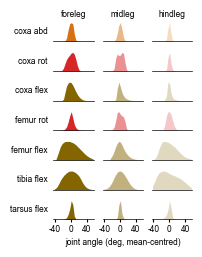

Saved: /home/user/3D_tracking_paper/fig_2_output/joint_angle_distributions_paper.svg
  y mode 'panel' | shared x -44.2 .. 57.5 deg (0.5-99.5 pct) | 26 bins
      joint           ROM T1/T2/T3 (deg)   peak density per tier
      coxa_abduct                  -/-/-   T1=0.0614  T2=0.0762  T3=0.1129
      coxa_twist                   -/-/-   T1=0.0385  T2=0.0434  T3=0.1135
      coxa                         -/-/-   T1=0.0369  T2=0.0726  T3=0.0884
      femur_twist                  -/-/-   T1=0.0684  T2=0.0453  T3=0.0521
      femur                        -/-/-   T1=0.0176  T2=0.0344  T3=0.0200
      tibia                        -/-/-   T1=0.0194  T2=0.0258  T3=0.0155
      tarsus                       -/-/-   T1=0.0883  T2=0.1119  T3=0.0962
Size: [44. 60.] mm
  x tick labels clear by 7.5 px


In [ ]:
# Cell 22 -- figure 2 - Joint angle distributions (publication)
# 44 mm x 60 mm, Arial 6 pt, SVG output
# Color by joint type (flex=#856500, abduct=#d67116, rot=#d62728)
# Opacity by tier: T1=1.0, T2=0.50, T3=0.25
# Histograms: per-bout density averaged across bouts (left+right pooled)
#
# Y AXIS: each panel is scaled to its OWN peak (Y_MODE='panel'). Density in
#   deg^-1 is ~1/spread, so a shared density limit costs the broad joints their
#   height: tibia reached 11-19% of the panel, tarsus 70-83%. Height now means
#   'fraction of this panel's own mode', and the number that got lost -- how wide
#   the distribution is -- is printed in the corner as the 5-95% ROM in degrees.
#   Say "peak-normalised" in the figure caption.
# X AXIS: one shared angle axis per COLUMN, spine + ticks on the bottom row only.
#   Per-panel tick pairs are what collided at 32 mm; three evenly spaced ticks
#   under the column read cleanly and cost no width. Rows above the bottom get
#   their baseline drawn in (axhline) since they have no spine.

import matplotlib as _mpl
import matplotlib.font_manager as _fm
_fm.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial.ttf")
_fm.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
_rc_orig = {k: _mpl.rcParams[k] for k in ('font.family', 'font.size',
                                            'pdf.fonttype', 'ps.fonttype',
                                            'svg.fonttype')}
# svg.fonttype='none' keeps text as TEXT in the SVG (font referenced by name),
# so it stays editable in Illustrator. matplotlib's default is 'path', which
# converts every glyph to outlines -- the SVG equivalent of the Type-3 problem
# that pdf.fonttype=42 exists to avoid.
_mpl.rcParams.update({'font.family': 'Arial', 'font.size': 6,
                      'pdf.fonttype': 42, 'ps.fonttype': 42,
                      'svg.fonttype': 'none'})

_JOINTS_PUB  = JOINT_SETS['main']          # 7 joints
_PAIRS_PUB   = [('T1', 'T1_left', 'T1_right'),
                ('T2', 'T2_left', 'T2_right'),
                ('T3', 'T3_left', 'T3_right')]
_N_BINS_PUB  = 26        # flat fills read cleaner with fewer, wider bins
_X_PCT       = (0.5, 99.5)   # percentiles that set the shared angle range
_XTICKS_DEG  = (-40, 0, 40)  # three ticks per column, bottom row only

Y_MODE       = 'panel'   # 'panel' = each panel scaled to its own peak
                         # 'all'   = one density limit for the whole grid (old)
                         # 'row'   = one density limit per joint row
SHOW_ROM     = False      # 5-95% ROM in degrees, top-right corner of each panel
FIG_W_MM     = 44        # 3 columns of 3 tick labels at 6 pt need ~40 mm
FIG_H_MM     = 60
LEG_TITLES   = {'T1': 'foreleg', 'T2': 'midleg', 'T3': 'hindleg'}

_JTYPE_COLOR = {'flex': '#856500', 'abduct': '#d67116', 'rot': '#d62728'}
_TIER_ALPHA  = {'T1': 1.0, 'T2': 0.50, 'T3': 0.25}


def _jcat(jname):
    if 'abduct' in jname: return 'abduct'
    if 'twist'  in jname: return 'rot'
    return 'flex'


# ── shared angle range across every joint x leg ─────────────────────────────
_lo_all, _hi_all = [], []
for _tier, _lL, _lR in _PAIRS_PUB:
    for _jnt in _JOINTS_PUB:
        for _col in (f"{_lL}_{_jnt}", f"{_lR}_{_jnt}"):
            if _col in df_mc.columns:
                _v = np.degrees(df_mc[_col].dropna().values.astype(float))
                if len(_v):
                    _lo_all.append(np.percentile(_v, _X_PCT[0]))
                    _hi_all.append(np.percentile(_v, _X_PCT[1]))
_XLO, _XHI = min(_lo_all), max(_hi_all)

fig_pub, axes_pub = plt.subplots(len(_JOINTS_PUB), 3,
                                 figsize=(FIG_W_MM / 25.4, FIG_H_MM / 25.4),
                                 sharex=True, sharey=True)

_peaks, _roms = {}, {}
for ci, (tier, leg_L, leg_R) in enumerate(_PAIRS_PUB):
    alpha = _TIER_ALPHA[tier]

    for ri, joint in enumerate(_JOINTS_PUB):
        ax    = axes_pub[ri, ci]
        color = _JTYPE_COLOR[_jcat(joint)]
        col_L, col_R = f"{leg_L}_{joint}", f"{leg_R}_{joint}"

        # all values, only to fix the histogram edges and the ROM label
        all_ang = []
        for _col in (col_L, col_R):
            if _col in df_mc.columns:
                all_ang.extend(np.degrees(df_mc[_col].dropna().values.astype(float)))
        if not all_ang:
            ax.axis('off')
            continue
        all_ang = np.asarray(all_ang)

        # bin over the SHARED range, not this panel's own min/max, so a broad
        # joint is not cut off mid-curve at the panel edge
        _edges   = np.linspace(_XLO, _XHI, _N_BINS_PUB + 1)
        _centers = (_edges[:-1] + _edges[1:]) / 2

        # per-bout averaged histogram (pool left+right)
        _densities = []
        for bid, grp in df_mc.groupby('bout_id', sort=False):
            _bout_ang = []
            for _col in (col_L, col_R):
                if _col in grp.columns:
                    _v = grp[_col].dropna().values.astype(float)
                    if len(_v): _bout_ang.extend(np.degrees(_v))
            if len(_bout_ang) < 2: continue
            _d, _ = np.histogram(_bout_ang, bins=_edges, density=True)
            _densities.append(_d)
        if not _densities:
            ax.axis('off')
            continue

        _mean_d = np.nanmean(np.vstack(_densities), axis=0)
        _peak   = float(np.nanmax(_mean_d))
        _peaks.setdefault(joint, []).append((tier, _peak))
        _y = _mean_d / _peak if Y_MODE == 'panel' else _mean_d

        # flat fill on a solid baseline -- no outline, no zero line
        ax.fill_between(_centers, _y, color=color, alpha=alpha, lw=0, zorder=2)

        ax.set_xlim(_XLO, _XHI)
        ax.set_yticks([])
        ax.tick_params(axis='y', left=False, labelleft=False, length=0)
        # no y spine anywhere, no x spine except under the bottom row
        for _s in ('left', 'right', 'top'):
            ax.spines[_s].set_visible(False)
        if ri < len(_JOINTS_PUB) - 1:
            # the shared x axis lives under the bottom row only, so rows above it
            # get their baseline drawn in instead of a spine
            ax.spines['bottom'].set_visible(False)
            ax.tick_params(axis='x', bottom=False)
            ax.axhline(0, color='black', lw=0.5, clip_on=False, zorder=4)

        if SHOW_ROM:
            _p5, _p95 = np.percentile(all_ang, [5, 95])
            _rom = int(round((_p95 - _p5) / 5) * 5)
            _roms[(joint, tier)] = _rom
            ax.text(0.995, 1.0, f'{_rom}', transform=ax.transAxes, fontsize=4.8,
                    ha='right', va='top', color='0.45')

        if ri == 0:
            ax.set_title(LEG_TITLES.get(tier, tier), fontsize=6, pad=3)
        if ci == 0:
            ax.set_ylabel(JOINT_LABELS.get(joint, joint).lower(), fontsize=6,
                          rotation=0, ha='right', va='center', labelpad=4)

# ── y limits ────────────────────────────────────────────────────────────────
_HEAD = 1.10
if Y_MODE == 'panel':
    _tops = {j: _HEAD for j in _peaks}
elif Y_MODE == 'row':
    _tops = {j: max(v for _t, v in _peaks[j]) * _HEAD for j in _peaks}
else:
    _g = max(v for j in _peaks for _t, v in _peaks[j]) * _HEAD
    _tops = {j: _g for j in _peaks}
for ri, joint in enumerate(_JOINTS_PUB):
    if joint not in _tops:
        continue
    for ci in range(3):
        axes_pub[ri, ci].set_ylim(0, _tops[joint])

# ── one x axis per column, under the bottom row ─────────────────────────────
for ci in range(3):
    _a = axes_pub[len(_JOINTS_PUB) - 1, ci]
    _a.set_xticks(list(_XTICKS_DEG))
    _a.set_xticklabels([f'{x:g}' for x in _XTICKS_DEG])
    _a.tick_params(axis='x', labelsize=6, pad=2, length=2)
    _a.spines['bottom'].set_linewidth(0.5)
axes_pub[len(_JOINTS_PUB) - 1, 1].set_xlabel('joint angle (deg, mean-centred)',
                                             fontsize=6, labelpad=3)

plt.subplots_adjust(left=0.19, right=0.99, top=0.945, bottom=0.105,
                    hspace=0.45, wspace=0.22)
_out_pub = OUTPUT_DIR / 'joint_angle_distributions_paper.svg'
fig_pub.savefig(_out_pub, bbox_inches='tight')
plt.show()

# ── diagnostics ─────────────────────────────────────────────────────────────
print(f'Saved: {_out_pub}')
print(f"  y mode '{Y_MODE}' | shared x {_XLO:.1f} .. {_XHI:.1f} deg "
      f"({_X_PCT[0]}-{_X_PCT[1]} pct) | {_N_BINS_PUB} bins")
print(f"      {'joint':<12}{'ROM T1/T2/T3 (deg)':>22}   peak density per tier")
for _j in _JOINTS_PUB:
    if _j not in _peaks:
        continue
    _r = '/'.join(str(_roms.get((_j, _t), '-')) for _t in ('T1', 'T2', 'T3'))
    _pk = '  '.join(f'{_t}={_v:.4f}' for _t, _v in _peaks[_j])
    print(f'      {_j:<12}{_r:>22}   {_pk}')
print(f'Size: {np.array(fig_pub.get_size_inches()) * 25.4} mm')

# do the tick labels physically fit?  (bottom row only now)
_rend = fig_pub.canvas.get_renderer()
_worst = None
for _ax in axes_pub.flat:
    _tl = [t for t in _ax.get_xticklabels() if t.get_text()]
    if len(_tl) < 2:
        continue
    _b = [t.get_window_extent(renderer=_rend) for t in _tl]
    _gap = min(_b[i + 1].x0 - _b[i].x1 for i in range(len(_b) - 1))
    if _worst is None or _gap < _worst:
        _worst = _gap
if _worst is not None and _worst < 2:
    print(f'  ! x tick labels COLLIDE (worst gap {_worst:.1f} px) -- widen '
          f'FIG_W_MM or drop a tick from _XTICKS_DEG')
else:
    print(f'  x tick labels clear by {_worst:.1f} px')

# restore rcParams
_mpl.rcParams.update(_rc_orig)


## 6. PCA phase portrait

2x3 LineCollection grid; each panel is one leg coloured by its step phase relative to L1, with shared PC1/PC2 limits across speed bins so loop size is comparable.


Fixed PC limits (per_bin_union)  PC1: [-14.23, 11.97]  PC2: [-14.81, 16.26]  (quantiles (0.0, 1.0), pad 3%)
      slow: 100.000% of frames inside the box
    medium: 100.000% of frames inside the box
      fast: 100.000% of frames inside the box
Speed bin 'slow': [0.00, 14.21) mm/s  → 142,046 frames after activity filter
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_slow_T1_left.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_slow_T2_left.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_slow_T3_left.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_slow_T1_right.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_slow_T2_right.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_slow_T3_right.png


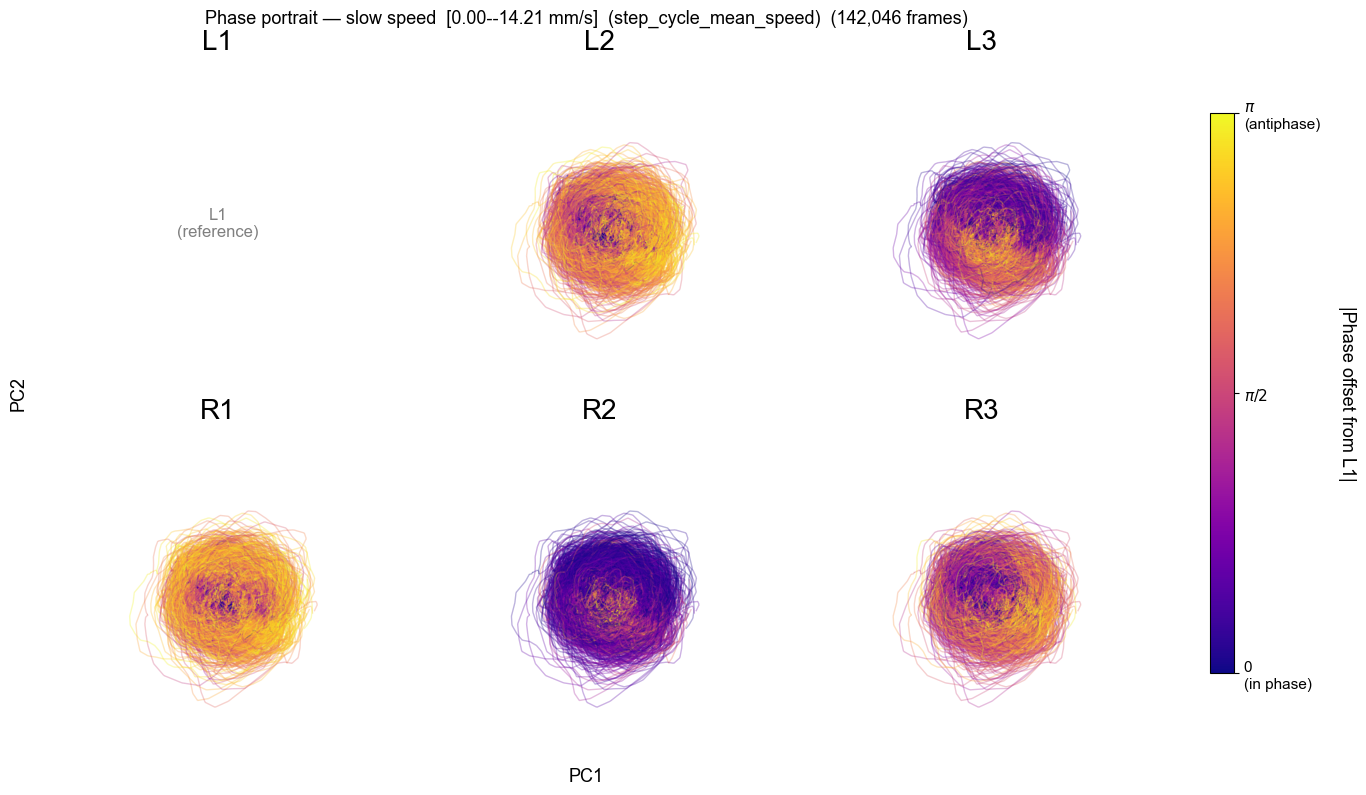

Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_slow.svg
Speed bin 'medium': [14.21, 21.89) mm/s  → 146,438 frames after activity filter
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_medium_T1_left.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_medium_T2_left.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_medium_T3_left.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_medium_T1_right.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_medium_T2_right.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_medium_T3_right.png


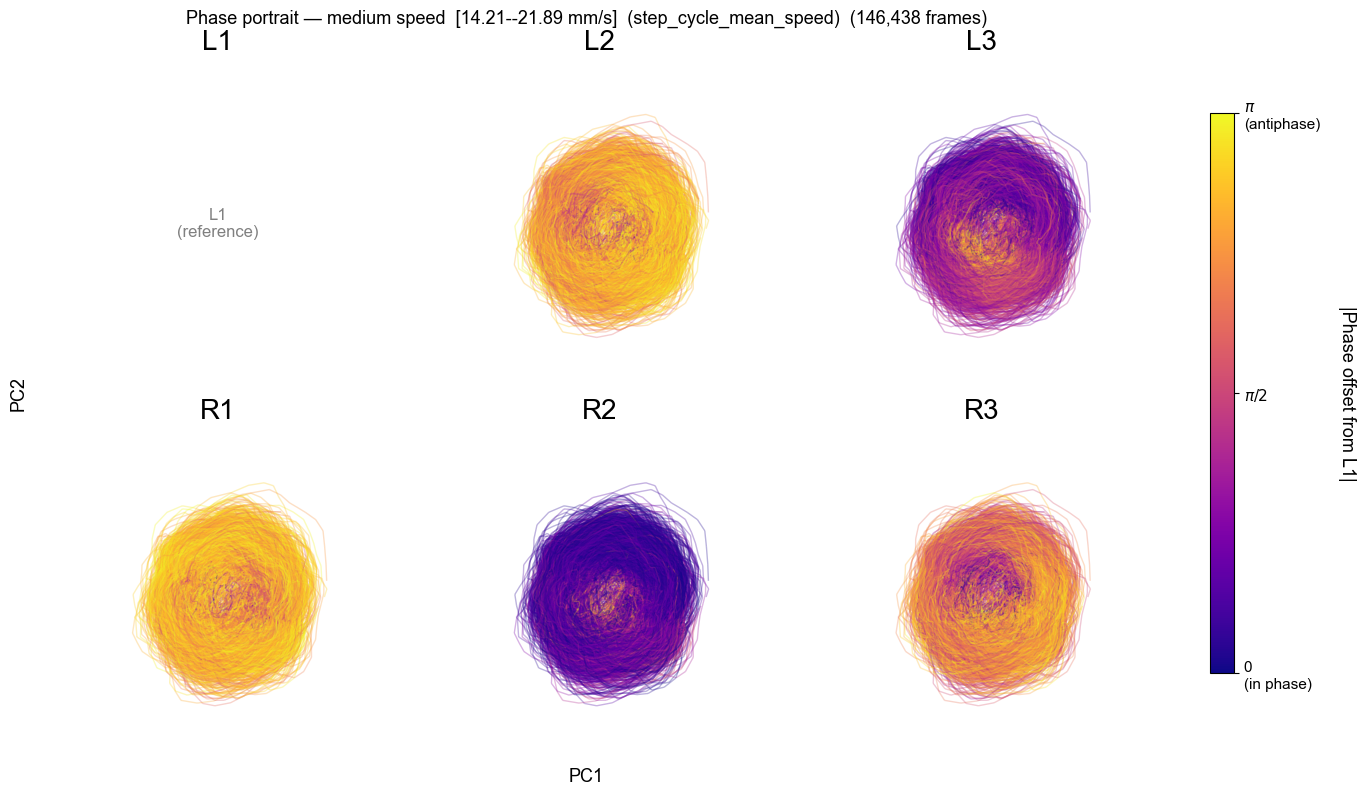

Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_medium.svg
Speed bin 'fast': [21.89, inf) mm/s  → 142,172 frames after activity filter
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_fast_T1_left.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_fast_T2_left.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_fast_T3_left.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_fast_T1_right.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_fast_T2_right.png
Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_fast_T3_right.png


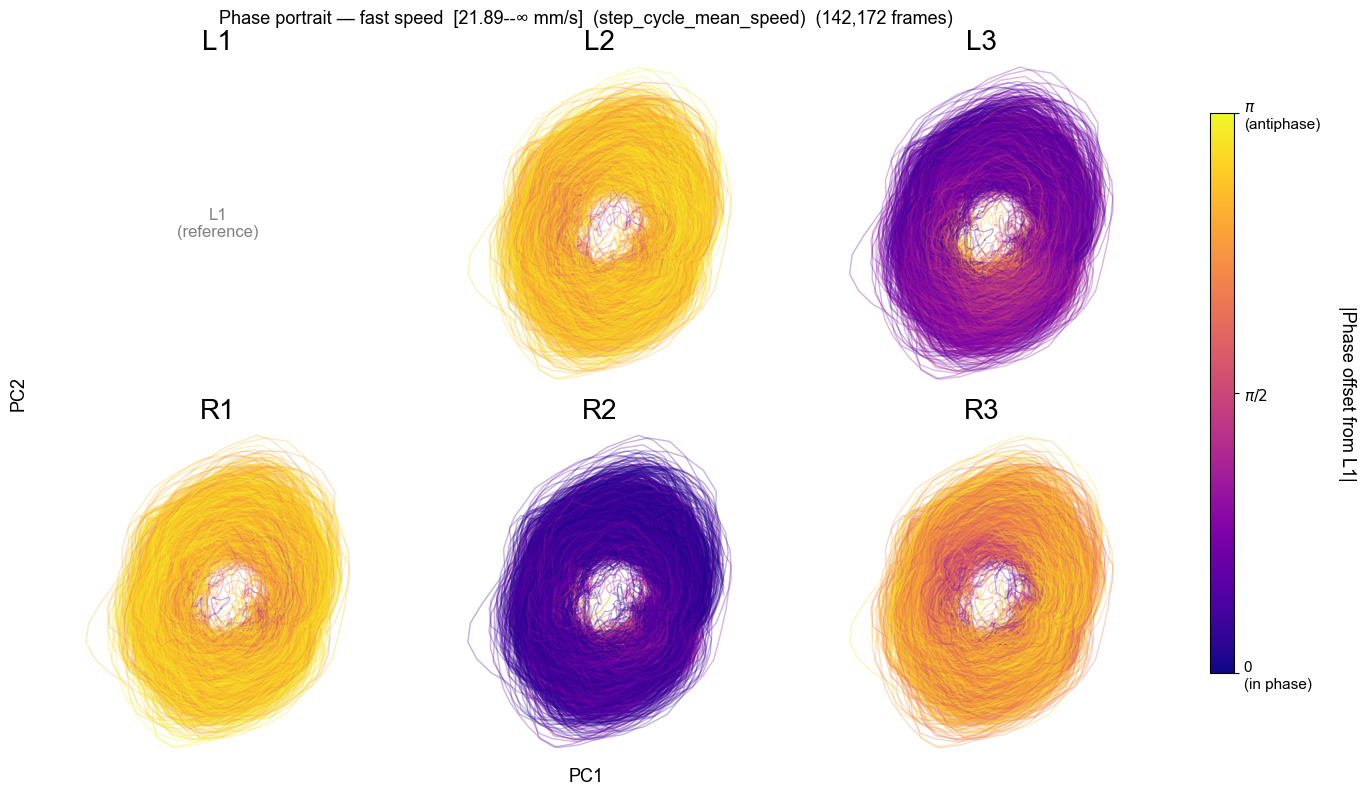

Saved: /home/user/3D_tracking_paper/fig_2_output/pca_phase_portrait_fast.svg


In [25]:
# Cell 23 -- FIGURE - Speed-binned PCA phase portrait
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# ── Phase display mode ──────────────────────────────────────────────────────────
# 'signed'  : [-π, π]  shows whether each leg LEADS (+) or LAGS (-) L1
#             +π/2 = leg is quarter-cycle ahead of L1
#             -π/2 = leg is quarter-cycle behind L1
#             ±π   = antiphase (half-cycle offset, same physical state)
# 'absolute': [0, π]   shows magnitude of offset only (in-phase vs antiphase)
#             0 = moves together with L1
#             π = alternates with L1
PHASE_MODE = 'absolute'   # change to 'absolute' to collapse lead/lag information

if PHASE_MODE == 'absolute':
    # PHASE_CMAP = 'RdYlGn_r'          # green = in phase, red = antiphase
    PHASE_CMAP = 'plasma'          # green = in phase, red = antiphase  ########## Modified by Elliott
    _norm      = Normalize(0, np.pi)
    _cb_ticks  = [0, np.pi / 2, np.pi]
    _cb_labels = ['0\n(in phase)', r'$\pi/2$', r'$\pi$' + '\n(antiphase)']
    _cb_title  = '|Phase offset from L1|'
else:  # signed
    PHASE_CMAP = 'twilight'               # circular: red at ±π (antiphase), green at 0
    _norm      = Normalize(-np.pi, np.pi)
    _cb_ticks  = [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]
    _cb_labels = [r'$-\pi$' + '\n(antiphase)', r'$-\pi/2$' + '\n(leg lags L1)',
                  '0\n(in phase)', r'$\pi/2$' + '\n(leg leads L1)',
                  r'$\pi$' + '\n(antiphase)']
    _cb_title  = 'Phase rel. to L1  (+ = leads, − = lags)'

# ── Activity mask ───────────────────────────────────────────────────────────────
# True  → keep only top 60% of frames by mean joint angular velocity
#          (removes slow/stationary frames but also discards slow locomotion)
# False → keep all frames with valid speed data (recommended for full comparison)
USE_ACTIVITY_MASK = False   # <- toggle here

# ── Speed binning column ────────────────────────────────────────────────────────
# 'forward_speed'         -- per-frame instantaneous body velocity (mm/s)
# 'step_cycle_mean_speed' -- mean speed over each T1_left step cycle (mm/s)
#                            (NaN frames at bout edges are excluded automatically)
SPEED_BIN_COL = 'step_cycle_mean_speed'   # <- toggle here

# ── Axis scaling ────────────────────────────────────────────────────────────────
# True  → all three speed-bin figures share ONE set of PC1/PC2 limits, computed
#         once over the whole plotted pool. Loop size is then directly comparable
#         across slow/medium/fast (the fast bin really does span a larger range).
# False → original behaviour: ax.autoscale() per figure, so each speed bin is
#         normalised to its own data and sizes CANNOT be compared across figures.
FIXED_PC_LIMITS = True    # <- toggle here

# True  → PC1 and PC2 drawn at equal aspect. They carry the same units (SDs of
#         the standardised feature space), so this is the undistorted rendering.
# False → original behaviour: x and y scaled independently.
EQUAL_ASPECT = True       # <- toggle here

# Percentile clip used to derive the fixed limits.
# (0.0, 1.0) = full min/max -> NOTHING is ever cut off (default).
# Tighten it (e.g. (0.001, 0.999)) only if a handful of outlier frames blow the
# box out and shrink every loop to a dot -- that trades clipping for readability.
PC_LIM_QUANTILES = (0.0, 1.0)
PC_LIM_PAD = 0.03         # fractional padding added to each side

# How the shared limits are derived:
# 'per_bin_union' → take the quantile range WITHIN each speed bin, then union
#                   across bins. Guarantees every bin fits inside the box,
#                   including 'fast'. (recommended)
# 'pooled'        → one quantile range over all frames at once. Cheaper, but the
#                   pool is dominated by slow+medium, so the fast bin's larger
#                   excursions fall outside the box and get clipped.
PC_LIM_SCOPE = 'per_bin_union'   # <- toggle here

# ── Activity mask (computed first so quantiles reflect the plotted pool) ────────
_spd_real_all = df_valid[SPEED_BIN_COL]
if USE_ACTIVITY_MASK and 'mean_abs_vel' in df_valid.columns:
    _MAV_THRESH    = df_valid['mean_abs_vel'].quantile(0.40)
    _activity_mask = df_valid['mean_abs_vel'] > _MAV_THRESH
else:
    _activity_mask = pd.Series(True, index=df_valid.index)

# ── Equal-count speed bins from the valid pool ──────────────────────────────────
# Each group contains ~1/3 of the frames that will actually be plotted.
_valid_pool = _activity_mask & _spd_real_all.notna()
_spd_valid  = _spd_real_all[_valid_pool]
_q33, _q67  = _spd_valid.quantile([0.33, 0.67]).values
SPEED_GROUPS = [
    ('slow',   0,     _q33),
    ('medium', _q33,  _q67),
    ('fast',   _q67,  np.inf),
]

# ── Global PC1/PC2 limits shared by all three speed-bin figures ────────────────
# One common scale for every figure, so loop sizes are comparable across speed
# bins. With PC_LIM_SCOPE='per_bin_union' the box is guaranteed to contain all
# three bins -- the pooled variant clips 'fast', which spans the widest range.
if FIXED_PC_LIMITS:
    def _global_lim(col):
        if PC_LIM_SCOPE == 'per_bin_union':
            _los, _his = [], []
            for _lbl, _lo_s, _hi_s in SPEED_GROUPS:
                _m = _valid_pool & (_spd_real_all >= _lo_s) & (_spd_real_all < _hi_s)
                if _m.sum() < 2:
                    continue
                _a, _b = df_valid.loc[_m, col].quantile(list(PC_LIM_QUANTILES)).values
                _los.append(_a); _his.append(_b)
            _lo, _hi = min(_los), max(_his)
        else:  # 'pooled'
            _lo, _hi = df_valid.loc[_valid_pool, col].quantile(list(PC_LIM_QUANTILES)).values
        _pad = PC_LIM_PAD * (_hi - _lo)
        return (_lo - _pad, _hi + _pad)

    PC1_LIM = _global_lim('PC1')
    PC2_LIM = _global_lim('PC2')
    print(f"Fixed PC limits ({PC_LIM_SCOPE})  "
          f"PC1: [{PC1_LIM[0]:.2f}, {PC1_LIM[1]:.2f}]  "
          f"PC2: [{PC2_LIM[0]:.2f}, {PC2_LIM[1]:.2f}]  "
          f"(quantiles {PC_LIM_QUANTILES}, pad {PC_LIM_PAD:.0%})")
    # report how much of each bin actually falls inside the box (want 100.000%)
    for _lbl, _lo_s, _hi_s in SPEED_GROUPS:
        _m = _valid_pool & (_spd_real_all >= _lo_s) & (_spd_real_all < _hi_s)
        if _m.sum() == 0:
            continue
        _in = ((df_valid.loc[_m, 'PC1'].between(*PC1_LIM)) &
               (df_valid.loc[_m, 'PC2'].between(*PC2_LIM))).mean()
        print(f"    {_lbl:>6}: {_in:8.3%} of frames inside the box"
              + ("" if _in == 1.0 else "   <-- CLIPPED, widen PC_LIM_QUANTILES"))
else:
    PC1_LIM = PC2_LIM = None
    print("FIXED_PC_LIMITS = False -> each figure autoscales independently; "
          "loop sizes are NOT comparable across speed bins.")

# ── Compute phase of each leg relative to L1 (T1_left) ──────────────────────────
_ref_phase = df_valid['T1_left_phase'].values
for _leg in LEGS:
    if _leg == 'T1_left':
        continue
    _diff = df_valid[f'{_leg}_phase'].values - _ref_phase
    df_valid[f'{_leg}_phase_rel_L1'] = np.arctan2(np.sin(_diff), np.cos(_diff))

# ── Build bout-safe LineCollection segments ──────────────────────────────────────
def make_lc_segments(df, mask, x_col, y_col):
    """(N, 2, 2) segment array skipping across-bout joins."""
    all_segs = []
    for _, grp in df[mask].groupby('bout_id', sort=False):
        pts = grp[[x_col, y_col]].values
        if len(pts) < 2:
            continue
        all_segs.append(np.concatenate([pts[:-1, np.newaxis],
                                         pts[1:,  np.newaxis]], axis=1))
    return np.concatenate(all_segs, axis=0) if all_segs else np.empty((0, 2, 2))



leg_mat  = [['T1_left', 'T2_left', 'T3_left'],
            ['T1_right','T2_right','T3_right']]

# ── One figure per speed bin ─────────────────────────────────────────────────────
for _label, _spd_lo, _spd_hi in SPEED_GROUPS:
    _spd_mask = (_spd_real_all >= _spd_lo) & (_spd_real_all < _spd_hi)
    _n_frames = (_spd_mask & _activity_mask).sum()
    print(f"Speed bin '{_label}': [{_spd_lo:.2f}, {_spd_hi:.2f}) mm/s  "
          f"→ {_n_frames:,} frames after activity filter")

    fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
    _last_lc = None

    for i, row_legs in enumerate(leg_mat):
        for j, leg in enumerate(row_legs):
            ax = axes[i, j]
            ax.set_title(LEG_LABELS[leg], fontsize=20)
            ax.set_axis_off()

            if leg == 'T1_left':          # reference leg
                ax.text(0.5, 0.5, 'L1\n(reference)', ha='center', va='center',
                        transform=ax.transAxes, fontsize=12, color='gray')
                continue

            phase_col = f'{leg}_phase_rel_L1'
            if phase_col not in df_valid.columns:
                continue

            _mask = _activity_mask & _spd_mask & df_valid[phase_col].notna()
            segs  = make_lc_segments(df_valid, _mask, 'PC1', 'PC2')
            if len(segs) == 0:
                continue

            seg_colors = []
            for _, grp in df_valid[_mask].groupby('bout_id', sort=False):
                c = grp[phase_col].values
                if len(c) < 2:
                    continue
                _c = np.abs(c[:-1]) if PHASE_MODE == 'absolute' else c[:-1]
                seg_colors.extend(_c)
            seg_colors = np.array(seg_colors)

            lc = LineCollection(segs, cmap=PHASE_CMAP, norm=_norm, linewidth=1, alpha=0.3, rasterized=True) ########## Modified by Elliott
            lc.set_array(seg_colors)
            ax.add_collection(lc)
            if FIXED_PC_LIMITS:
                ax.set_xlim(*PC1_LIM)
                ax.set_ylim(*PC2_LIM)
            else:
                ax.autoscale()
            if EQUAL_ASPECT:
                ax.set_aspect('equal', adjustable='box')
            _last_lc = lc

    if _last_lc is not None:
        cbar_ax = fig.add_axes([1.02, 0.15, 0.02, 0.7])
        cbar    = fig.colorbar(_last_lc, cax=cbar_ax)
        cbar.set_ticks(_cb_ticks)
        cbar.set_ticklabels(_cb_labels, fontsize=11)
        cbar.set_label(_cb_title, rotation=270, labelpad=26, fontsize=13)
        cbar.solids.set_alpha(1)


    _spd_hi_str = f'{_spd_hi:.2f}' if np.isfinite(_spd_hi) else '∞'
    fig.suptitle(f'Phase portrait — {_label} speed  '
                 f'[{_spd_lo:.2f}--{_spd_hi_str} mm/s]  ({SPEED_BIN_COL})  ({_n_frames:,} frames)',
                 fontsize=13)
    fig.supxlabel('PC1', fontsize=13)
    fig.supylabel('PC2', fontsize=13)
    plt.tight_layout()
    _fname = OUTPUT_DIR / f'pca_phase_portrait_{_label}.svg'
    plt.savefig(_fname, bbox_inches='tight',dpi=300)
    # Save each leg panel as a separate transparent PNG for Inkscape.
    # OPTIMISED: the old version called fig.savefig(bbox_inches=<panel bbox>) once
    # per panel, and EACH of those re-rendered the whole 6-panel figure (all five
    # ~222k-segment LineCollections) -- 18 extra full renders across the 3 speed
    # bins. Now the figure is drawn ONCE at the export dpi and the RGBA buffer is
    # cropped per panel. Measured 9.76 s -> 5.55 s per bin; crops agree with the
    # old ones to within 1 px and 0.6% ink coverage.
    _EXPORT_DPI = 150
    _old_dpi   = fig.get_dpi()
    _fig_alpha = fig.patch.get_alpha()
    _ax_alphas = [(_a, _a.patch.get_alpha()) for _a in fig.axes]
    fig.set_dpi(_EXPORT_DPI)
    fig.patch.set_alpha(0.0)                      # == savefig(transparent=True)
    for _a, _ in _ax_alphas:
        _a.patch.set_alpha(0.0)
    fig.canvas.draw()
    _buf = np.asarray(fig.canvas.buffer_rgba())
    _H, _W = _buf.shape[:2]
    _renderer = fig.canvas.get_renderer()
    for _i, _row_legs in enumerate(leg_mat):
        for _j, _leg in enumerate(_row_legs):
            _ax = axes[_i, _j]
            _bbox = _ax.get_tightbbox(_renderer)
            if _bbox is None:
                continue
            _bb = _bbox.expanded(1.08, 1.08)
            _x0 = max(int(np.floor(_bb.x0)), 0); _x1 = min(int(np.ceil(_bb.x1)), _W)
            _y0 = max(int(np.floor(_bb.y0)), 0); _y1 = min(int(np.ceil(_bb.y1)), _H)
            if _x1 <= _x0 or _y1 <= _y0:
                continue
            _png_fname = OUTPUT_DIR / f'pca_phase_portrait_{_label}_{_leg}.png'
            plt.imsave(_png_fname, _buf[_H - _y1:_H - _y0, _x0:_x1])   # y-flip
            print(f"Saved: {_png_fname}")
    fig.patch.set_alpha(_fig_alpha)
    for _a, _al in _ax_alphas:
        _a.patch.set_alpha(_al)
    fig.set_dpi(_old_dpi)
    plt.show()
    print(f"Saved: {_fname}")

## 7. Range of motion

Per-step-cycle ROM for 7 joints x 6 legs, built once here and reused by section 8.

[memo] rom_per_cycle: computed in 0.2s


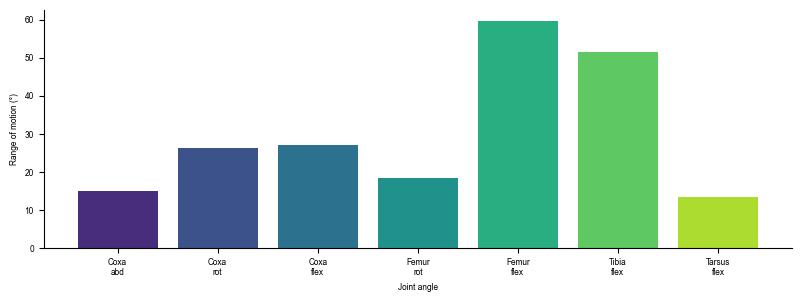

Saved: /home/user/3D_tracking_paper/fig_2_output/rom_bar_T1.pdf


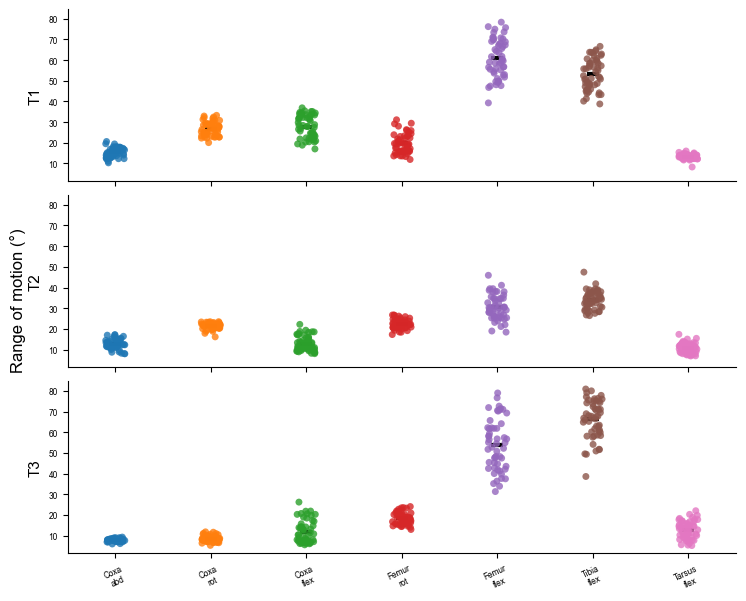

Saved: /home/user/3D_tracking_paper/fig_2_output/rom_per_fly_strips.pdf


In [ ]:
# Cell 24 -- BUILDS FOR FIGURE 2, actual figure in next cell - Per-cycle ROM table + ROM by joint and fly
# ── Config ────────────────────────────────────────────────────────────────────
ROM_JOINTS = ['coxa_abduct', 'coxa_twist', 'coxa', 'femur_twist', 'femur', 'tibia', 'tarsus']                                                                                              
ROM_LABELS = ['Coxa\nabd', 'Coxa\nrot', 'Coxa\nflex', 'Femur\nrot',                                                                                                                           
              'Femur\nflex', 'Tibia\nflex', 'Tarsus\nflex']                                                                                                                                   
LEG_TIERS  = [('T1', 'T1_left', 'T1_right'),                                                                                                                                                  
              ('T2', 'T2_left', 'T2_right'),                                                                                                                                                  
              ('T3', 'T3_left', 'T3_right')]                                                                                                                                                  
                                                                                                                                                                                              
# ── Shared per-cycle ROM table (replaces ~2,198 groupby.agg(lambda) calls) ────
# Cell 24 and Cell 26 computed the SAME quantity with two different slow loops.
# Both now read one memoised table. Measured: groupby.agg(lambda) 0.16 s per column
# per call -> ~6 min for this cell; the reduceat pass below does all 66 joint
# columns for all ~13k cycles in ~0.1 s.
#
# VERIFIED against the old groupby path on real data: identical group count,
# identical NaN pattern (including the <2-finite-value edge case), and values
# agreeing to 1.65e-7 relative at worst. That residual is NOT an algorithmic
# difference -- the old path accumulated the mean in float32 (qpos is float32
# out of the HDF5), this one accumulates in float64, so the new values are very
# slightly MORE accurate. On a ROM of 15-60 degrees that is ~1e-5 degrees.
_ROM_ALL_COLS = [f'{lg}_{j}' for lg in LEGS for j in JOINT_SETS['full']
                 if f'{lg}_{j}' in df_valid.columns]
assert len(df_valid) == len(df), "df_valid is not a full copy of df -- ROM table sharing is unsafe"

@memo('rom_per_cycle', tuple(_ROM_ALL_COLS), data_tag(df_valid))
def ROM_CYC():
    _sc  = df_valid['step_cycle_id'].to_numpy()
    _ok  = np.isfinite(_sc)
    _A   = block(df_valid, _ROM_ALL_COLS)[_ok]
    _b   = df_valid['bout_idx'].to_numpy()[_ok]
    _s   = _sc[_ok]
    _st, _en = runs(_b, _s)                       # contiguous (bout, cycle) segments
    _cnt = seg_cnt(_A, _st)
    _rom = np.where(_cnt >= 2, np.degrees(seg_max(_A, _st) - seg_min(_A, _st)), np.nan)
    return dict(
        cols  = _ROM_ALL_COLS,
        rom   = _rom,                                                     # (n_cyc, n_col) degrees
        dur   = (_en - _st),                                              # == len(cyc)
        fly   = df_valid['fly_id'].to_numpy()[_ok][_st],
        bout  = df_valid['bout_id'].to_numpy()[_ok][_st],
        speed = df_valid['step_cycle_mean_speed'].to_numpy()[_ok][_st],
        scid  = _s[_st],
    )

_ROM_CI = {c: i for i, c in enumerate(ROM_CYC['cols'])}

def rom_per_cycle(data, col):
    """Mean per-cycle ROM (max-min per step cycle) in degrees.

    Signature preserved. `data` is used only to select which cycles participate
    (all cycles, or one fly's) -- the per-cycle values come from ROM_CYC.
    """
    if col not in _ROM_CI:
        return np.nan
    v = ROM_CYC['rom'][:, _ROM_CI[col]]
    if len(data) != len(df_valid):                       # a per-fly subset
        flies = pd.unique(data['fly_id'])
        v = v[np.isin(ROM_CYC['fly'], flies)]
    return np.nanmean(v) if np.isfinite(v).any() else np.nan
# ── Part 1: Bar chart — T1 joint ROM (L+R averaged, all cycles) ───────────────
roms_bar = []
for joint in ROM_JOINTS:
    col_L = f'T1_left_{joint}'
    col_R = f'T1_right_{joint}'
    rom_L = rom_per_cycle(df_valid, col_L)
    rom_R = rom_per_cycle(df_valid, col_R)
    roms_bar.append(np.nanmean([rom_L, rom_R]))
plt.figure(figsize=(8, 3))
plt.bar(range(len(roms_bar)), roms_bar, tick_label=ROM_LABELS, align='center',
        color=sns.color_palette('viridis', len(roms_bar)))
plt.xlabel('Joint angle')
plt.ylabel('Range of motion (°)')
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rom_bar_T1.pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'rom_bar_T1.pdf'}")
# ── Part 2: Per-fly strip+point plot (3 rows × n_joints) ──────────────────────
# Vectorised: was 52 flies x 3 tiers x 7 joints x 2 legs = 2,184 rom_per_cycle
# calls, each preceded by a full-frame df_valid[df_valid['fly_id']==fly] take.
_rom_mat = ROM_CYC['rom']
_rom_fly = ROM_CYC['fly']
rom_records = {}
for fly_id in df_valid['fly_id'].unique():          # appearance order preserved
    _m  = _rom_fly == fly_id
    _sub = _rom_mat[_m]
    row = {}
    for tier, leg_L, leg_R in LEG_TIERS:
        for joint in ROM_JOINTS:
            col_L, col_R = f'{leg_L}_{joint}', f'{leg_R}_{joint}'
            if col_L in _ROM_CI and col_R in _ROM_CI:
                _l = _sub[:, _ROM_CI[col_L]]; _r = _sub[:, _ROM_CI[col_R]]
                row[f'{tier}_{joint}'] = np.nanmean([
                    np.nanmean(_l) if np.isfinite(_l).any() else np.nan,
                    np.nanmean(_r) if np.isfinite(_r).any() else np.nan,
                ])
    rom_records[fly_id] = row
rom_by_fly = pd.DataFrame(rom_records).T
fig, axes = plt.subplots(3, 1, figsize=(7.5, 6), sharex=True, sharey=True)
for ax, (tier, _L, _R) in zip(axes, LEG_TIERS):
    cols   = [f'{tier}_{j}' for j in ROM_JOINTS]
    avail  = [c for c in cols if c in rom_by_fly.columns]
    labels = [ROM_LABELS[ROM_JOINTS.index(c.replace(tier + '_', ''))]
              for c in avail]
    data   = rom_by_fly[avail].copy()
    data.columns = labels
    sns.stripplot(data=data, ax=ax, palette='tab10', size=5, alpha=0.8)
    sns.pointplot(data=data, ax=ax, join=False, errorbar=None,
                  estimator='mean', color='k', markers='_', scale=1.5)
    ax.set_ylabel(tier, fontsize=11)
    sns.despine(ax=ax)
axes[-1].tick_params(axis='x', rotation=25)
fig.supylabel('Range of motion (°)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rom_per_fly_strips.pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'rom_per_fly_strips.pdf'}")

## 8. Speed–ROM correlation


In [29]:
# Cell 25 -- Speed-ROM configuration
ROM_JOINT_SET        = 'main'   # 'core' | 'main' | 'full'
ROM_MIN_CYCLE_FRAMES = 10       # skip step cycles shorter than this (frames)
ROM_N_SPEED_BINS     = 3       # number of speed quantile bins for Approach B


Step cycles: 5244  |  flies: 53  |  speed range: 0.6–59.8 mm/s


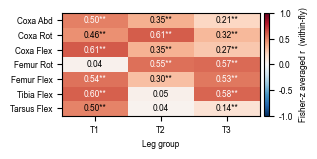

Saved: /home/user/3D_tracking_paper/fig_2_output/speedrom_A_main_within_fly_merged.svg

Top 10 by |r̄|  (within_fly, N in flies):
  joint-leg                         r̄           p      N
  T1_coxa                        0.611    1.26e-28     52
  T2_coxa_twist                  0.608    1.33e-27     52
  T1_tibia                       0.602    2.09e-26     52
  T3_tibia                       0.583    3.80e-33     52
  T3_femur_twist                 0.566    7.17e-29     52
  T2_femur_twist                 0.548    2.39e-23     52
  T1_femur                       0.544    1.41e-25     52
  T3_femur                       0.526    2.51e-26     52
  T1_coxa_abduct                 0.502    9.68e-21     52
  T1_tarsus                      0.498    7.67e-19     52


In [30]:
# Cell 26 -- FIGURE - Per-cycle ROM x speed correlation
from scipy.stats import pearsonr, spearmanr, ttest_1samp

# ── Toggles ───────────────────────────────────────────────────────────────────
# MERGE_CONTRALATERAL:
#   True  → average L+R ROM per tier before correlating (3 columns: T1/T2/T3)
#   False → each leg separately (6 columns)
MERGE_CONTRALATERAL = True   # <- change here

# STAT_METHOD — choose one:
#   'pearson'     — Pearson r across all strides
#                   Fast; assumes linearity. p-values optimistic (pseudoreplication).
#   'spearman'    — Spearman ρ across all strides
#                   No linearity assumption, robust to outliers. Same caveat on p.
#   'per_fly'     — Pearson r on per-fly mean ROM vs mean speed (N = n flies)
#                   Conservative; removes pseudoreplication but discards
#                   within-fly variance.
#   'within_fly'  — Per-fly Pearson r, averaged via Fisher z-transform.
#                   Uses all stride-level variance but keeps flies as the
#                   unit of inference. p-value from one-sample t-test on z scores
#                   (no external libraries needed).
STAT_METHOD = 'within_fly'   # <- change here

_rom_joints = JOINT_SETS[ROM_JOINT_SET]
_n_rj       = len(_rom_joints)
_TIER_PAIRS = [('T1', 'T1_left', 'T1_right'),
               ('T2', 'T2_left', 'T2_right'),
               ('T3', 'T3_left', 'T3_right')]

# -- Build per-cycle ROM DataFrame -------------------------------------------
# Reads the shared ROM_CYC table built in Cell 24 instead of recomputing it.
# Was: ~13k groups x 42 (leg x joint) = ~550,000 pandas column extractions on
# ~40-row slices, plus a 442k x 264 (~0.93 GB) .copy(). Now a masked take.
# Semantics preserved exactly: the ROM_MIN_CYCLE_FRAMES filter stays LOCAL to this
# cell (Cell 24 deliberately applies no duration filter), and `duration` is the
# full cycle length including rows whose joint value is NaN, as before.
_k = ROM_CYC['dur'] >= ROM_MIN_CYCLE_FRAMES
rom_df = pd.DataFrame({
    'bout_id':  ROM_CYC['bout'][_k],
    'speed':    ROM_CYC['speed'][_k].astype(float),
    'duration': ROM_CYC['dur'][_k],
    'fly_id':   ROM_CYC['fly'][_k],
})
for leg in LEGS:
    for jnt in _rom_joints:
        col = f'{leg}_{jnt}'
        if col in _ROM_CI:
            rom_df[col] = ROM_CYC['rom'][_k, _ROM_CI[col]]
print(f'Step cycles: {len(rom_df)}  |  flies: {rom_df["fly_id"].nunique()}  |  '
      f'speed range: {rom_df["speed"].min():.1f}–{rom_df["speed"].max():.1f} mm/s')

# -- Add averaged contralateral columns to rom_df ----------------------------
for tier, leg_L, leg_R in _TIER_PAIRS:
    for jnt in _rom_joints:
        rom_df[f'{tier}_{jnt}'] = rom_df[[f'{leg_L}_{jnt}', f'{leg_R}_{jnt}']].mean(axis=1, skipna=True)

# -- Statistical test dispatcher ---------------------------------------------
def _compute_stat(speed_vals, rom_vals, fly_id_vals, method):
    """Return (effect_size, p_value, n_used) for the chosen method."""
    mask = np.isfinite(speed_vals) & np.isfinite(rom_vals)
    xs, ys, fids = speed_vals[mask], rom_vals[mask], fly_id_vals[mask]
    n = mask.sum()
    if n < 10:
        return np.nan, np.nan, n

    if method == 'pearson':
        r, p = pearsonr(xs, ys)
        return r, p, n

    elif method == 'spearman':
        r, p = spearmanr(xs, ys)
        return r, p, n

    elif method == 'per_fly':
        tmp = pd.DataFrame({'speed': xs, 'rom': ys, 'fly_id': fids})
        fly_means = tmp.groupby('fly_id')[['speed', 'rom']].mean()
        nf = len(fly_means)
        if nf < 4:
            return np.nan, np.nan, nf
        r, p = pearsonr(fly_means['speed'].values, fly_means['rom'].values)
        return r, p, nf

    elif method == 'within_fly':
        # Per-fly Pearson r, averaged via Fisher z-transform.
        # p-value: one-sample t-test on z scores (H0: mean z = 0).
        tmp = pd.DataFrame({'speed': xs, 'rom': ys, 'fly_id': fids})
        z_scores = []
        for fid, grp in tmp.groupby('fly_id'):
            if len(grp) < 5:
                continue
            r_fly, _ = pearsonr(grp['speed'].values, grp['rom'].values)
            # clip to avoid arctanh(±1) = ±inf
            r_fly = np.clip(r_fly, -0.9999, 0.9999)
            z_scores.append(np.arctanh(r_fly))
        nf = len(z_scores)
        if nf < 3:
            return np.nan, np.nan, nf
        z_arr = np.array(z_scores)
        r_avg = np.tanh(z_arr.mean())          # back-transform mean z → r
        _, p  = ttest_1samp(z_arr, 0)          # H0: no within-fly correlation
        return r_avg, p, nf

    else:
        raise ValueError(f'Unknown STAT_METHOD: {method!r}')

# -- Compute effect-size and p matrix ----------------------------------------
if MERGE_CONTRALATERAL:
    _col_labels = [tier for tier, *_ in _TIER_PAIRS]
    _n_cols     = len(_TIER_PAIRS)
    def _get_rom_col(jnt, ci): return f'{_col_labels[ci]}_{jnt}'
else:
    _col_labels = ['L1', 'R1', 'L2', 'R2', 'L3', 'R3']
    _n_cols     = len(LEGS)
    def _get_rom_col(jnt, ci): return f'{LEGS[ci]}_{jnt}'

r_matrix = np.full((_n_rj, _n_cols), np.nan)
p_matrix = np.full((_n_rj, _n_cols), np.nan)
n_matrix = np.zeros((_n_rj, _n_cols), dtype=int)

_spd  = rom_df['speed'].values.astype(float)
_fids = rom_df['fly_id'].values

for ji, jnt in enumerate(_rom_joints):
    for ci in range(_n_cols):
        col = _get_rom_col(jnt, ci)
        rom_vals = rom_df[col].values.astype(float)
        eff, p, n = _compute_stat(_spd, rom_vals, _fids, STAT_METHOD)
        r_matrix[ji, ci] = eff
        p_matrix[ji, ci] = p
        n_matrix[ji, ci] = n

# -- Heatmap ------------------------------------------------------------------
import matplotlib.font_manager as _fm2
import matplotlib.colors as _mcolors
from matplotlib.cm import ScalarMappable
import matplotlib as _mpl2

_fm2.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial.ttf")
_mpl2.rcParams.update({'font.family': 'Arial', 'font.size': 6,
                        'axes.labelsize': 6, 'axes.titlesize': 6,
                        'xtick.labelsize': 6, 'ytick.labelsize': 6,
                        'pdf.fonttype': 42})

_jnt_labels = [JOINT_LABELS.get(j, j.replace('_', ' ')) for j in _rom_joints]

_cbar_labels = {
    'pearson':    'Pearson r  (all strides)',
    'spearman':   'Spearman ρ  (all strides)',
    'per_fly':    'Pearson r  (fly means)',
    'within_fly': 'Fisher-z averaged r  (within-fly)',
}
_n_label = {
    'pearson':    'strides', 'spearman': 'strides',
    'per_fly':    'flies',   'within_fly': 'flies',
}
from matplotlib.colors import TwoSlopeNorm

# Slice RdYlGn from 0.25 (light orange) to 1.0 (bright green), skipping red
_rdylgn  = plt.get_cmap('RdYlGn')
_cmap_g  = _mcolors.LinearSegmentedColormap.from_list(
    'OrangeGreen', [_rdylgn(x) for x in np.linspace(0.25, 1.0, 256)])
_norm_div = TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

fig_a, ax_a = plt.subplots(figsize=(80 / 25.4, 40 / 25.4))
# im = ax_a.imshow(r_matrix, cmap=_cmap_g, vmin=-0.2, vmax=0.8, aspect='auto')
im = ax_a.imshow(r_matrix, cmap='RdBu_r', norm=_norm_div, aspect='auto') ########### Modified by Elliott
cbar = plt.colorbar(im, ax=ax_a, label=_cbar_labels[STAT_METHOD], fraction=0.05, pad=0.02,norm=_norm_div)
cbar.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])
cbar.set_ticklabels(['-1.0', '-0.5', '0.0', '0.5', '1.0'])


for ji in range(_n_rj):
    for ci in range(_n_cols):
        r = r_matrix[ji, ci];  p = p_matrix[ji, ci]
        if np.isnan(r): continue
        stars = '**' if p < 0.01 else ('*' if p < 0.05 else '')
        ax_a.text(ci, ji, f'{r:.2f}{stars}', ha='center', va='center',
                  fontsize=6, color='white' if r > 0.5 else 'black')

if not MERGE_CONTRALATERAL:
    for x in [1.5, 3.5]:
        ax_a.axvline(x, color='white', lw=2)

ax_a.set_xticks(range(_n_cols))
ax_a.set_xticklabels(_col_labels)
ax_a.set_yticks(range(_n_rj))
ax_a.set_yticklabels(_jnt_labels)
ax_a.set_xlabel('Leg group' if MERGE_CONTRALATERAL else 'Leg')
plt.tight_layout()
_pdf_a = OUTPUT_DIR / f'speedrom_A_{ROM_JOINT_SET}_{STAT_METHOD}{"_merged" if MERGE_CONTRALATERAL else ""}.svg'
plt.savefig(_pdf_a, bbox_inches='tight')
plt.show()
print(f'Saved: {_pdf_a}')

# -- Top 10 pairs -------------------------------------------------------------
_pairs = []
for ji, jnt in enumerate(_rom_joints):
    for ci in range(_n_cols):
        r, p = r_matrix[ji, ci], p_matrix[ji, ci]
        if not np.isnan(r):
            _pairs.append((abs(r), r, p, n_matrix[ji, ci], f'{_col_labels[ci]}_{jnt}'))
_pairs.sort(reverse=True)
_effect_name = {'pearson': 'r', 'spearman': 'ρ', 'per_fly': 'r', 'within_fly': 'r̄'}[STAT_METHOD]
print(f'\nTop 10 by |{_effect_name}|  ({STAT_METHOD}, N in {_n_label[STAT_METHOD]}):')
print(f'  {"joint-leg":<28}  {_effect_name:>6}  {"p":>10}  {"N":>5}')
for _, r, p, n, name in _pairs[:10]:
    print(f'  {name:<28}  {r:>6.3f}  {p:>10.2e}  {n:>5}')

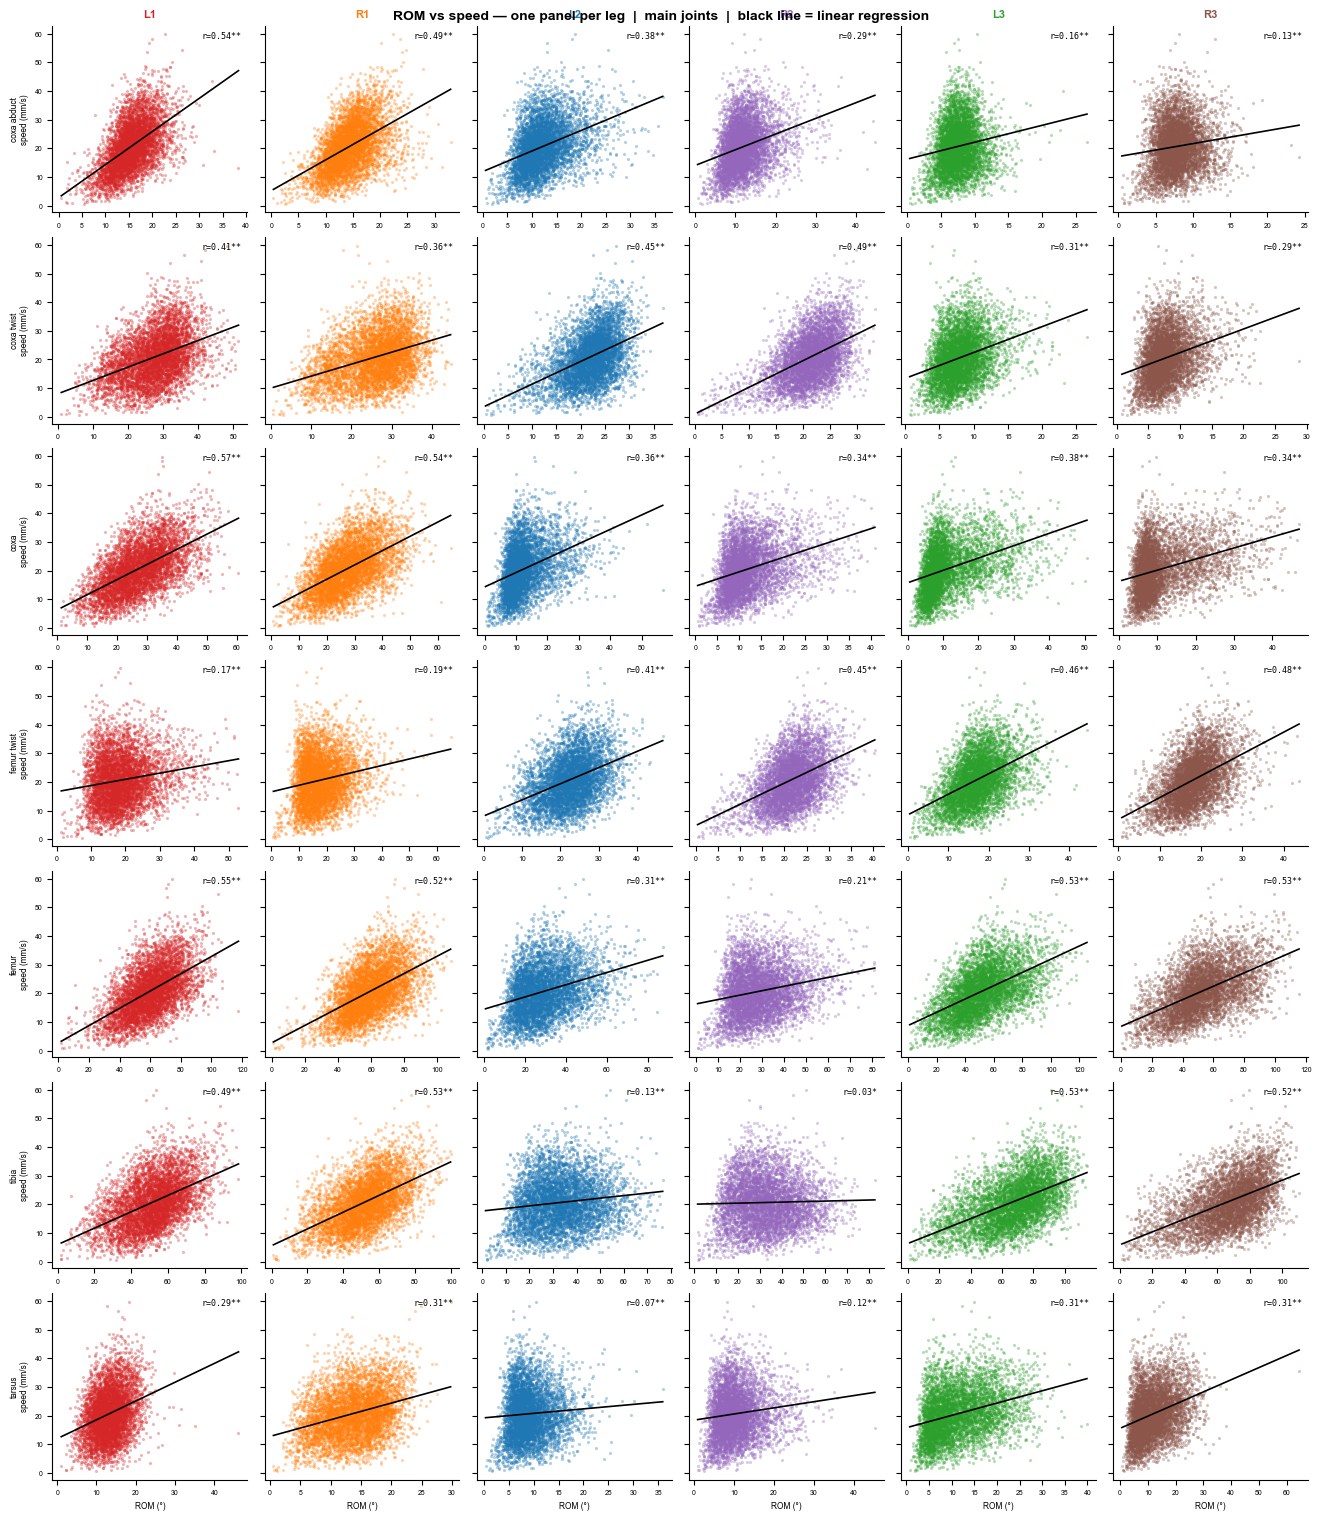

Saved: /home/user/3D_tracking_paper/fig_2_output/speedrom_scatter_per_leg_main.pdf


In [31]:
# Cell 27 -- FIGURE - ROM vs speed scatter + regression
# Requires: rom_df from Cell 26
from scipy.stats import linregress

try:
    _ = rom_df
except NameError:
    raise RuntimeError('rom_df not found. Run Cell 26 first.')

_leg_clr = globals().get('FIG2_LEG_COLORS', {
    'T1_left': '#d62728', 'T1_right': '#ff7f0e',
    'T2_left': '#1f77b4', 'T2_right': '#9467bd',
    'T3_left': '#2ca02c', 'T3_right': '#8c564b',
})

_joints   = JOINT_SETS[ROM_JOINT_SET]
_leg_abbr = ['L1', 'R1', 'L2', 'R2', 'L3', 'R3']

fig61, axes61 = plt.subplots(
    len(_joints), len(LEGS),
    figsize=(2.2 * len(LEGS), 2.2 * len(_joints)),
    sharex=False, sharey='row',
    squeeze=False,
)

for ji, jnt in enumerate(_joints):
    for li, (leg, abbr) in enumerate(zip(LEGS, _leg_abbr)):
        ax  = axes61[ji, li]
        col = f'{leg}_{jnt}'
        mask = rom_df[[col, 'speed']].notna().all(axis=1)
        x = rom_df.loc[mask, col].values
        y = rom_df.loc[mask, 'speed'].values

        ax.scatter(x, y, color=_leg_clr[leg], s=5, alpha=0.35, linewidths=0)

        if len(x) >= 4:
            slope, intercept, r_val, p_val, _ = linregress(x, y)
            _xl = np.linspace(x.min(), x.max(), 200)
            ax.plot(_xl, slope * _xl + intercept, color='black', lw=1.2, zorder=5)
            stars = '**' if p_val < 0.01 else ('*' if p_val < 0.05 else '')
            ax.text(0.97, 0.97, f'r={r_val:.2f}{stars}',
                    transform=ax.transAxes, fontsize=6,
                    ha='right', va='top', family='monospace')

        # Row label (leftmost column only)
        if li == 0:
            ax.set_ylabel(jnt.replace('_', ' ') + '\nspeed (mm/s)', fontsize=6)
        else:
            ax.tick_params(axis='y', labelleft=False)

        # Column header (top row only)
        if ji == 0:
            ax.set_title(abbr, fontsize=8, fontweight='bold',
                         color=_leg_clr[leg])

        # X label (bottom row only)
        if ji == len(_joints) - 1:
            ax.set_xlabel('ROM (°)', fontsize=6)

        ax.tick_params(labelsize=5)
        sns.despine(ax=ax)

fig61.suptitle(
    f'ROM vs speed — one panel per leg  |  {ROM_JOINT_SET} joints  |  '
    f'black line = linear regression',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
_pdf_61 = OUTPUT_DIR / f'speedrom_scatter_per_leg_{ROM_JOINT_SET}.pdf'
plt.savefig(_pdf_61, bbox_inches='tight')
plt.show()
print(f'Saved: {_pdf_61}')
